<a href="https://colab.research.google.com/github/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-/blob/main/NB2_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# ============================================================
# NB2 — GITHUB-SAFE PROJECT INITIALISATION
# ============================================================
# This cell ensures Notebook 2 always works inside the actual
# GitHub repository directory. It does NOT rely on a previous
# Colab runtime having the repository already cloned.
#
# IMPORTANT:
#   - Do not put your GitHub password/token in this notebook.
#   - For a private repository, use the GitHub token prompt in
#     the final PUSH cell below, or configure GITHUB_TOKEN in
#     Colab secrets/environment.
# ============================================================

import os
import glob
import shutil
import subprocess
import re
from getpass import getpass

PROJECT_ROOT = "/content/ANLOK-WATER-PREDICTION-PROJECT-"

GITHUB_REPO_URL = (
    "https://github.com/LulutheBA/"
    "ANLOK-WATER-PREDICTION-PROJECT-.git"
)

def run_git(args, cwd=PROJECT_ROOT, check=False):
    """Run a git command and return the completed process."""
    return subprocess.run(
        ["git"] + args,
        cwd=cwd,
        capture_output=True,
        text=True,
        check=check
    )

print("=" * 90)
print("ANLOK WATER PREDICTION PROJECT — GITHUB INITIALISATION")
print("=" * 90)

# If a valid repository already exists, update it.
if os.path.isdir(os.path.join(PROJECT_ROOT, ".git")):

    print("Existing Git repository detected.")
    print("Pulling latest project version...")

    pull = run_git(["pull", "--ff-only"])

    if pull.returncode == 0:
        print(pull.stdout.strip() or "Repository already up to date.")
    else:
        print(pull.stderr.strip())
        print(
            "WARNING: git pull could not be completed. "
            "The existing local repository will be used."
        )

# If it does not exist, clone it.
else:

    if os.path.exists(PROJECT_ROOT):
        print("Removing incomplete/non-Git project directory...")
        shutil.rmtree(PROJECT_ROOT)

    print("Cloning GitHub repository...")

    clone = subprocess.run(
        ["git", "clone", GITHUB_REPO_URL, PROJECT_ROOT],
        capture_output=True,
        text=True
    )

    if clone.returncode != 0:
        print(clone.stderr)
        raise RuntimeError(
            "GitHub clone failed. Check the repository URL and access."
        )

    print("Repository cloned successfully.")

# Re-establish all project paths AFTER the repository has been cloned.
RAW_DATA_DIR = os.path.join(
    PROJECT_ROOT, "Data", "Raw"
)

CLEAN_DATA_DIR = os.path.join(
    PROJECT_ROOT, "Outputs", "CleanData"
)

DATA_CLEANING_DIR = os.path.join(
    PROJECT_ROOT, "Outputs", "DataCleaning"
)

VISUALISATION_DIR = os.path.join(
    DATA_CLEANING_DIR, "Visualisations"
)

for directory in [
    CLEAN_DATA_DIR,
    DATA_CLEANING_DIR,
    VISUALISATION_DIR
]:
    os.makedirs(directory, exist_ok=True)

print()
print("PROJECT ROOT:")
print(PROJECT_ROOT)

print()
print("RAW DATA:")
print(RAW_DATA_DIR)

print()
print("CLEAN DATA:")
print(CLEAN_DATA_DIR)

print()
print("CLEANING REPORTS:")
print(DATA_CLEANING_DIR)

print()
print("VISUALISATIONS:")
print(VISUALISATION_DIR)

print()
print("GitHub initialisation complete.")


ANLOK WATER PREDICTION PROJECT — GITHUB INITIALISATION
Cloning GitHub repository...
Repository cloned successfully.

PROJECT ROOT:
/content/ANLOK-WATER-PREDICTION-PROJECT-

RAW DATA:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Data/Raw

CLEAN DATA:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData

CLEANING REPORTS:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning

VISUALISATIONS:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations

GitHub initialisation complete.


In [2]:
# ============================================================
# ANLOK WATER PREDICTION PROJECT
# ============================================================
# NOTEBOOK 2 — DATA CLEANING & PREPROCESSING
#
# Purpose:
#   Clean, validate and prepare the datasets for downstream
#   exploratory data analysis, feature engineering and
#   machine learning.
#
# Pipeline:
#
#   Notebook 1
#       ↓
#   Raw Data
#       ↓
#   Notebook 2
#       ↓
#   Clean Data + Cleaning Reports + Visualisations
#       ↓
#   Notebook 3
#       ↓
#   EDA + Feature Engineering
#       ↓
#   Modelling
#
# ============================================================

print("=" * 80)
print("ANLOK WATER PREDICTION PROJECT")
print("NOTEBOOK 2 — DATA CLEANING & PREPROCESSING")
print("=" * 80)

ANLOK WATER PREDICTION PROJECT
NOTEBOOK 2 — DATA CLEANING & PREPROCESSING


In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import glob
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore

from IPython.display import display

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")
print("Visualisation libraries imported successfully.")

Libraries imported successfully.
Visualisation libraries imported successfully.


In [4]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = (
    "/content/ANLOK-WATER-PREDICTION-PROJECT-"
)

GITHUB_REPO_URL = (
    "https://github.com/LulutheBA/"
    "ANLOK-WATER-PREDICTION-PROJECT-.git"
)

RAW_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "Data",
    "Raw"
)

CLEAN_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "CleanData"
)

DATA_CLEANING_DIR = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "DataCleaning"
)

VISUALISATION_DIR = os.path.join(
    DATA_CLEANING_DIR,
    "Visualisations"
)

# Create output directories
os.makedirs(
    CLEAN_DATA_DIR,
    exist_ok=True
)

os.makedirs(
    DATA_CLEANING_DIR,
    exist_ok=True
)

os.makedirs(
    VISUALISATION_DIR,
    exist_ok=True
)

print("Project configuration loaded.")
print()
print("Project root:")
print(PROJECT_ROOT)
print()
print("Raw data:")
print(RAW_DATA_DIR)
print()
print("Clean data:")
print(CLEAN_DATA_DIR)
print()
print("Cleaning outputs:")
print(DATA_CLEANING_DIR)
print()
print("Visualisations:")
print(VISUALISATION_DIR)

Project configuration loaded.

Project root:
/content/ANLOK-WATER-PREDICTION-PROJECT-

Raw data:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Data/Raw

Clean data:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData

Cleaning outputs:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning

Visualisations:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations


In [5]:
# ============================================================
# VERIFY PROJECT AND RAW DATA
# ============================================================

print("=" * 80)
print("VERIFYING PROJECT DATA")
print("=" * 80)

if not os.path.exists(RAW_DATA_DIR):

    print(
        "Raw data directory was not found."
    )

    print(
        "Attempting to clone the project repository..."
    )

    if os.path.exists(PROJECT_ROOT):

        print(
            f"Removing incomplete project directory:"
            f"\n{PROJECT_ROOT}"
        )

        shutil.rmtree(PROJECT_ROOT)

    clone_command = (
        f"git clone "
        f"{GITHUB_REPO_URL} "
        f"{PROJECT_ROOT}"
    )

    exit_code = os.system(
        clone_command
    )

    if exit_code != 0:

        raise RuntimeError(
            "GitHub repository cloning failed. "
            "Check the repository URL and access."
        )

    if not os.path.exists(RAW_DATA_DIR):

        raise FileNotFoundError(
            "Repository was cloned, but "
            "Data/Raw could not be found."
        )

else:

    print(
        "Raw data directory already exists."
    )

print()
print("Raw data directory verified:")
print(RAW_DATA_DIR)

VERIFYING PROJECT DATA
Raw data directory already exists.

Raw data directory verified:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Data/Raw


In [6]:
# ============================================================
# FIND RAW DATASETS
# ============================================================

csv_files = sorted(
    glob.glob(
        os.path.join(
            RAW_DATA_DIR,
            "*.csv"
        )
    )
)

print("=" * 80)
print("RAW DATASETS FOUND")
print("=" * 80)

print(
    f"\nTotal CSV files: {len(csv_files)}"
)

for file in csv_files:

    print(
        " -",
        os.path.basename(file)
    )

if len(csv_files) == 0:

    raise FileNotFoundError(
        "No CSV datasets were found in Data/Raw."
    )

RAW DATASETS FOUND

Total CSV files: 28
 - Areas of Highest Vulnerability_ 2026_04_21.csv
 - Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30].csv
 - Households Served with Water_ 2026_04_21.csv
 - Institutional Compliance_ 2026_04_21.csv
 - Microbiological _ Acute Health_ 2026_04_21.csv
 - NIWIS_Access to Water Infrastructure Delivered- Population_16-Jul-2026 .csv
 - NIWIS_GroundwaterStatus_16-Jul-2026 .csv
 - NIWIS_RWT_16-Jul-2026 .csv
 - NIWIS_WasteWaterQuality_16-Jul-2026 .csv
 - NIWIS_Water Supply Reliability - population_16-Jul-2026 .csv
 - Operational_ 2026_04_21.csv
 - People Served with Water_ 2026_04_21.csv
 - Piped Water Households _ 2026_04_21.csv
 - Potable Systems_ 2026_04_21.csv
 - Protests Identified by Municipal IQ_ 2026_04_21.csv
 - Residential Tariffs_ 2026_04_21.csv
 - Source of Water Households _ 2026_04_21.csv
 - Surface Water Storage ( 2020 -2026).csv
 - Surface Water Storage (2014-2020).csv
 - TimeSeries Population_ 

In [7]:
# ============================================================
# LOAD RAW DATASETS
# ============================================================

datasets = {}

print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

for file in csv_files:

    name = os.path.splitext(
        os.path.basename(file)
    )[0]

    try:

        df = pd.read_csv(
            file,
            low_memory=False
        )

        # Skip completely empty files
        if df.empty and len(df.columns) == 0:

            print(
                f"SKIPPED: {name} "
                "(empty CSV)"
            )

            continue

        datasets[name] = df

        print(
            f"LOADED: {name:<35} "
            f"Shape = {df.shape}"
        )

    except Exception as error:

        print(
            f"ERROR loading {name}: {error}"
        )

print()
print(
    f"Successfully loaded "
    f"{len(datasets)} datasets."
)

LOADING DATASETS
LOADED: Areas of Highest Vulnerability_ 2026_04_21 Shape = (11, 21)
LOADED: Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30] Shape = (4, 2)
LOADED: Households Served with Water_ 2026_04_21 Shape = (11, 17)
LOADED: Institutional Compliance_ 2026_04_21 Shape = (11, 5)
LOADED: Microbiological _ Acute Health_ 2026_04_21 Shape = (11, 8)
LOADED: NIWIS_Access to Water Infrastructure Delivered- Population_16-Jul-2026  Shape = (0, 4)
LOADED: NIWIS_GroundwaterStatus_16-Jul-2026  Shape = (1947, 8)
LOADED: NIWIS_RWT_16-Jul-2026               Shape = (9, 5)
LOADED: NIWIS_WasteWaterQuality_16-Jul-2026  Shape = (143, 6)
LOADED: NIWIS_Water Supply Reliability - population_16-Jul-2026  Shape = (144, 14)
LOADED: Operational_ 2026_04_21             Shape = (11, 8)
LOADED: People Served with Water_ 2026_04_21 Shape = (11, 17)
LOADED: Piped Water Households _ 2026_04_21 Shape = (10, 12)
LOADED: Potable Systems_ 2026_04_21         Shape = (61, 

In [8]:
# ============================================================
# INITIAL DATASET AUDIT
# ============================================================

initial_audit = []

for name, df in datasets.items():

    initial_audit.append({

        "Dataset": name,

        "Rows": df.shape[0],

        "Columns": df.shape[1],

        "Missing Values":
            int(
                df.isna().sum().sum()
            ),

        "Duplicate Rows":
            int(
                df.duplicated().sum()
            ),

        "Numeric Columns":
            len(
                df.select_dtypes(
                    include=np.number
                ).columns
            ),

        "Text Columns":
            len(
                df.select_dtypes(
                    exclude=np.number
                ).columns
            )
    })

initial_audit_df = pd.DataFrame(
    initial_audit
)

display(
    initial_audit_df
)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Numeric Columns,Text Columns
0,Areas of Highest Vulnerability_ 2026_04_21,11,21,29,0,0,21
1,Drinking Water Quality Compliance - SANS 241 _...,4,2,0,0,1,1
2,Households Served with Water_ 2026_04_21,11,17,25,0,2,15
3,Institutional Compliance_ 2026_04_21,11,5,13,0,2,3
4,Microbiological _ Acute Health_ 2026_04_21,11,8,16,0,2,6
5,NIWIS_Access to Water Infrastructure Delivered...,0,4,0,0,0,4
6,NIWIS_GroundwaterStatus_16-Jul-2026,1947,8,2511,1,1,7
7,NIWIS_RWT_16-Jul-2026,9,5,0,0,4,1
8,NIWIS_WasteWaterQuality_16-Jul-2026,143,6,143,0,1,5
9,NIWIS_Water Supply Reliability - population_16...,144,14,189,0,1,13


In [9]:
# ============================================================
# BASIC DATA CLEANING FUNCTION
# ============================================================

def clean_dataframe(df):

    df = df.copy()

    # ----------------------------------------
    # Remove completely empty rows
    # ----------------------------------------

    df = df.dropna(
        axis=0,
        how="all"
    )

    # ----------------------------------------
    # Remove completely empty columns
    # ----------------------------------------

    df = df.dropna(
        axis=1,
        how="all"
    )

    # ----------------------------------------
    # Standardise column names
    # ----------------------------------------

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"\s+",
            "_",
            regex=True
        )
        .str.replace(
            r"[^\w]+",
            "_",
            regex=True
        )
        .str.strip("_")
    )

    # ----------------------------------------
    # Remove exact duplicate rows
    # ----------------------------------------

    duplicate_count = int(
        df.duplicated().sum()
    )

    df = df.drop_duplicates()

    # ----------------------------------------
    # Clean text variables
    # ----------------------------------------

    text_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns

    for col in text_columns:

        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
        )

    return df, duplicate_count

In [10]:
import pandas as pd
import numpy as np

# ============================================================
# BASIC DATA CLEANING FUNCTION (REDEFINED WITH FIX)
# ============================================================

def clean_dataframe(df):

    df = df.copy()

    # ----------------------------------------
    # Remove completely empty rows
    # ----------------------------------------

    df = df.dropna(
        axis=0,
        how="all"
    )

    # ----------------------------------------
    # Remove completely empty columns
    # ----------------------------------------

    df = df.dropna(
        axis=1,
        how="all"
    )

    # ----------------------------------------
    # Standardise column names
    # ----------------------------------------

    # Step 1: Standardize names
    standardized_columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"\s+",
            "_",
            regex=True
        )
        .str.replace(
            r"[^\w]+",
            "_",
            regex=True
        )
        .str.strip("_")
    )

    # Step 2: Ensure uniqueness of standardized names
    # This handles cases where standardization might create duplicate names
    cols = []
    seen = set()
    for item in standardized_columns:
        original = item
        new_item = item
        count = 1
        while new_item in seen:
            new_item = f"{original}_{count}"
            count += 1
        seen.add(new_item)
        cols.append(new_item)
    df.columns = cols

    # ----------------------------------------
    # Remove exact duplicate rows
    # ----------------------------------------

    duplicate_count = int(
        df.duplicated().sum()
    )

    df = df.drop_duplicates()

    # ----------------------------------------
    # Clean text variables
    # ----------------------------------------

    text_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns

    for col in text_columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
        )

    return df, duplicate_count


# ============================================================
# APPLY BASIC CLEANING
# ============================================================

cleaned = {}

basic_cleaning_records = []

for name, df in datasets.items():

    print()
    print("=" * 80)
    print(f"CLEANING DATASET: {name}")
    print("=" * 80)

    original_shape = df.shape

    cleaned_df, duplicates_removed = (
        clean_dataframe(df)
    )

    cleaned[name] = cleaned_df

    basic_cleaning_records.append({

        "Dataset": name,

        "Original Rows":
            original_shape[0],

        "Cleaned Rows":
            cleaned_df.shape[0],

        "Rows Removed":
            original_shape[0]
            - cleaned_df.shape[0],

        "Original Columns":
            original_shape[1],

        "Cleaned Columns":
            cleaned_df.shape[1],

        "Duplicate Rows Removed":
            duplicates_removed
    })

    print(
        f"Original shape: {original_shape}"
    )

    print(
        f"Cleaned shape: {cleaned_df.shape}"
    )

    print(
        f"Duplicate rows removed: "
        f"{duplicates_removed}"
    )

basic_cleaning_df = pd.DataFrame(
    basic_cleaning_records
)

print()
print("Basic cleaning completed.")


CLEANING DATASET: Areas of Highest Vulnerability_ 2026_04_21
Original shape: (11, 21)
Cleaned shape: (11, 21)
Duplicate rows removed: 0

CLEANING DATASET: Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30]
Original shape: (4, 2)
Cleaned shape: (4, 2)
Duplicate rows removed: 0

CLEANING DATASET: Households Served with Water_ 2026_04_21
Original shape: (11, 17)
Cleaned shape: (11, 17)
Duplicate rows removed: 0

CLEANING DATASET: Institutional Compliance_ 2026_04_21
Original shape: (11, 5)
Cleaned shape: (11, 5)
Duplicate rows removed: 0

CLEANING DATASET: Microbiological _ Acute Health_ 2026_04_21
Original shape: (11, 8)
Cleaned shape: (11, 8)
Duplicate rows removed: 0

CLEANING DATASET: NIWIS_Access to Water Infrastructure Delivered- Population_16-Jul-2026 
Original shape: (0, 4)
Cleaned shape: (0, 0)
Duplicate rows removed: 0

CLEANING DATASET: NIWIS_GroundwaterStatus_16-Jul-2026 
Original shape: (1947, 8)
Cleaned shape: (1946, 8)
Duplicate

In [11]:
# ============================================================
# CONVERT NUMERIC-LOOKING COLUMNS
# ============================================================

numeric_keywords = [

    "amount",
    "value",
    "volume",
    "level",
    "rate",
    "ratio",
    "count",
    "quantity",
    "population",
    "rainfall",
    "temperature",
    "pressure",
    "flow",
    "quality",
    "score",
    "percentage",
    "percent",
    "precipitation",
    "water",
    "demand",
    "supply"
]

numeric_conversion_records = []

for name, df in cleaned.items():

    for col_idx in range(df.shape[1]):

        col_name = df.columns[col_idx]

        series = df.iloc[:, col_idx]

        if series.dtype not in [
            "object",
            "string"
        ]:

            continue

        col_lower = str(
            col_name
        ).lower()

        likely_numeric = any(
            keyword in col_lower
            for keyword in numeric_keywords
        )

        if not likely_numeric:
            continue

        converted = pd.to_numeric(
            series,
            errors="coerce"
        )

        original_non_null = int(
            series.notna().sum()
        )

        converted_non_null = int(
            converted.notna().sum()
        )

        if original_non_null == 0:
            continue

        conversion_rate = (
            converted_non_null
            / original_non_null
        )

        if conversion_rate >= 0.90:

            df.iloc[:, col_idx] = (
                converted
            )

            numeric_conversion_records.append({

                "Dataset": name,

                "Column": str(col_name),

                "Conversion Rate":
                    round(
                        conversion_rate * 100,
                        2
                    ),

                "Action":
                    "Converted to numeric"
            })

            print(
                f"{name}.{col_name}: "
                f"converted "
                f"({conversion_rate:.1%})"
            )

    cleaned[name] = df

numeric_conversion_df = pd.DataFrame(
    numeric_conversion_records
)

People Served with Water_ 2026_04_21.population_served_with_water_201415: converted (90.0%)


In [12]:
# ============================================================
# IDENTIFY DATE / TIME COLUMNS
# ============================================================

date_candidates = []

for name, df in cleaned.items():

    for col in df.columns:

        col_lower = str(
            col
        ).lower()

        if any(
            keyword in col_lower
            for keyword in [
                "date",
                "timestamp",
                "datetime"
            ]
        ):

            date_candidates.append({

                "Dataset": name,

                "Column": col,

                "Current Type":
                    str(df[col].dtype),

                "Non-Missing":
                    int(
                        df[col].notna().sum()
                    )
            })

date_candidates_df = pd.DataFrame(
    date_candidates
)

print("=" * 80)
print("DATE / TIME CANDIDATES")
print("=" * 80)

if date_candidates_df.empty:

    print(
        "No date/time candidates detected."
    )

else:

    display(
        date_candidates_df
    )

DATE / TIME CANDIDATES


,Dataset,Column,Current Type,Non-Missing
0,NIWIS_RWT_16-Jul-2026,date,int64,9
1,Surface Water Storage ( 2020 -2026),datetime,string,375
2,Surface Water Storage (2014-2020),datetime,string,374
3,Weather,date,string,21301


In [13]:
# ============================================================
# CONVERT DATE / TIMESTAMP COLUMNS
# ============================================================

date_conversion_records = []

for name, df in cleaned.items():

    for col in df.columns:

        col_lower = str(
            col
        ).lower()

        if not any(
            keyword in col_lower
            for keyword in [
                "date",
                "timestamp",
                "datetime"
            ]
        ):

            continue

        original_non_null = int(
            df[col].notna().sum()
        )

        if original_non_null == 0:
            continue

        converted = pd.to_datetime(
            df[col],
            errors="coerce"
        )

        valid_dates = int(
            converted.notna().sum()
        )

        conversion_rate = (
            valid_dates /
            original_non_null
        )

        if conversion_rate >= 0.80:

            df[col] = converted

            date_conversion_records.append({

                "Dataset": name,

                "Column": col,

                "Valid Date %":
                    round(
                        conversion_rate * 100,
                        2
                    ),

                "Action":
                    "Converted to datetime"
            })

            print(
                f"{name}.{col}: "
                f"converted to datetime "
                f"({conversion_rate:.1%})"
            )

    cleaned[name] = df

NIWIS_RWT_16-Jul-2026 .date: converted to datetime (100.0%)
Surface Water Storage ( 2020 -2026).datetime: converted to datetime (100.0%)
Surface Water Storage (2014-2020).datetime: converted to datetime (100.0%)
Weather.date: converted to datetime (100.0%)


In [14]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_records = []

for name, df in cleaned.items():

    for col in df.columns:

        missing_count = int(
            df[col].isna().sum()
        )

        if missing_count > 0:

            missing_records.append({

                "Dataset": name,

                "Column": col,

                "Missing Values":
                    missing_count,

                "Missing %":
                    round(
                        missing_count /
                        len(df) * 100,
                        2
                    ),

                "Data Type":
                    str(df[col].dtype)
            })

missing_df = pd.DataFrame(
    missing_records
)

print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

if missing_df.empty:

    print(
        "No missing values detected."
    )

else:

    display(
        missing_df.sort_values(
            "Missing %",
            ascending=False
        )
    )

MISSING VALUE ANALYSIS


,Dataset,Column,Missing Values,Missing %,Data Type
94,Potable Systems_ 2026_04_21,unnamed__2,60,98.36,string
37,Institutional Compliance_ 2026_04_21,unnamed__2,10,90.91,string
41,Microbiological _ Acute Health_ 2026_04_21,unnamed__2,10,90.91,string
21,Households Served with Water_ 2026_04_21,unnamed__2,10,90.91,string
235,Vulnerability Score Per leg_ 2026_04_21,unnamed__2,10,90.91,string
...,...,...,...,...,...
102,Potable Systems_ 2026_04_21,latest_blue_drop_score,1,1.64,float64
54,NIWIS_Water Supply Reliability - population_16...,urban_population_reliable_supply_1,2,1.39,string
53,NIWIS_Water Supply Reliability - population_16...,urban_population_reliable_supply,2,1.39,string
52,NIWIS_Water Supply Reliability - population_16...,urban_population_with_access_to_water,2,1.39,string


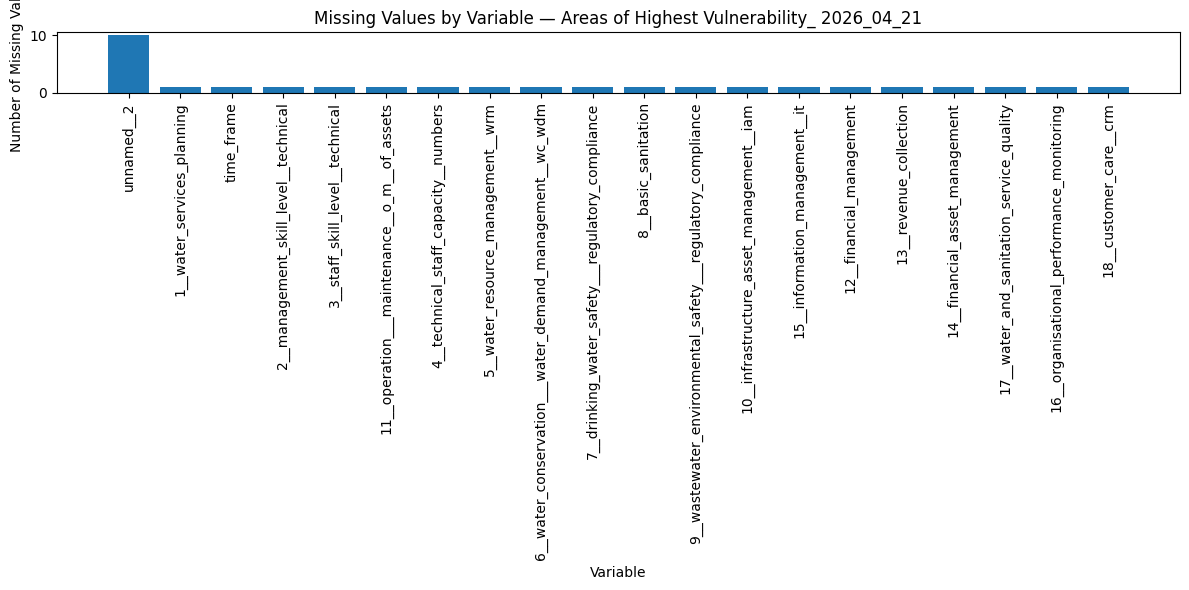

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Areas_of_Highest_Vulnerability_2026_04_21_missing_values.png


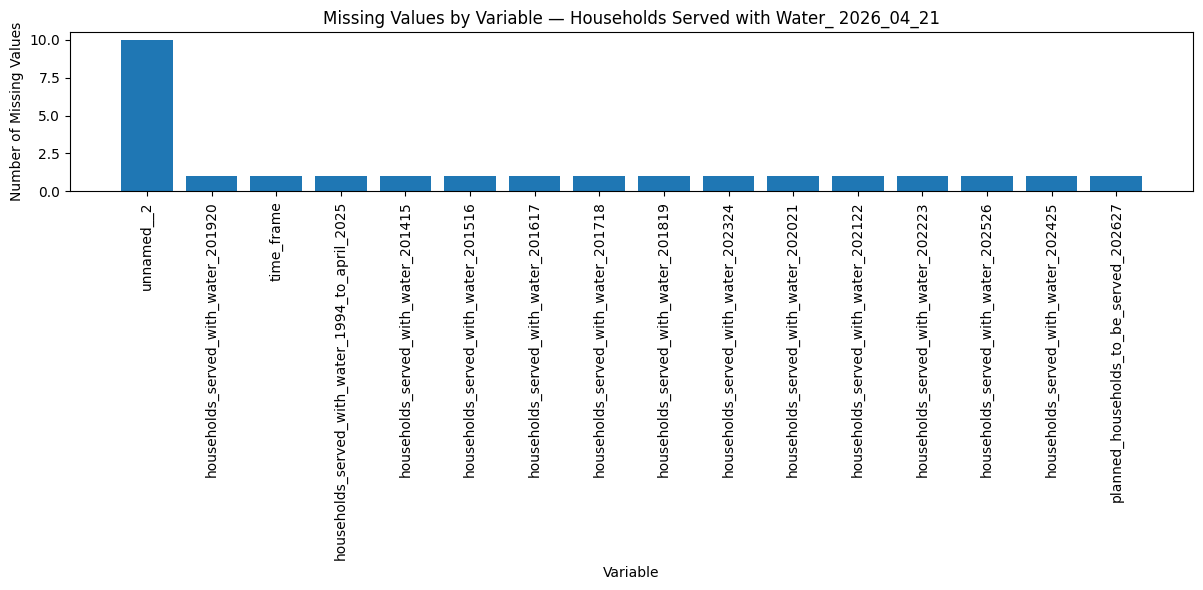

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Households_Served_with_Water_2026_04_21_missing_values.png


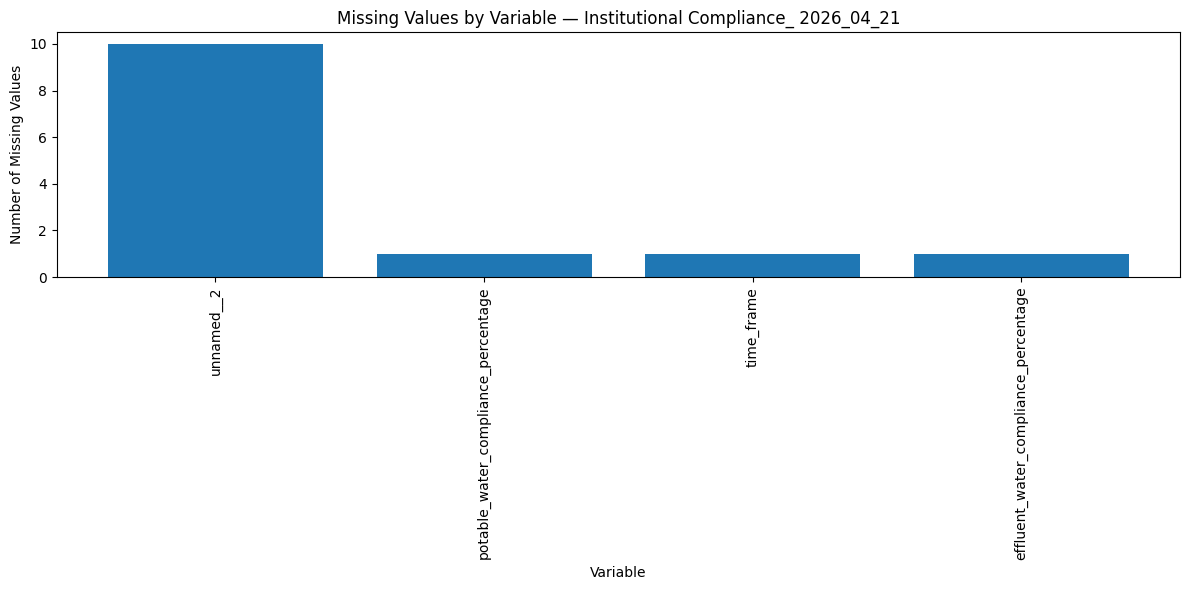

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Institutional_Compliance_2026_04_21_missing_values.png


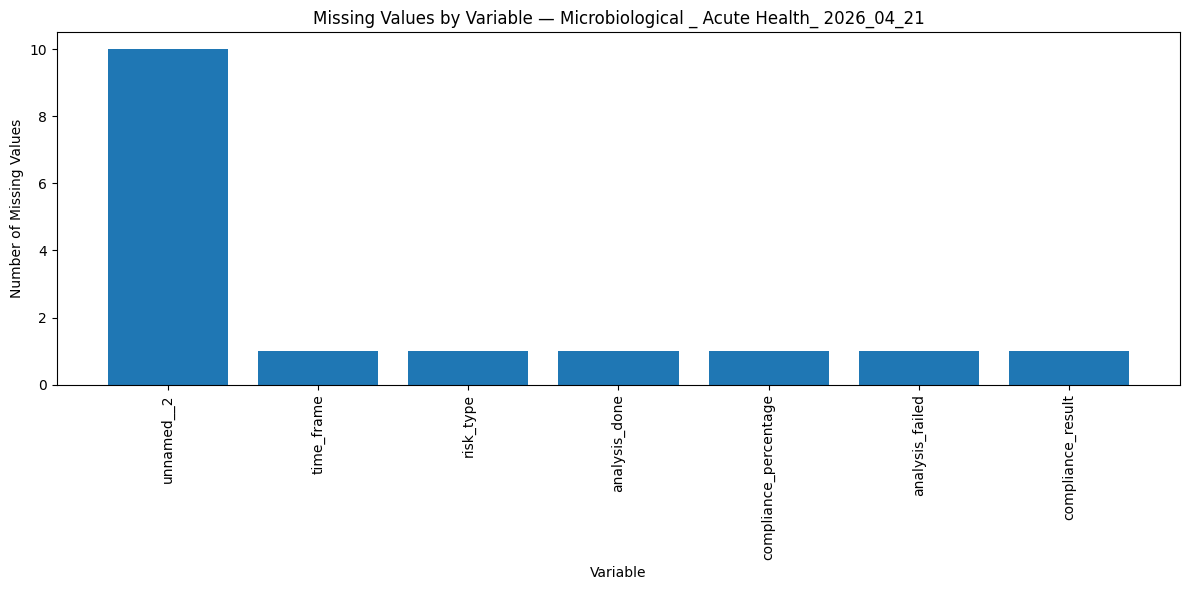

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Microbiological_Acute_Health_2026_04_21_missing_values.png


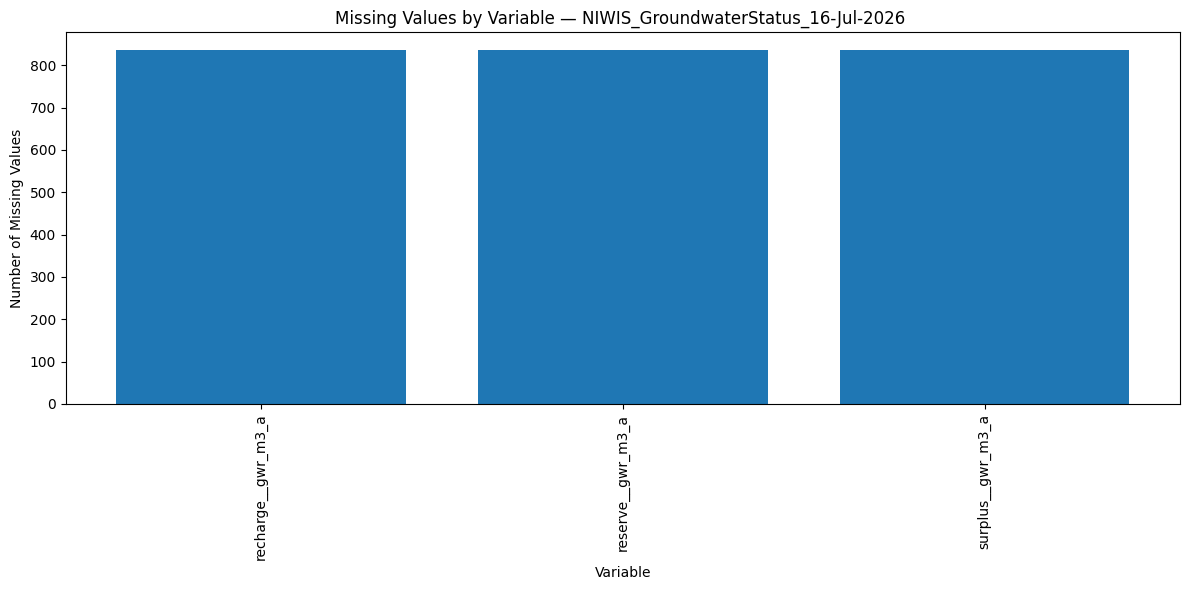

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/NIWIS_GroundwaterStatus_16-Jul-2026_missing_values.png


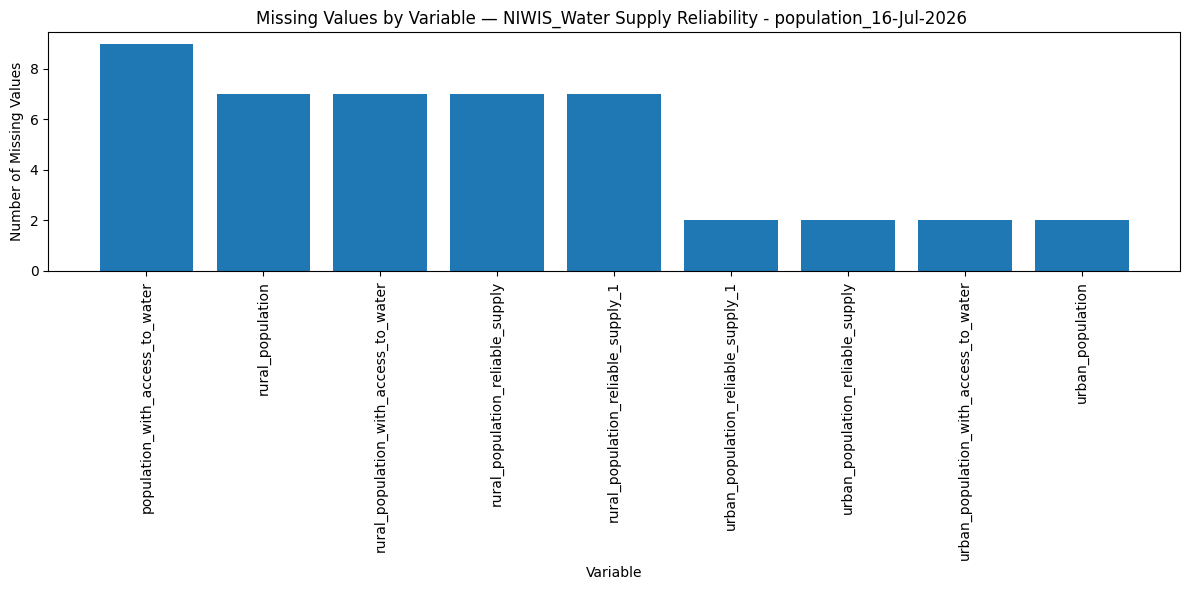

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/NIWIS_Water_Supply_Reliability_-_population_16-Jul-2026_missing_values.png


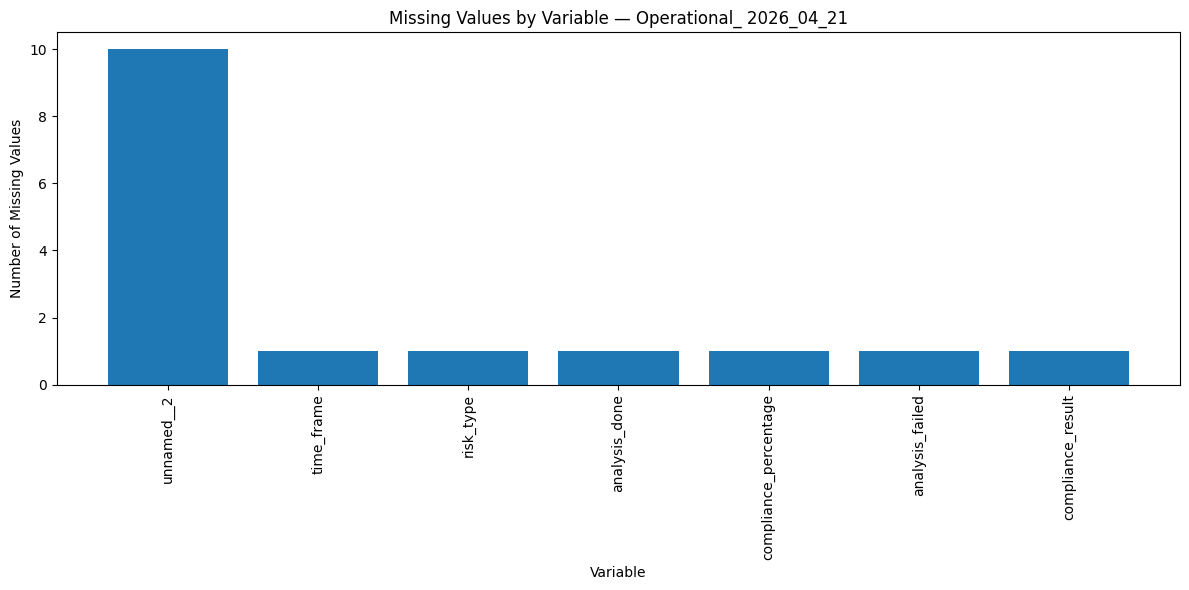

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Operational_2026_04_21_missing_values.png


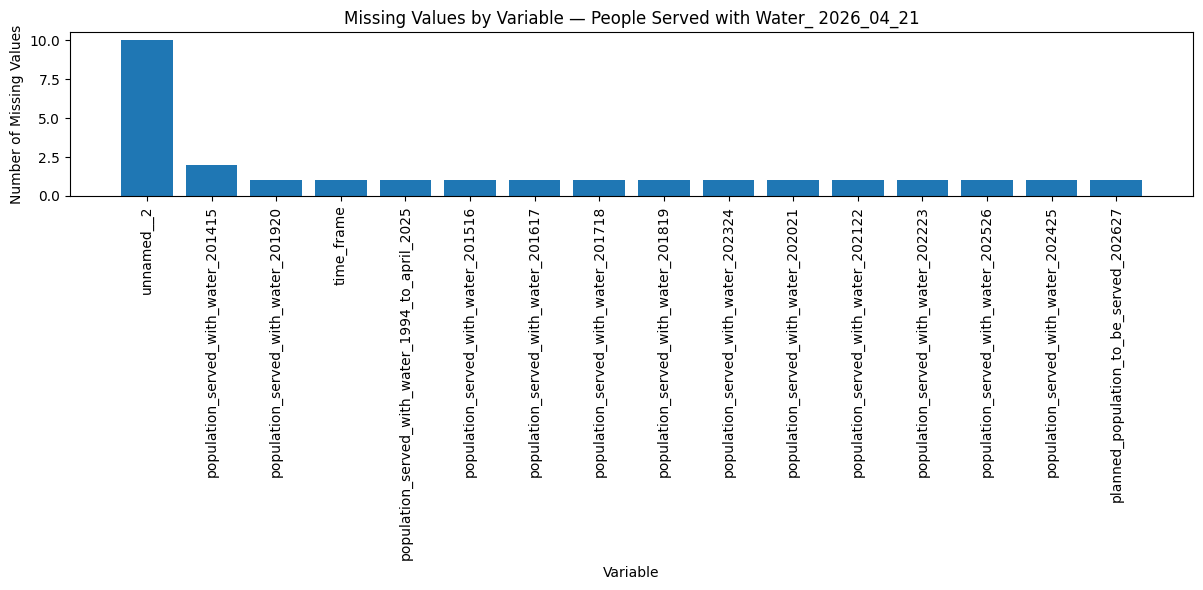

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/People_Served_with_Water_2026_04_21_missing_values.png


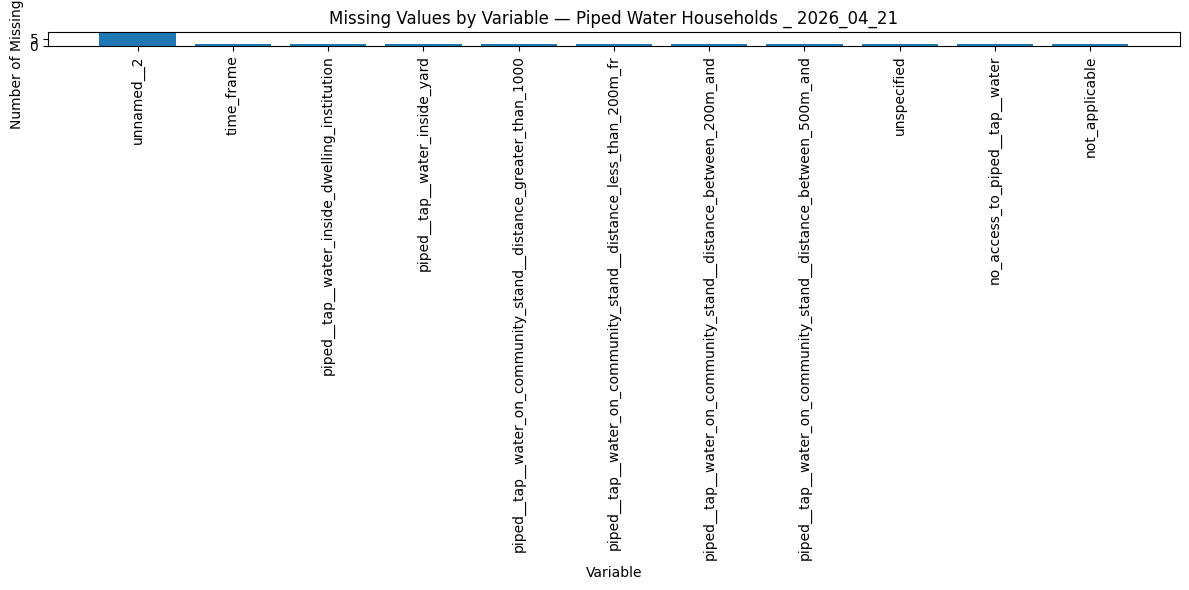

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Piped_Water_Households_2026_04_21_missing_values.png


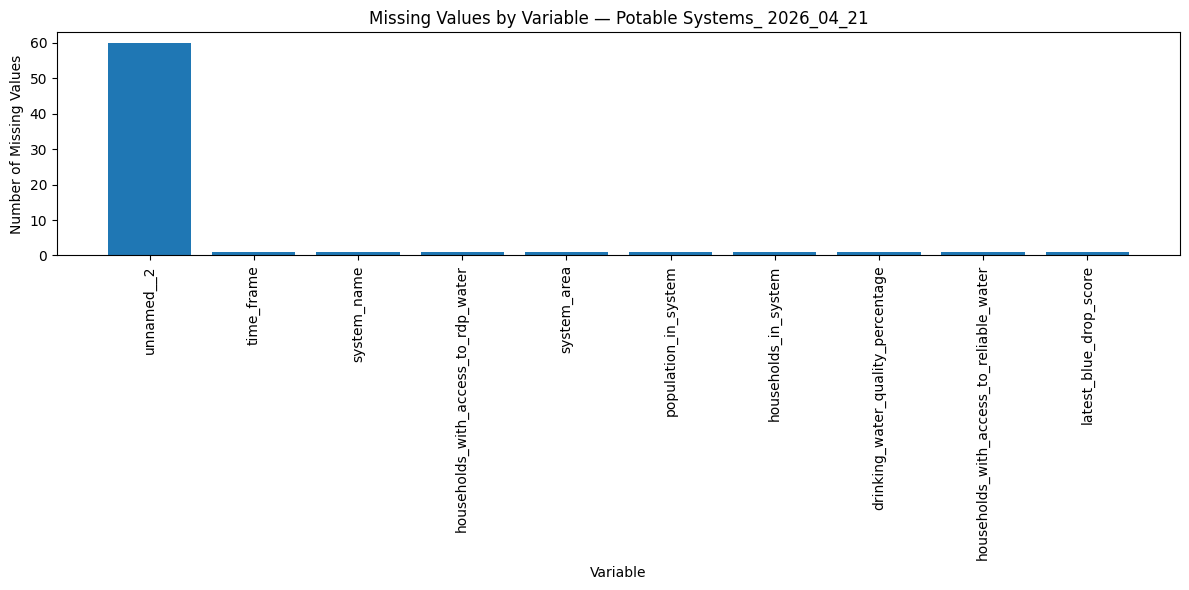

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Potable_Systems_2026_04_21_missing_values.png


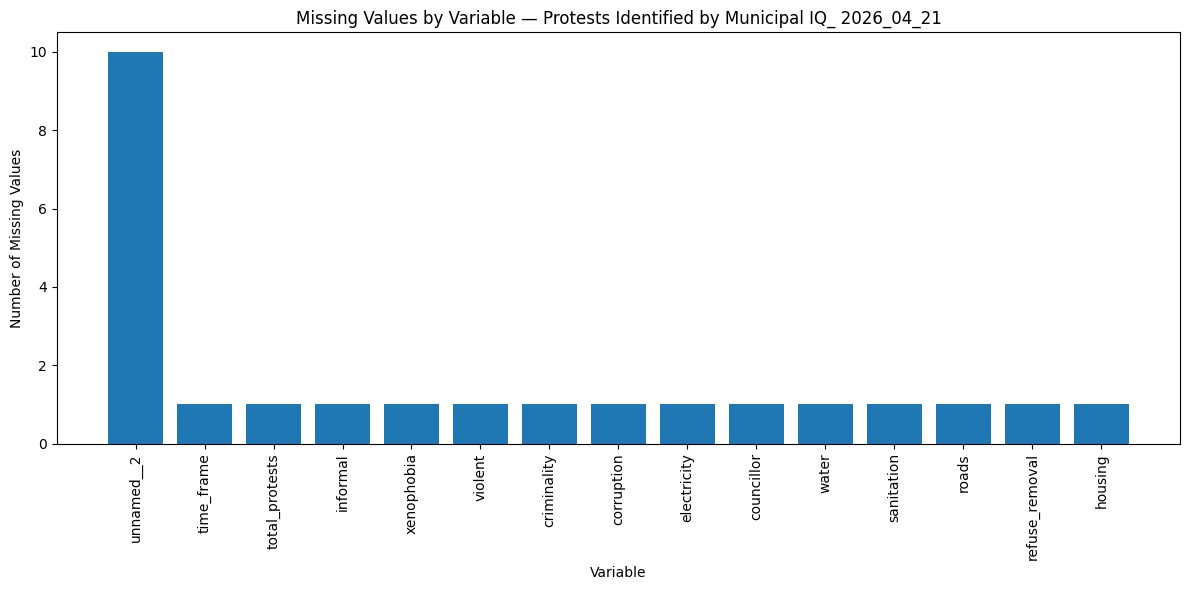

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Protests_Identified_by_Municipal_IQ_2026_04_21_missing_values.png


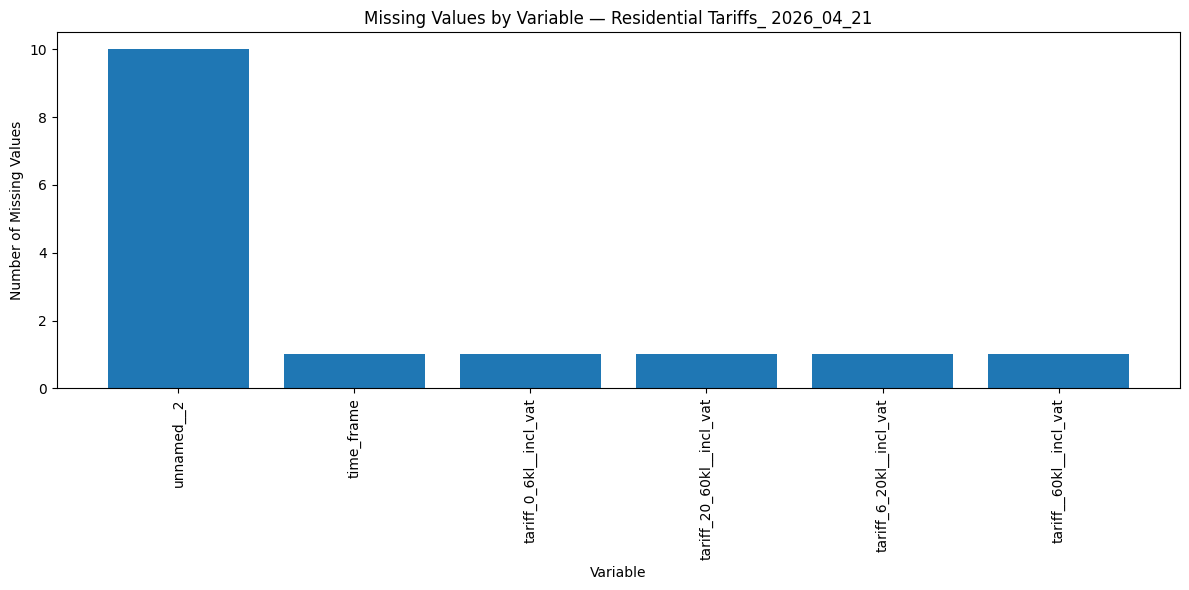

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Residential_Tariffs_2026_04_21_missing_values.png


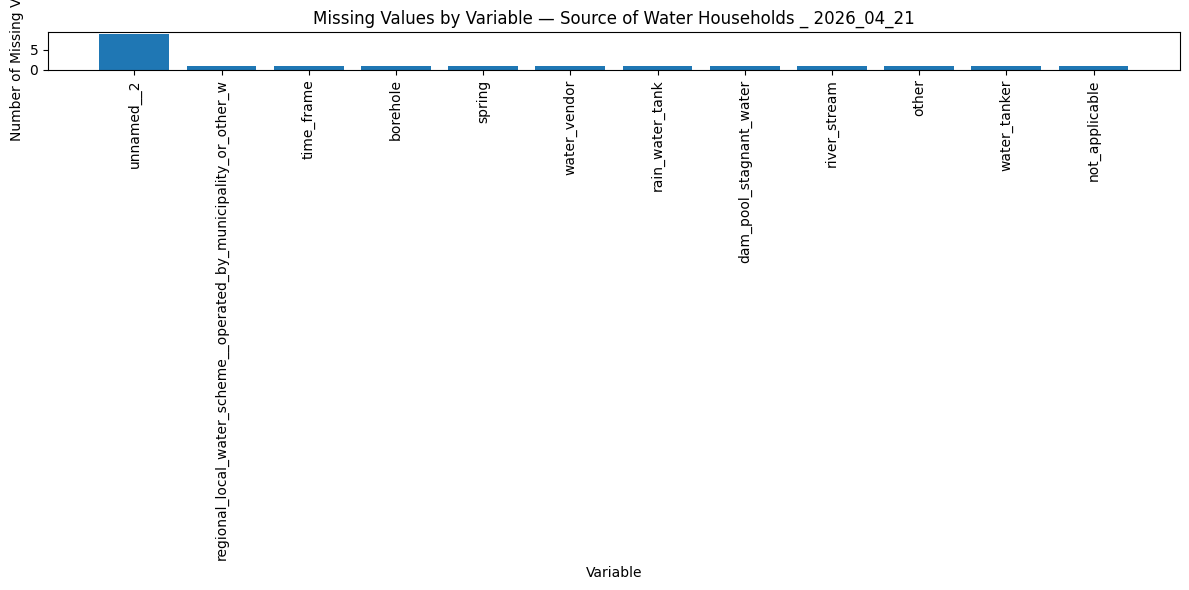

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Source_of_Water_Households_2026_04_21_missing_values.png


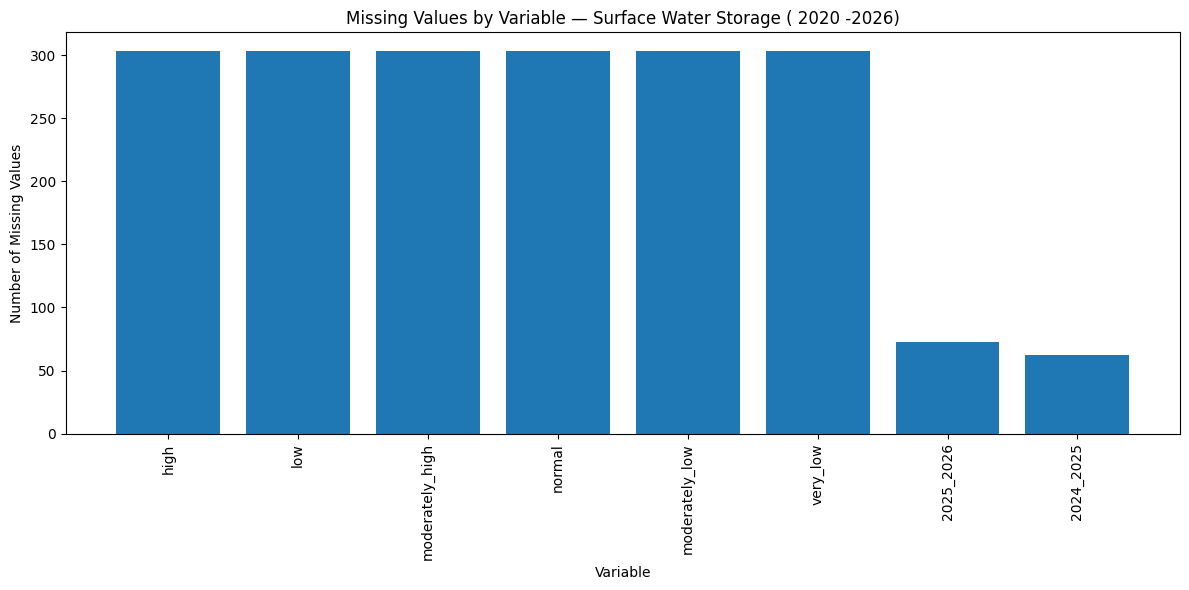

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Surface_Water_Storage_2020_-2026_missing_values.png


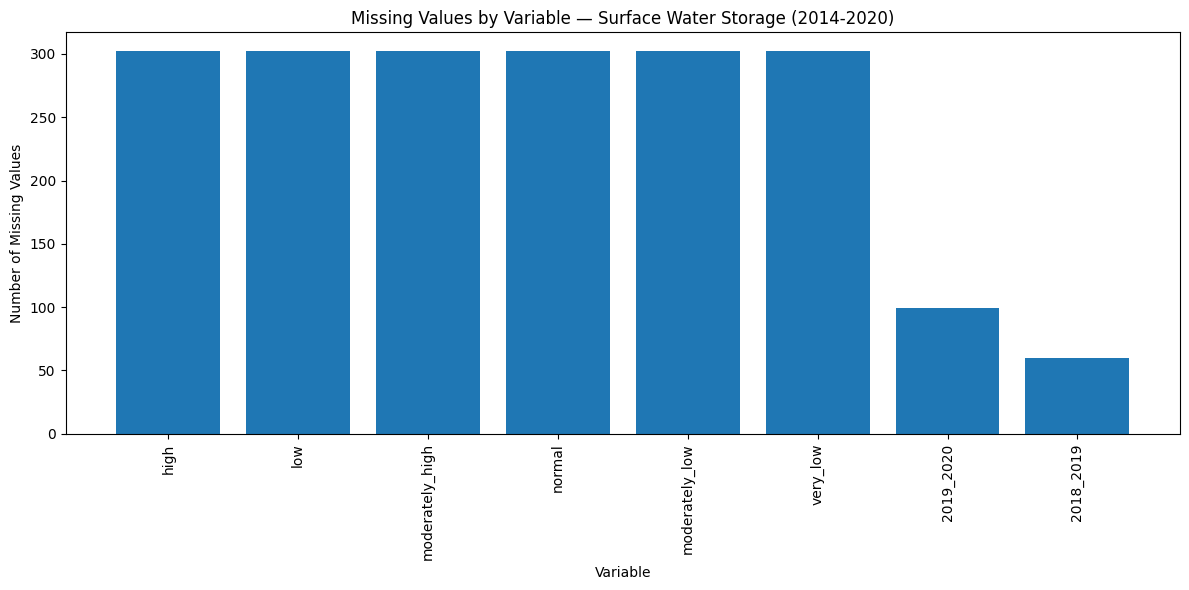

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Surface_Water_Storage_2014-2020_missing_values.png


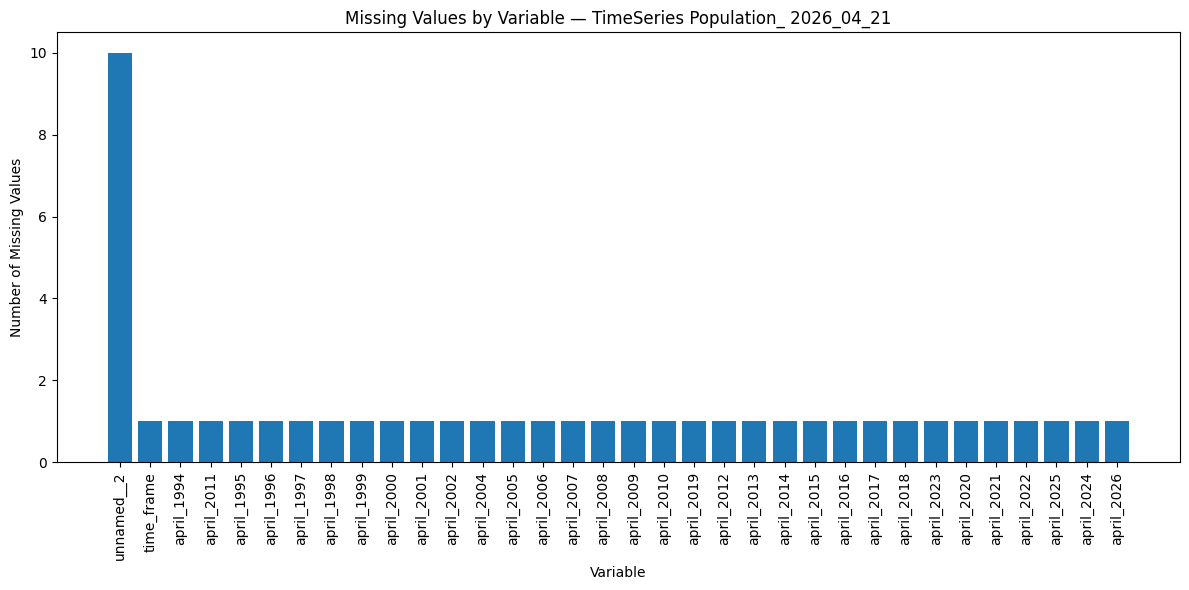

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/TimeSeries_Population_2026_04_21_missing_values.png


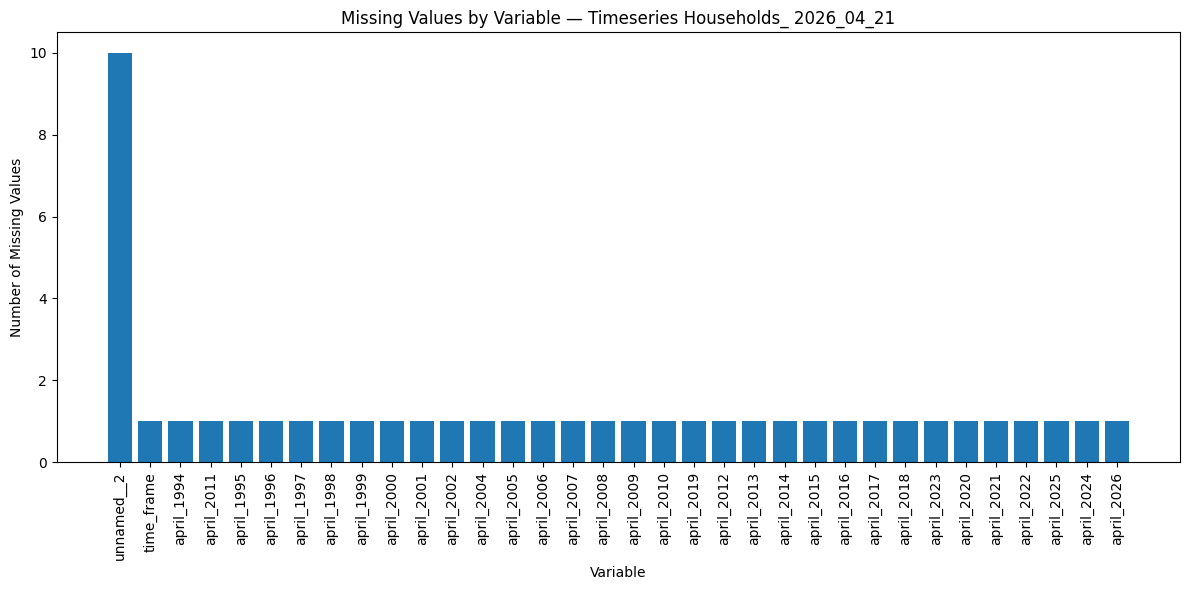

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Timeseries_Households_2026_04_21_missing_values.png


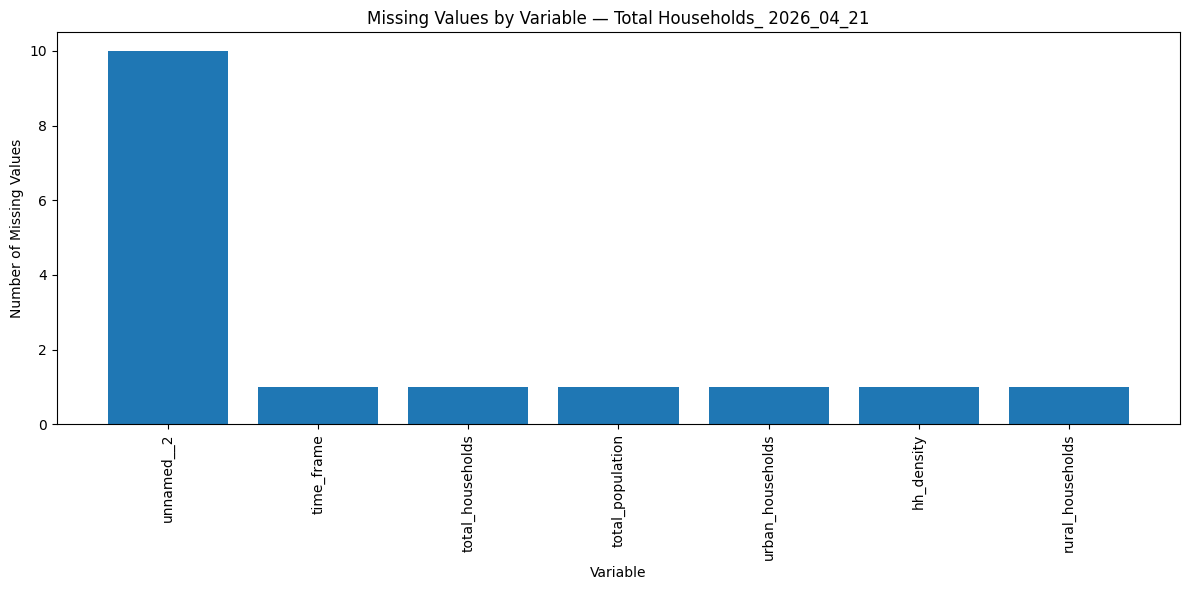

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Total_Households_2026_04_21_missing_values.png


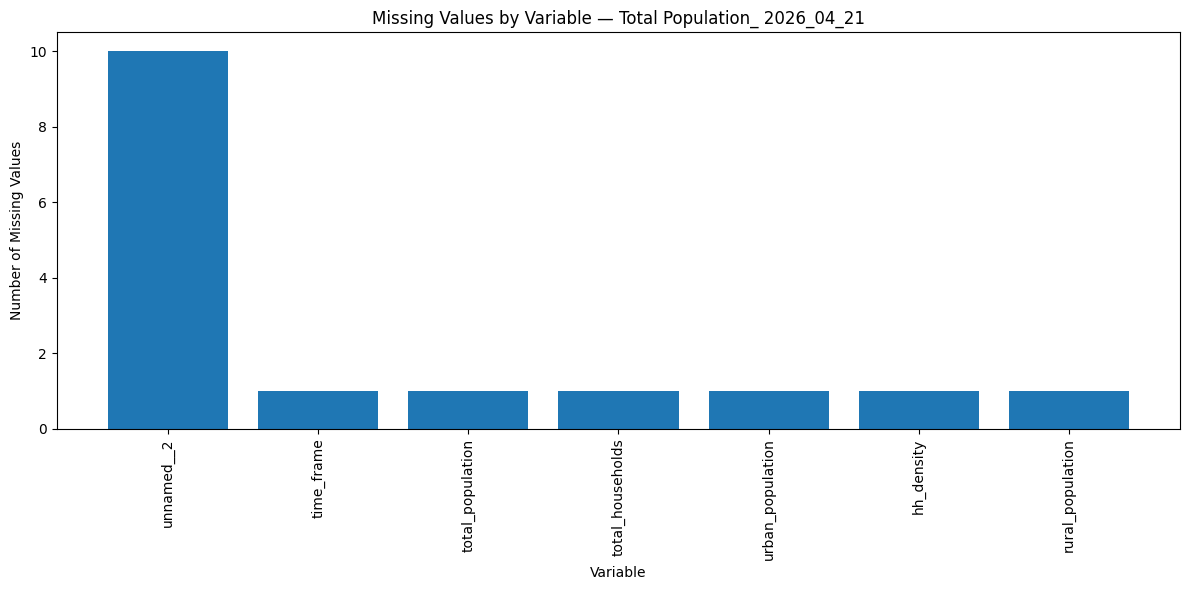

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Total_Population_2026_04_21_missing_values.png


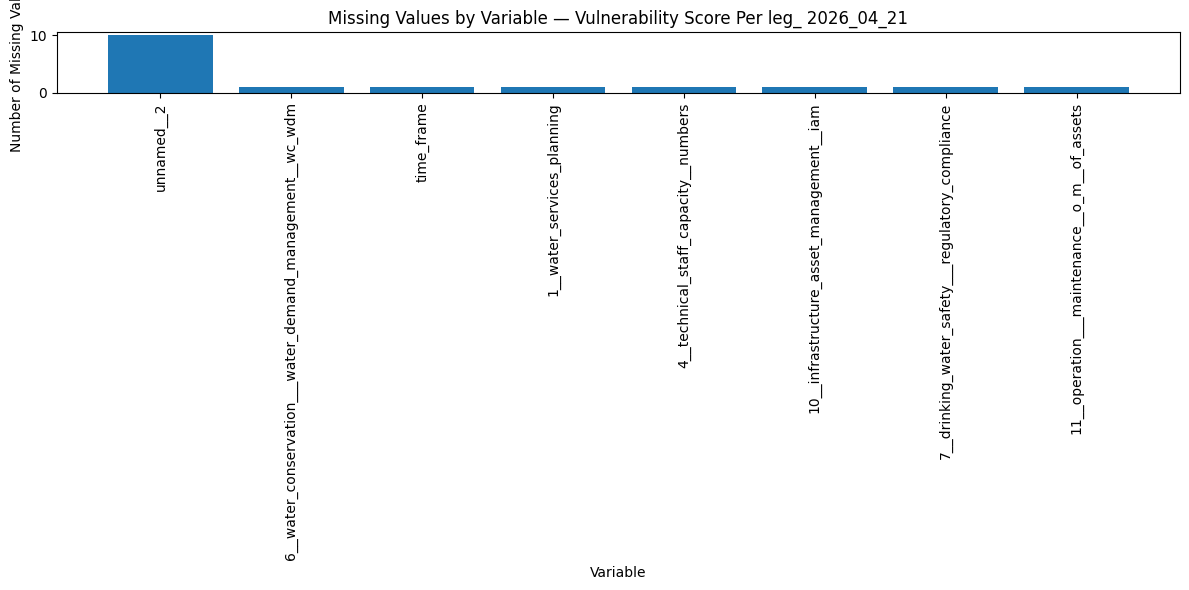

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Vulnerability_Score_Per_leg_2026_04_21_missing_values.png


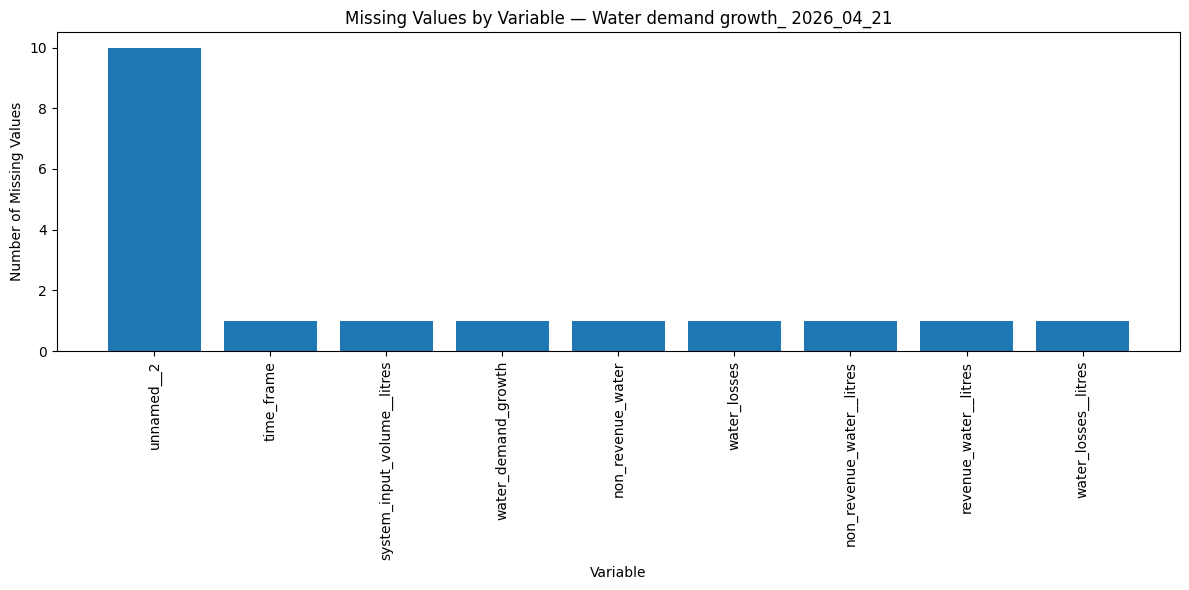

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Water_demand_growth_2026_04_21_missing_values.png


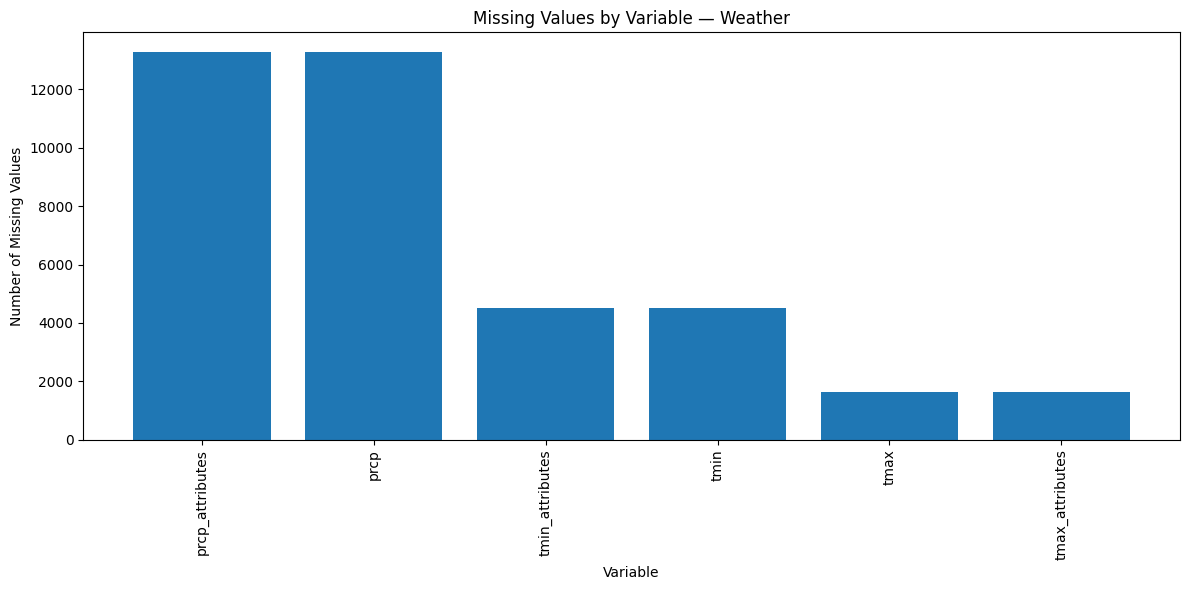

Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations/Weather_missing_values.png


In [15]:
# ============================================================
# VISUALISATION — MISSING VALUES
# ============================================================

import re # Import the regular expression module for filename sanitization

for name, df in cleaned.items():

    missing = (
        df.isna()
        .sum()
        .sort_values(
            ascending=False
        )
    )

    missing = missing[
        missing > 0
    ]

    if missing.empty:
        continue

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        missing.index.astype(str),
        missing.values
    )

    plt.title(
        f"Missing Values by Variable — {name}"
    )

    plt.xlabel(
        "Variable"
    )

    plt.ylabel(
        "Number of Missing Values"
    )

    plt.xticks(
        rotation=90
    )

    plt.tight_layout()

    # Sanitize the dataset name for use in filename
    # This helps in handling special characters or spaces that might cause issues with file paths.
    sanitized_name = str(name).strip()
    sanitized_name = re.sub(r'[^a-zA-Z0-9_.-]', '_', sanitized_name) # Replace non-alphanumeric (except underscore, dot, hyphen) with underscore
    sanitized_name = re.sub(r'_{2,}', '_', sanitized_name) # Replace multiple underscores with a single one
    sanitized_name = sanitized_name.strip('_') # Remove leading/trailing underscores

    output_path = os.path.join(
        VISUALISATION_DIR,
        f"{sanitized_name}_missing_values.png"
    )

    # Ensure the directory exists before saving
    # This is a redundant but safe check, in case of any unexpected issues with the directory.
    os.makedirs(VISUALISATION_DIR, exist_ok=True)

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        f"Saved: {output_path}"
    )

In [16]:
# ============================================================
# NUMERICAL MISSING VALUE IMPUTATION
# ============================================================

imputation_records = []

for name, df in cleaned.items():

    numeric_columns = (
        df.select_dtypes(
            include=np.number
        ).columns
    )

    for col in numeric_columns:

        missing_before = int(
            df[col].isna().sum()
        )

        if missing_before == 0:
            continue

        median_value = df[col].median()

        if pd.isna(median_value):

            print(
                f"{name}.{col}: "
                "Median unavailable. "
                "Requires review."
            )

            continue

        df[col] = df[col].fillna(
            median_value
        )

        imputation_records.append({

            "Dataset": name,

            "Column": col,

            "Missing Before":
                missing_before,

            "Method":
                "Median",

            "Imputation Value":
                median_value
        })

        print(
            f"{name}.{col}: "
            f"{missing_before} values "
            f"→ median {median_value}"
        )

    cleaned[name] = df

numeric_imputation_df = pd.DataFrame(
    imputation_records
)

Households Served with Water_ 2026_04_21.households_served_with_water_201415: 1 values → median 9.0
Households Served with Water_ 2026_04_21.households_served_with_water_202122: 1 values → median 0.0
Institutional Compliance_ 2026_04_21.potable_water_compliance_percentage: 1 values → median 99.53999999999999
Institutional Compliance_ 2026_04_21.effluent_water_compliance_percentage: 1 values → median 76.115
Microbiological _ Acute Health_ 2026_04_21.analysis_failed: 1 values → median 5.5
Microbiological _ Acute Health_ 2026_04_21.compliance_percentage: 1 values → median 97.08
Operational_ 2026_04_21.analysis_failed: 1 values → median 22.5
Operational_ 2026_04_21.compliance_percentage: 1 values → median 96.99000000000001
People Served with Water_ 2026_04_21.population_served_with_water_201415: 2 values → median 0.0
People Served with Water_ 2026_04_21.population_served_with_water_202122: 1 values → median 0.0
Piped Water Households _ 2026_04_21.unspecified: 1 values → median 0.0
Piped Wa

In [17]:
# ============================================================
# CATEGORICAL MISSING VALUE IMPUTATION
# ============================================================

categorical_imputation_records = []

for name, df in cleaned.items():

    categorical_columns = (
        df.select_dtypes(
            include=[
                "object",
                "string",
                "category"
            ]
        ).columns
    )

    for col in categorical_columns:

        missing_before = int(
            df[col].isna().sum()
        )

        if missing_before == 0:
            continue

        df[col] = df[col].fillna(
            "Unknown"
        )

        categorical_imputation_records.append({

            "Dataset": name,

            "Column": col,

            "Missing Before":
                missing_before,

            "Method":
                "Unknown category"
        })

        print(
            f"{name}.{col}: "
            f"{missing_before} values "
            "→ Unknown"
        )

    cleaned[name] = df

categorical_imputation_df = (
    pd.DataFrame(
        categorical_imputation_records
    )
)

Areas of Highest Vulnerability_ 2026_04_21.time_frame: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.unnamed__2: 10 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.1__water_services_planning: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.2__management_skill_level__technical: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.3__staff_skill_level__technical: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.4__technical_staff_capacity__numbers: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.5__water_resource_management__wrm: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.6__water_conservation___water_demand_management__wc_wdm: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.7__drinking_water_safety___regulatory_compliance: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.8__basic_sanitation: 1 values → Unknown
Areas of Highest Vulnerability_ 2026_04_21.9__wastewate

In [18]:
# ============================================================
# VERIFY MISSING VALUES AFTER IMPUTATION
# ============================================================

missing_after_records = []

for name, df in cleaned.items():

    total_missing = int(
        df.isna().sum().sum()
    )

    missing_after_records.append({

        "Dataset": name,

        "Remaining Missing Values":
            total_missing
    })

missing_after_df = pd.DataFrame(
    missing_after_records
)

display(
    missing_after_df
)

,Dataset,Remaining Missing Values
0,Areas of Highest Vulnerability_ 2026_04_21,0
1,Drinking Water Quality Compliance - SANS 241 _...,0
2,Households Served with Water_ 2026_04_21,0
3,Institutional Compliance_ 2026_04_21,0
4,Microbiological _ Acute Health_ 2026_04_21,0
5,NIWIS_Access to Water Infrastructure Delivered...,0
6,NIWIS_GroundwaterStatus_16-Jul-2026,0
7,NIWIS_RWT_16-Jul-2026,0
8,NIWIS_WasteWaterQuality_16-Jul-2026,0
9,NIWIS_Water Supply Reliability - population_16...,0


In [19]:
# ============================================================
# DETECT INFINITE VALUES
# ============================================================

infinite_records = []

for name, df in cleaned.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    # Convert to float to handle potential pd.NA values and ensure compatibility with np.isinf
    infinite_count = int(
        np.isinf(
            numeric_df.astype(float).to_numpy()
        ).sum()
    )

    infinite_records.append({

        "Dataset": name,

        "Infinite Values":
            infinite_count
    })

infinite_df = pd.DataFrame(
    infinite_records
)

display(
    infinite_df
)

,Dataset,Infinite Values
0,Areas of Highest Vulnerability_ 2026_04_21,0
1,Drinking Water Quality Compliance - SANS 241 _...,0
2,Households Served with Water_ 2026_04_21,0
3,Institutional Compliance_ 2026_04_21,0
4,Microbiological _ Acute Health_ 2026_04_21,0
5,NIWIS_Access to Water Infrastructure Delivered...,0
6,NIWIS_GroundwaterStatus_16-Jul-2026,0
7,NIWIS_RWT_16-Jul-2026,0
8,NIWIS_WasteWaterQuality_16-Jul-2026,0
9,NIWIS_Water Supply Reliability - population_16...,0


In [20]:
# ============================================================
# HANDLE INFINITE VALUES
# ============================================================

for name, df in cleaned.items():

    numeric_columns = (
        df.select_dtypes(
            include=np.number
        ).columns
    )

    for col in numeric_columns:

        df[col] = df[col].replace(
            [np.inf, -np.inf],
            np.nan
        )

        if df[col].isna().sum() > 0:

            median_value = (
                df[col].median()
            )

            if not pd.isna(
                median_value
            ):

                df[col] = df[col].fillna(
                    median_value
                )

    cleaned[name] = df

print(
    "Infinite values handled."
)

Infinite values handled.


In [21]:
# ============================================================
# OUTLIER DETECTION
# IQR + Z-SCORE
# ============================================================

outlier_records = []

for name, df in cleaned.items():

    numeric_columns = (
        df.select_dtypes(
            include=np.number
        ).columns
    )

    for col in numeric_columns:

        series = df[col].dropna()

        if len(series) < 4:
            continue

        # ------------------------------------
        # IQR
        # ------------------------------------

        Q1 = series.quantile(
            0.25
        )

        Q3 = series.quantile(
            0.75
        )

        IQR = Q3 - Q1

        lower_bound = (
            Q1 - 1.5 * IQR
        )

        upper_bound = (
            Q3 + 1.5 * IQR
        )

        iqr_outliers = int(
            (
                (series < lower_bound)
                |
                (series > upper_bound)
            ).sum()
        )

        # ------------------------------------
        # Z-score
        # ------------------------------------

        std = series.std()

        if std == 0 or pd.isna(std):

            z_outliers = 0

        else:

            z_scores = np.abs(
                zscore(series)
            )

            z_outliers = int(
                (z_scores > 3).sum()
            )

        outlier_records.append({

            "Dataset": name,

            "Column": col,

            "Observations":
                len(series),

            "IQR Outliers":
                iqr_outliers,

            "IQR Outlier %":
                round(
                    iqr_outliers /
                    len(series) * 100,
                    2
                ),

            "Z-Score Outliers":
                z_outliers,

            "Z-Score Outlier %":
                round(
                    z_outliers /
                    len(series) * 100,
                    2
                ),

            "IQR Lower Bound":
                lower_bound,

            "IQR Upper Bound":
                upper_bound
        })

outlier_df = pd.DataFrame(
    outlier_records
)

display(
    outlier_df.sort_values(
        "IQR Outliers",
        ascending=False
    )
)

,Dataset,Column,Observations,IQR Outliers,IQR Outlier %,Z-Score Outliers,Z-Score Outlier %,IQR Lower Bound,IQR Upper Bound
64,Weather,prcp,21301,7521,35.31,373,1.75,0.5000,0.5000
67,Weather,tmin,21301,236,1.11,50,0.23,0.3500,23.1500
66,Weather,tmax,21301,113,0.53,51,0.24,13.1500,37.5500
34,Surface Water Storage ( 2020 -2026),moderately_high,375,72,19.20,12,3.20,88.3975,88.3975
41,Surface Water Storage (2014-2020),high,374,72,19.25,18,4.81,94.2450,94.2450
...,...,...,...,...,...,...,...,...,...
55,Vulnerability Score Per leg_ 2026_04_21,7__drinking_water_safety___regulatory_compliance,11,0,0.00,0,0.00,29.0000,125.0000
53,Vulnerability Score Per leg_ 2026_04_21,4__technical_staff_capacity__numbers,11,0,0.00,0,0.00,1.5000,117.5000
63,Weather,elevation,21301,0,0.00,0,0.00,1208.8500,1985.2500
61,Weather,latitude,21301,0,0.00,0,0.00,-26.4720,-25.5840


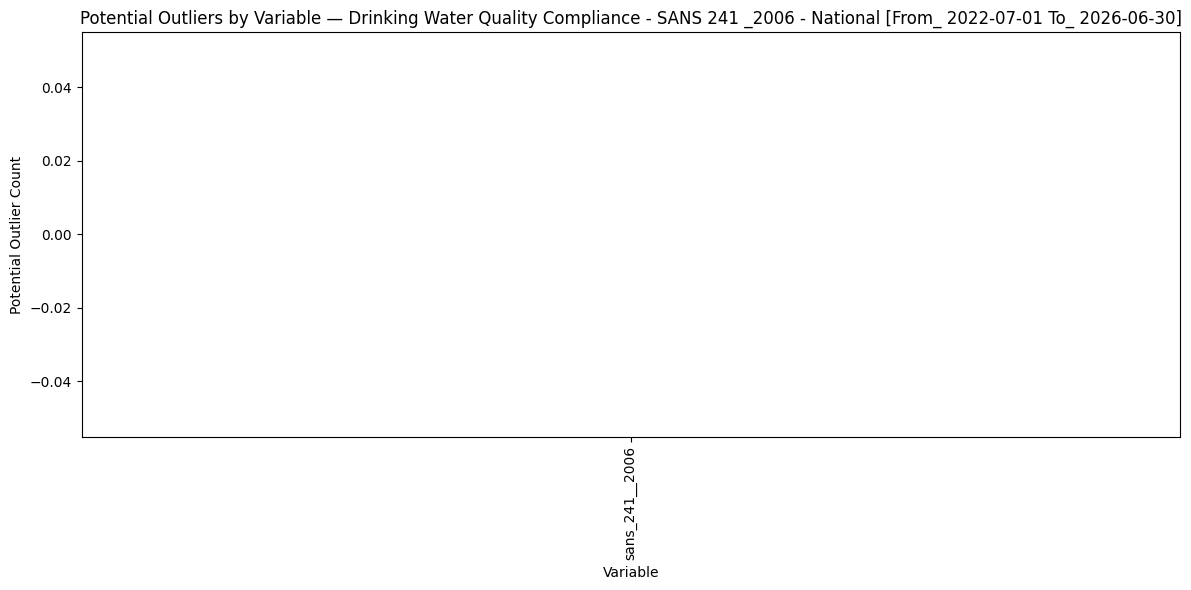

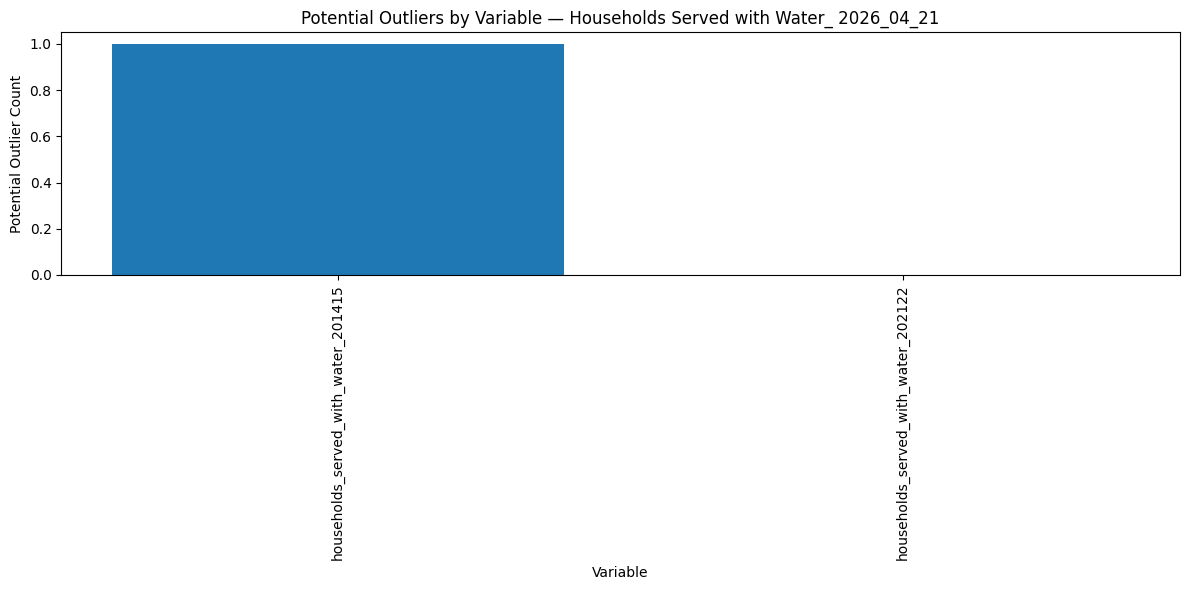

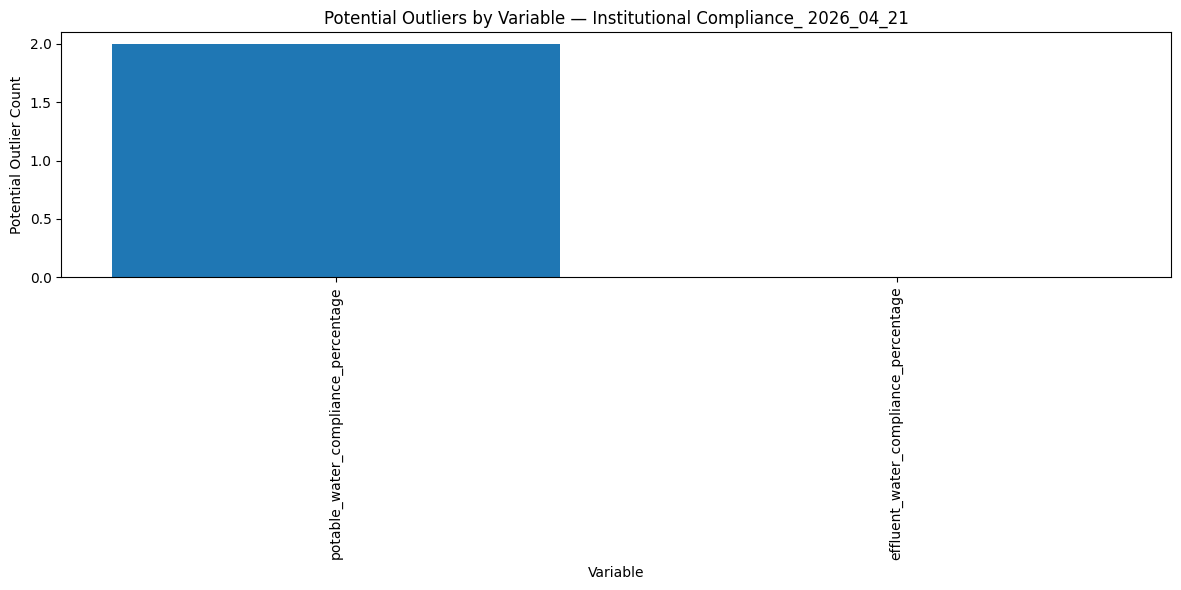

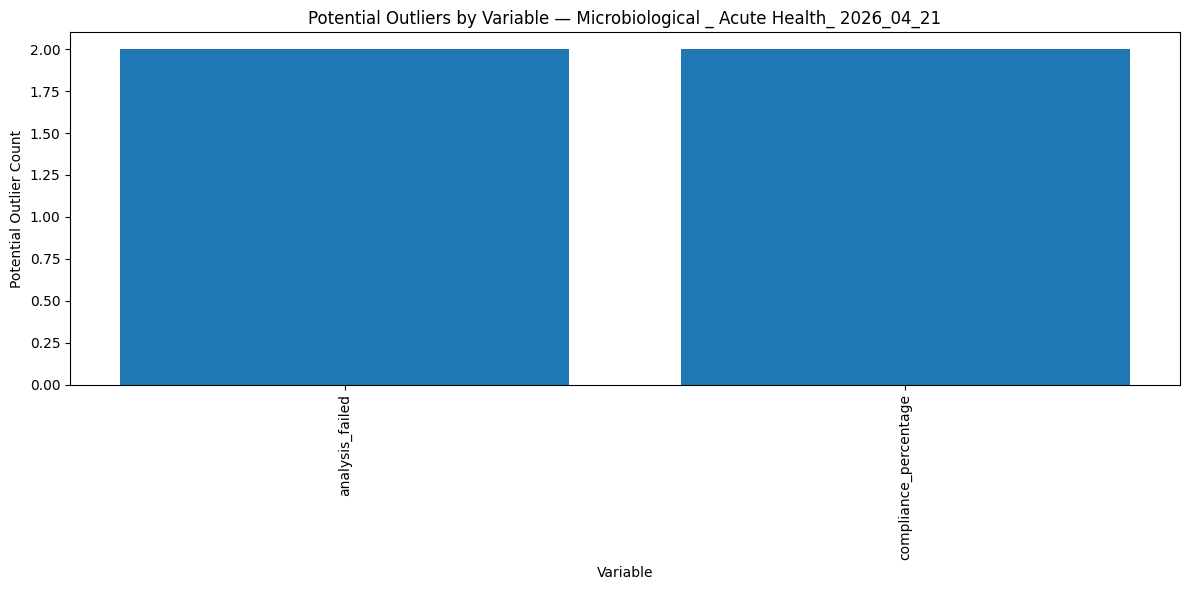

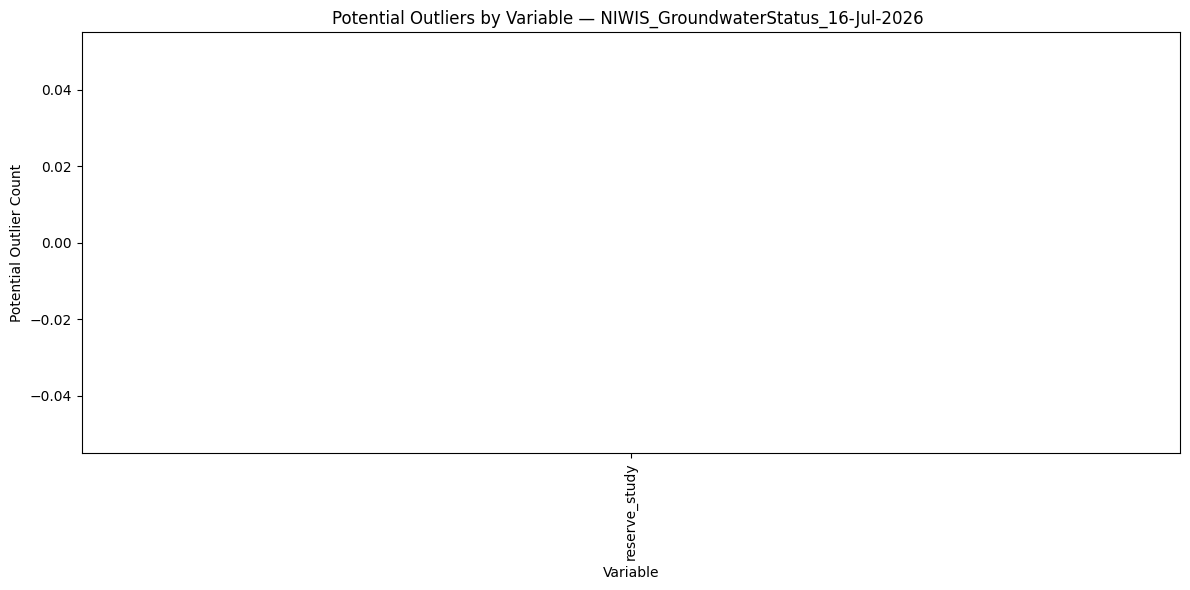

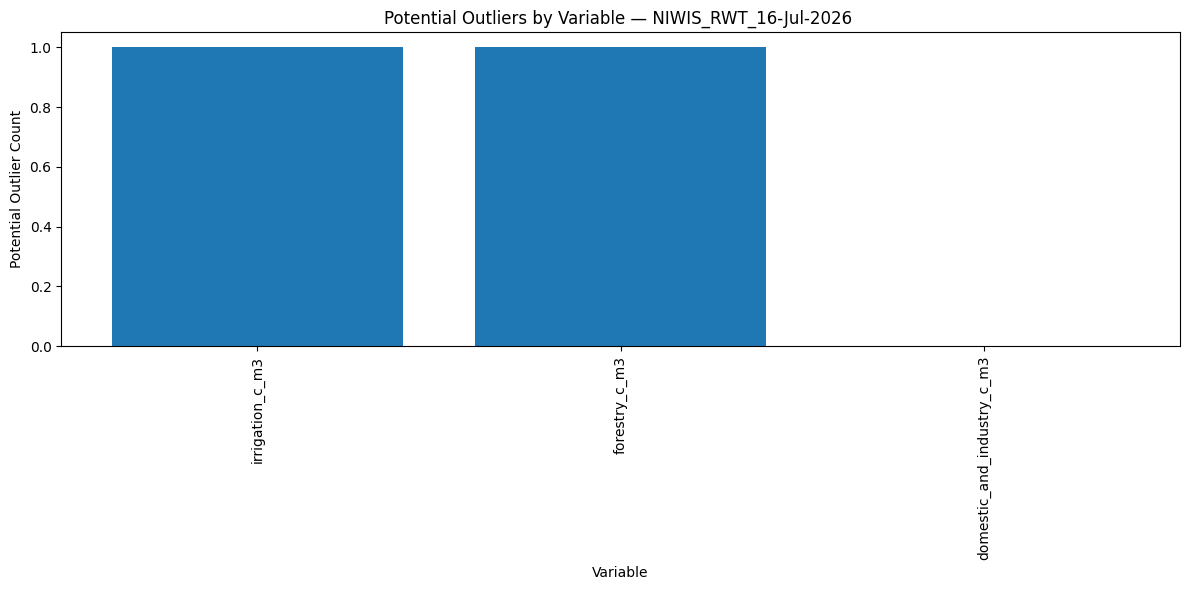

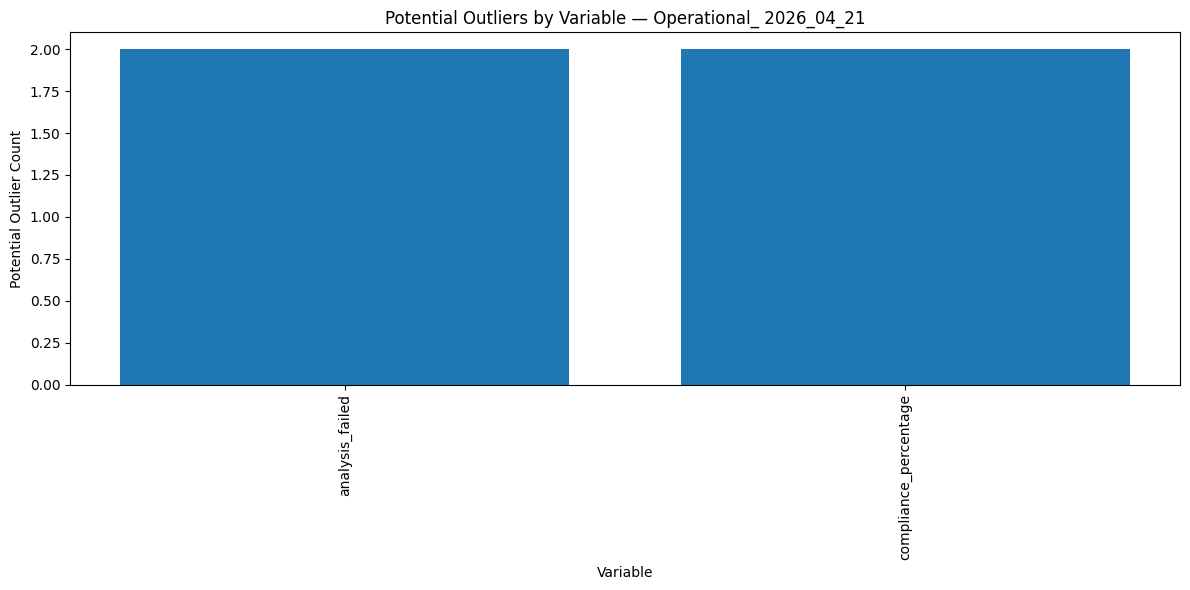

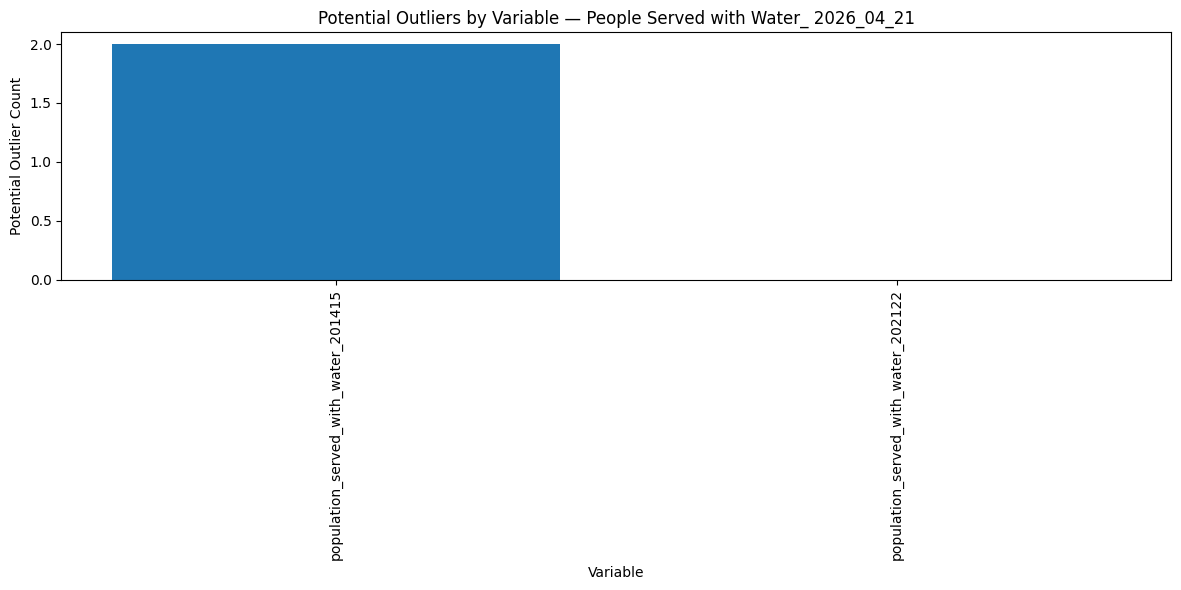

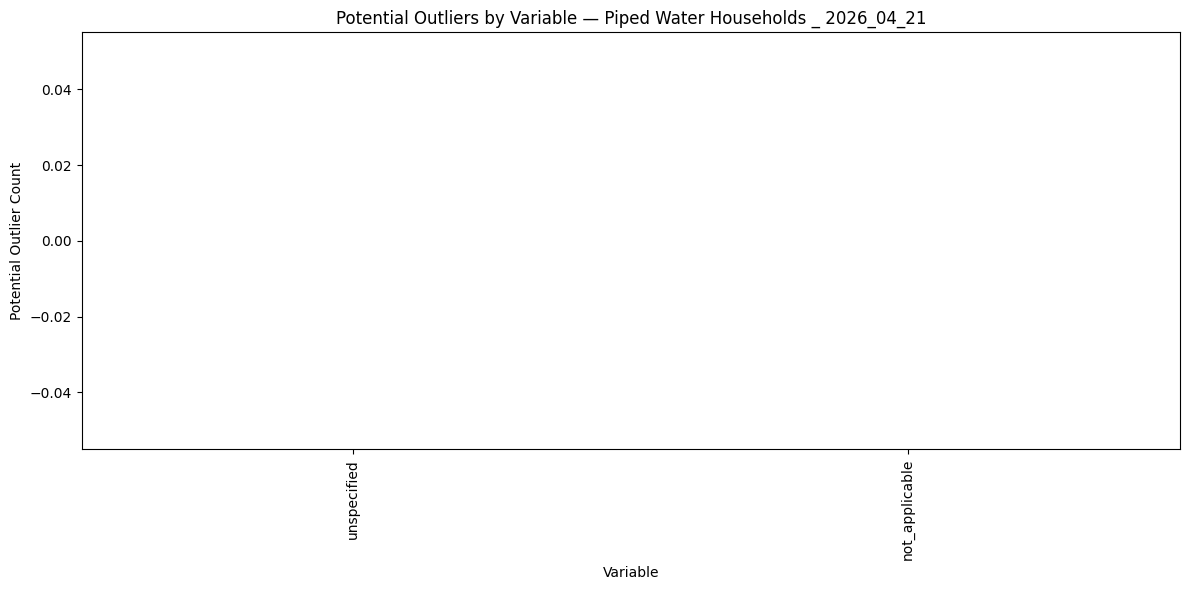

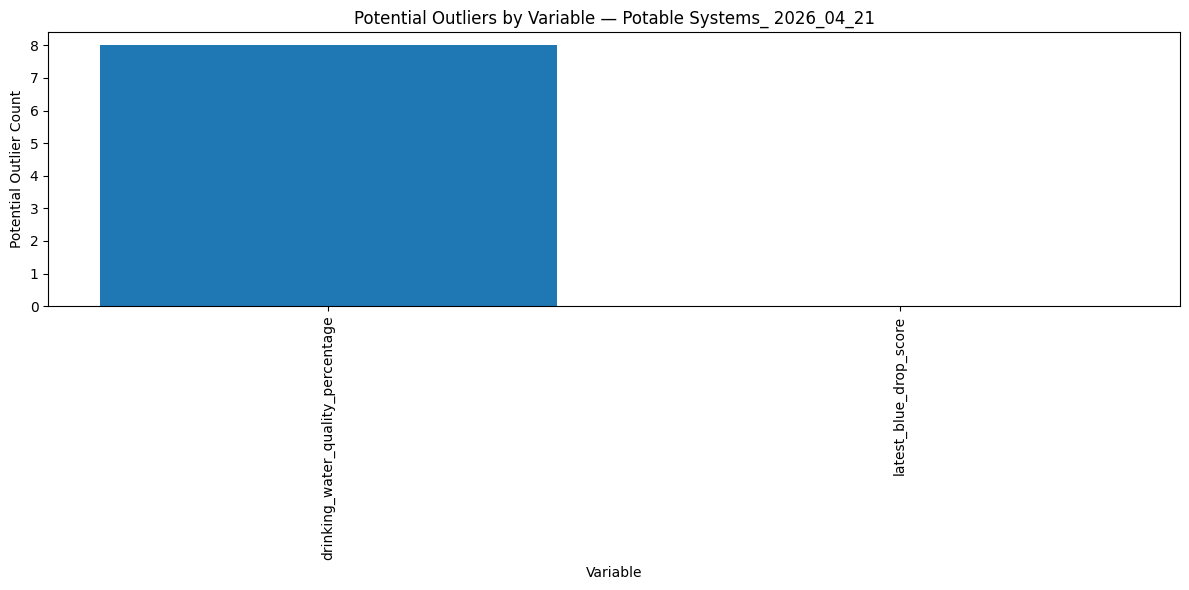

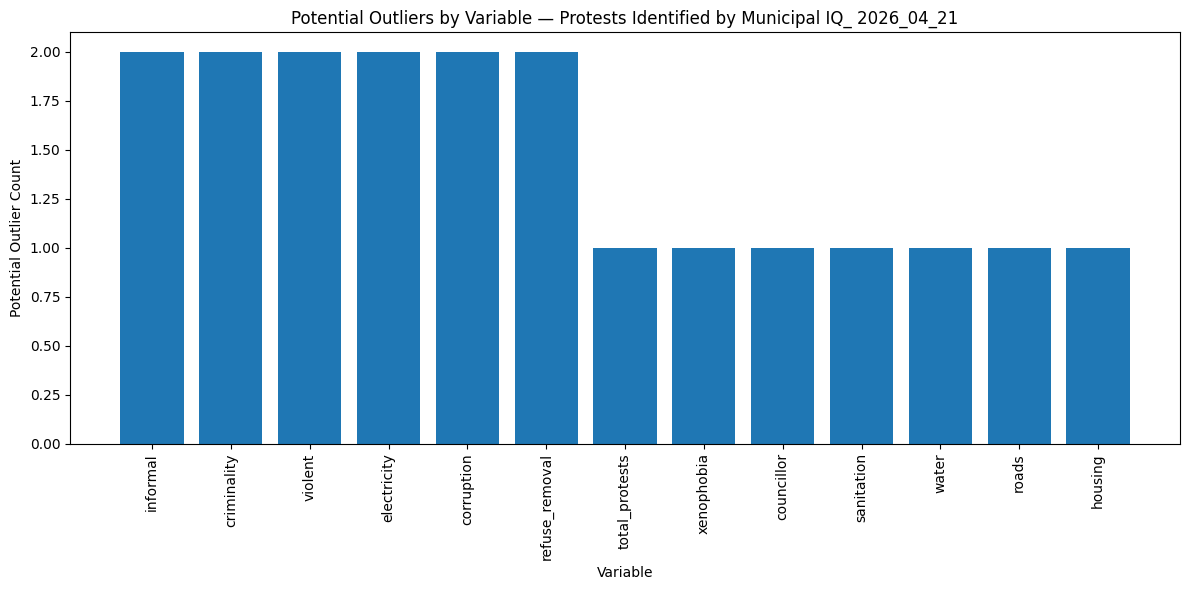

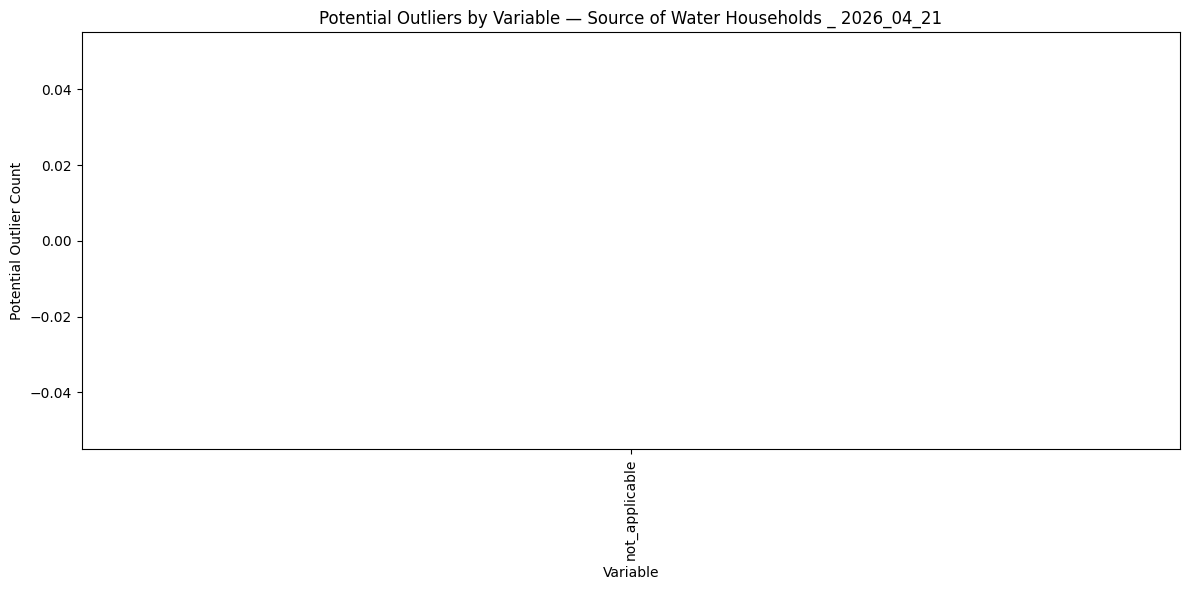

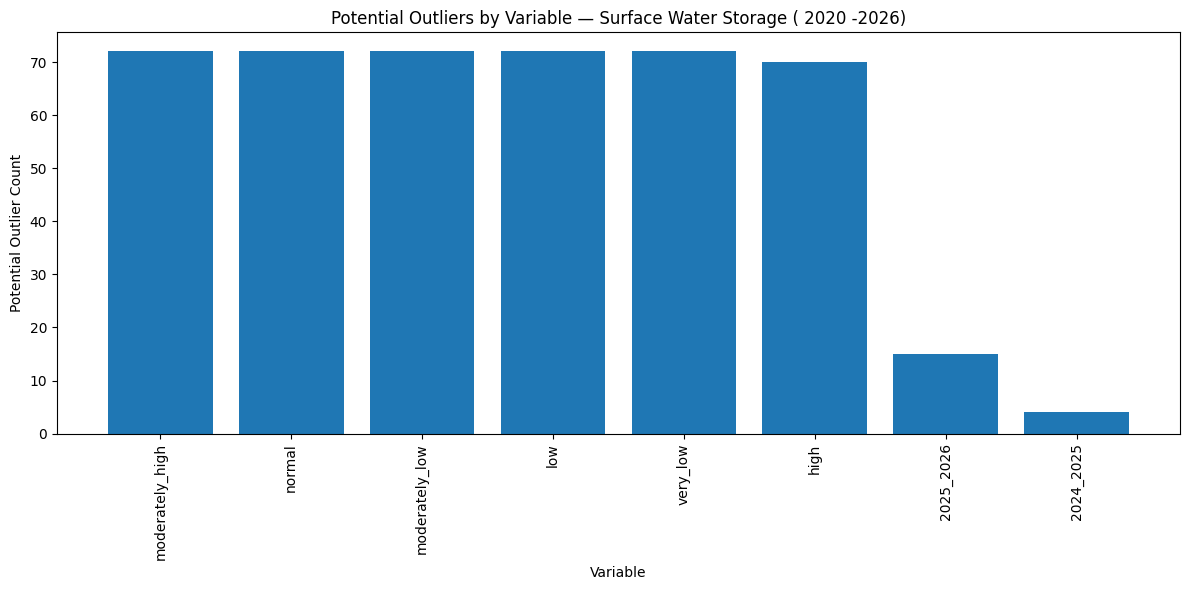

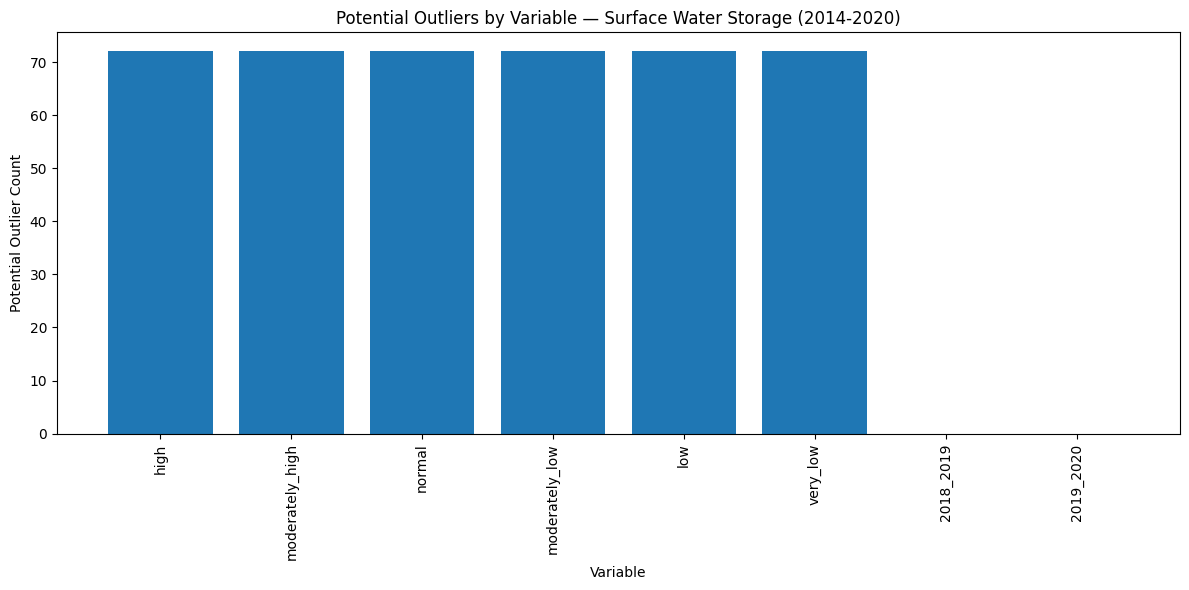

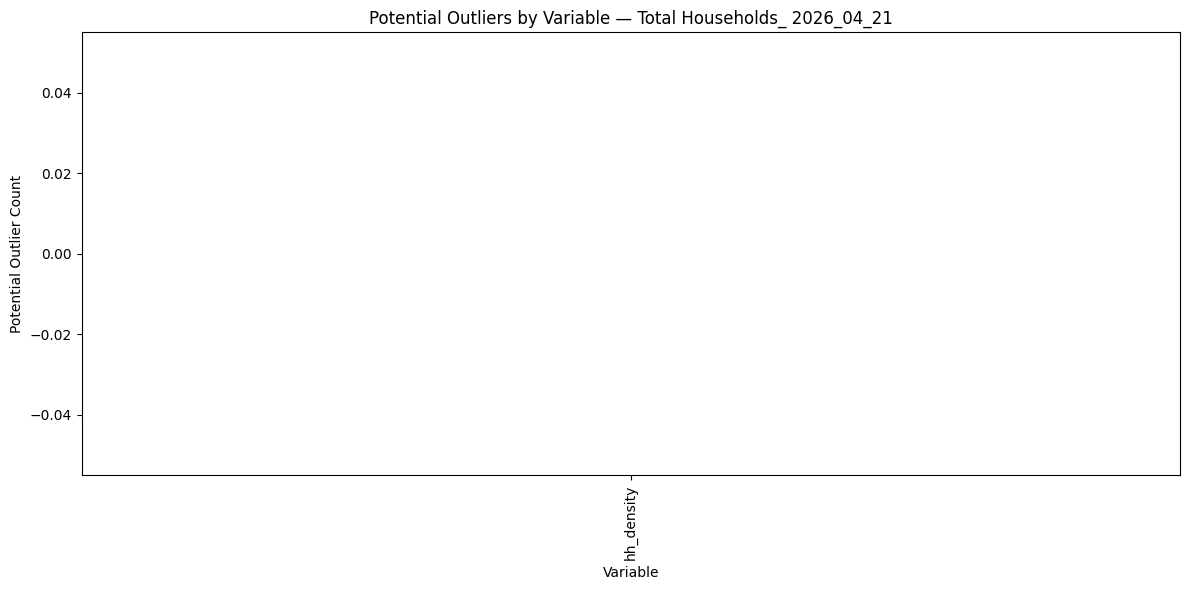

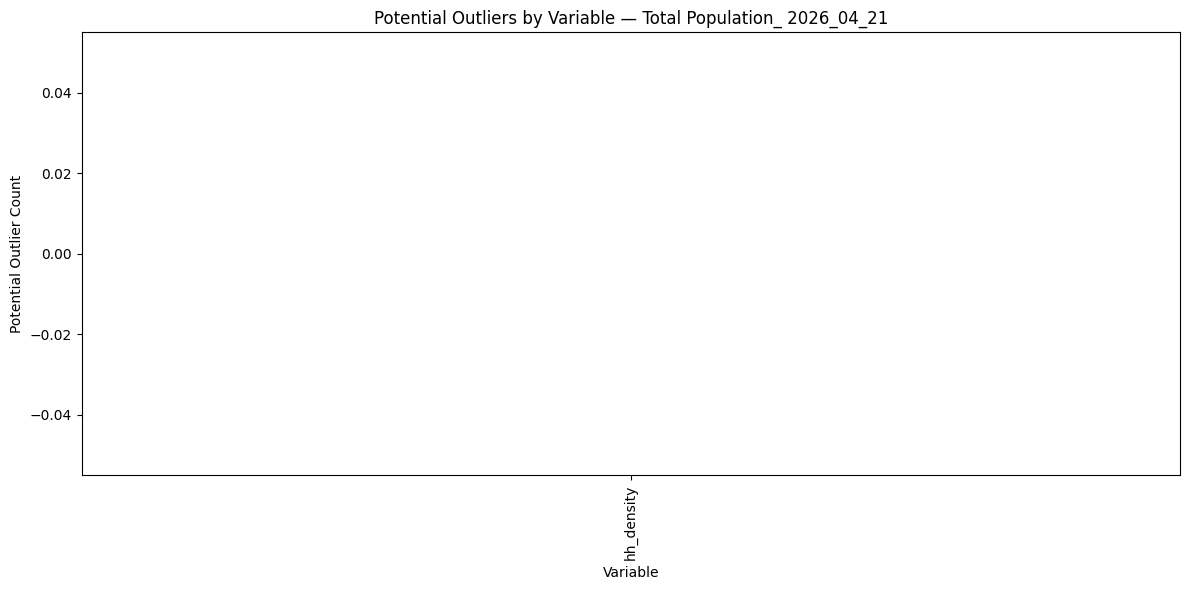

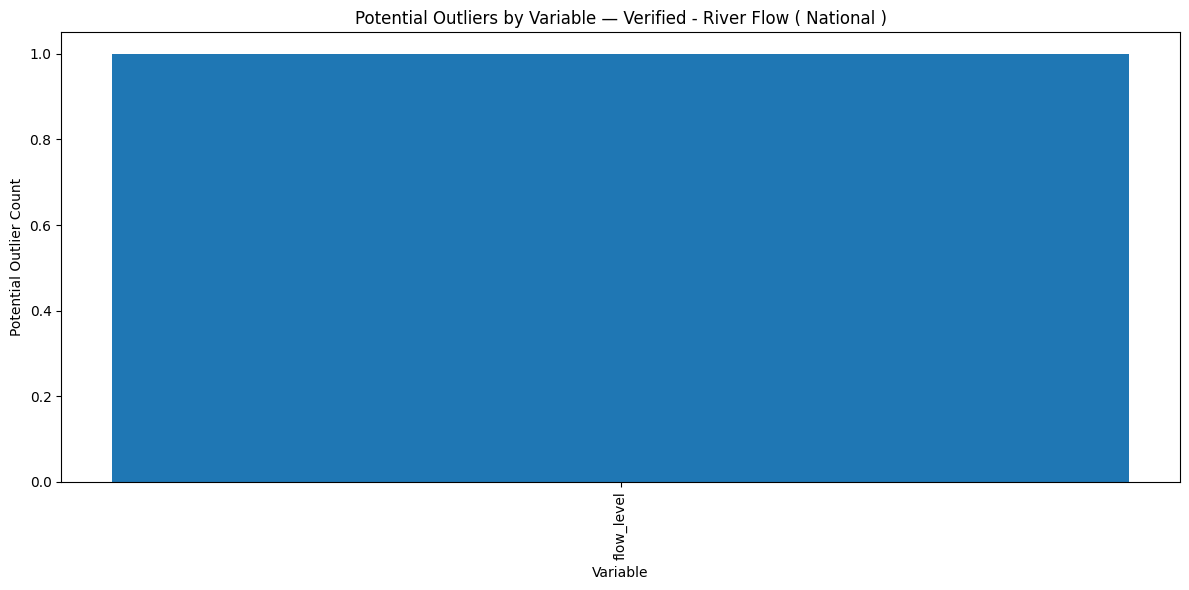

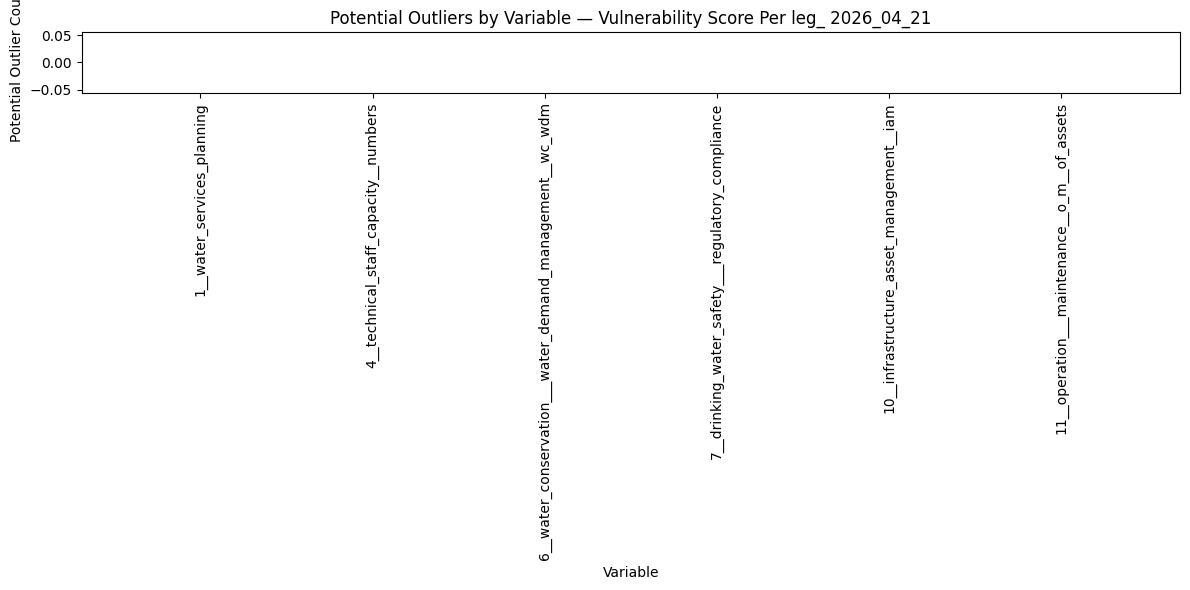

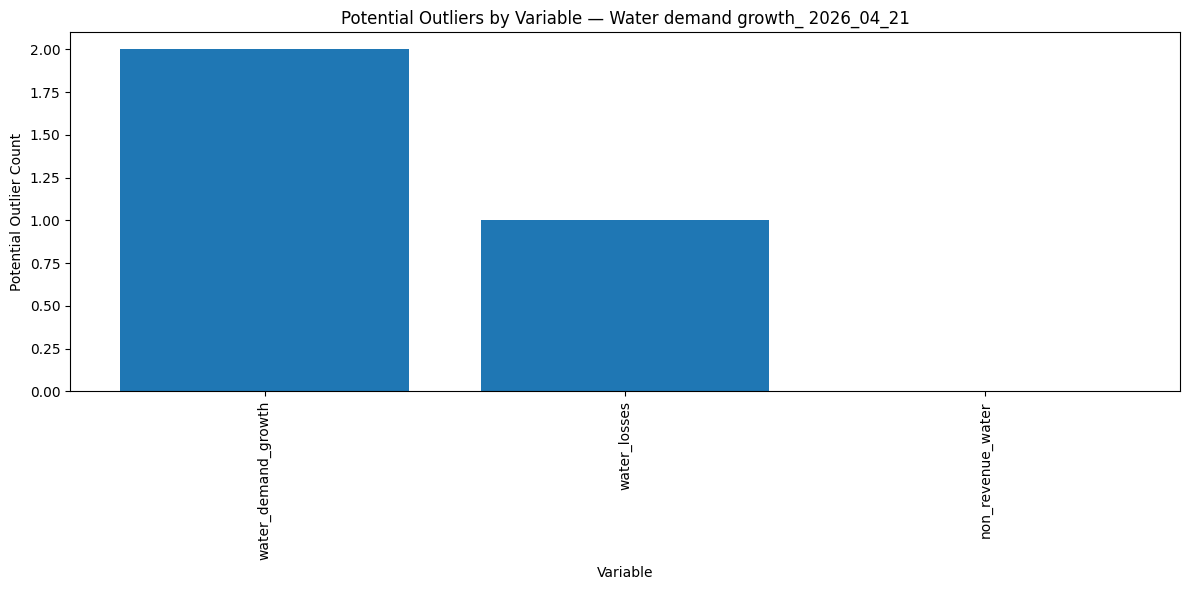

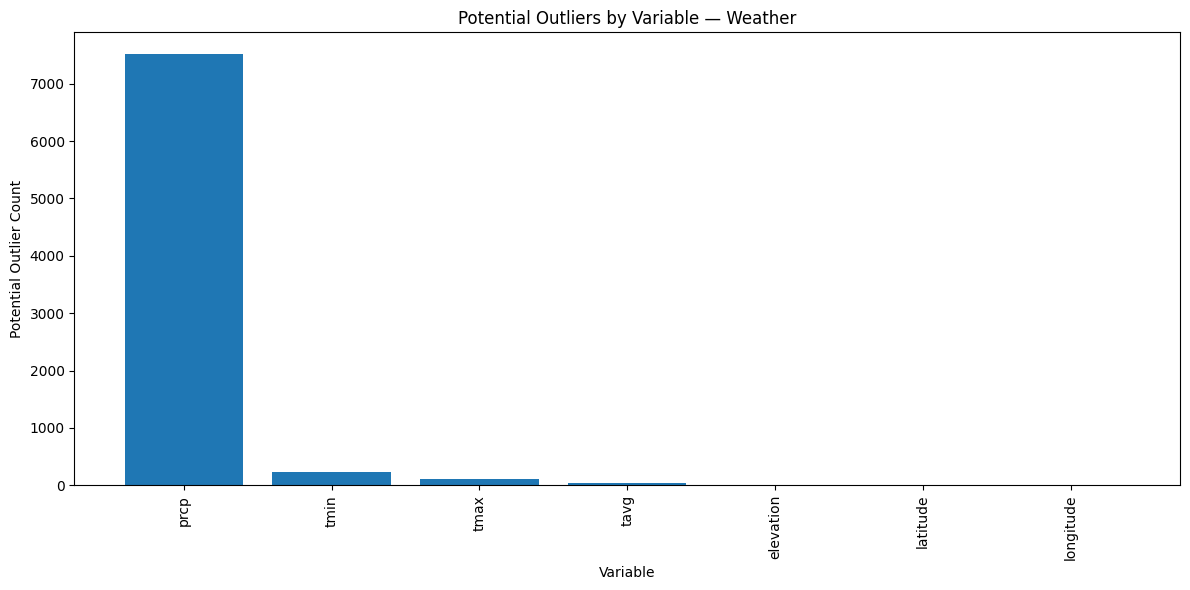

In [22]:
# ============================================================
# VISUALISATION — OUTLIER COUNTS
# ============================================================

for name in cleaned.keys():

    subset = outlier_df[
        outlier_df["Dataset"] == name
    ].copy()

    if subset.empty:
        continue

    subset = subset.sort_values(
        "IQR Outliers",
        ascending=False
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        subset["Column"].astype(str),
        subset["IQR Outliers"]
    )

    plt.title(
        f"Potential Outliers by Variable — {name}"
    )

    plt.xlabel(
        "Variable"
    )

    plt.ylabel(
        "Potential Outlier Count"
    )

    plt.xticks(
        rotation=90
    )

    plt.tight_layout()

    output_path = os.path.join(
        VISUALISATION_DIR,
        f"{name}_outlier_counts.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

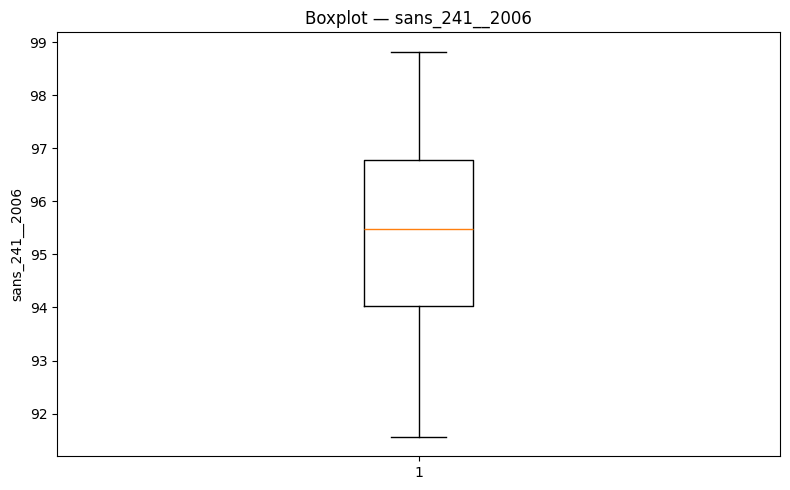

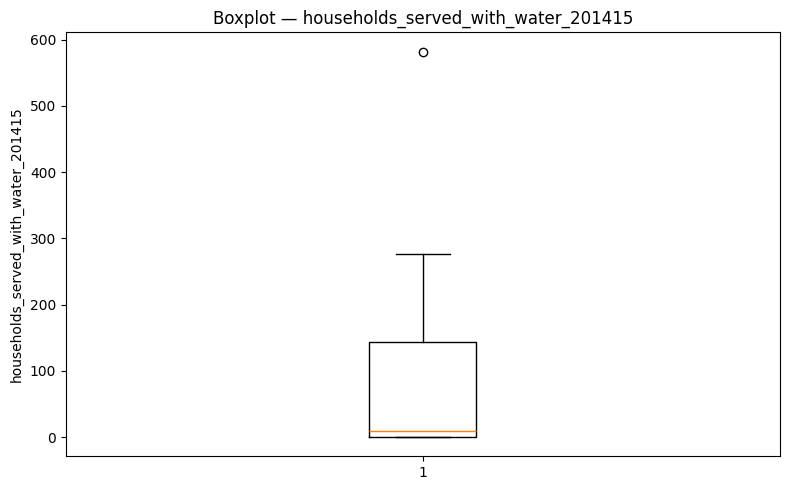

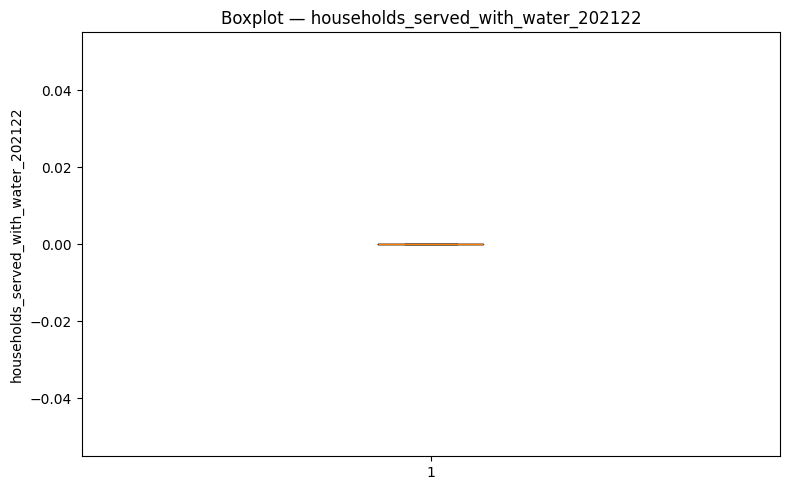

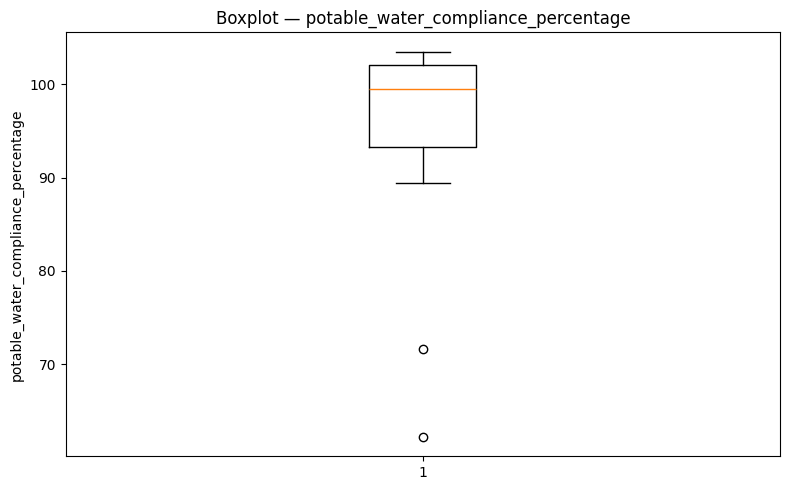

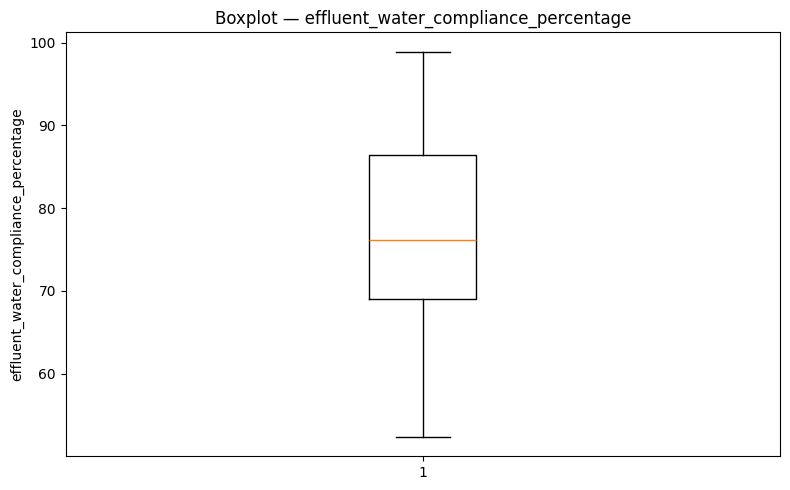

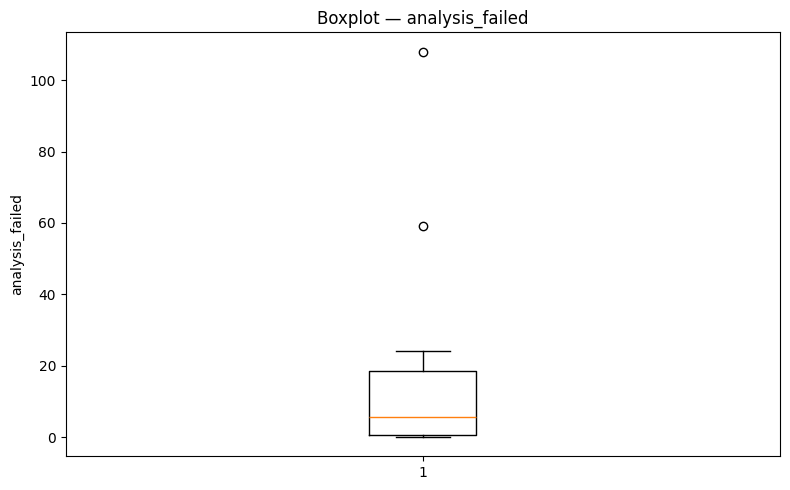

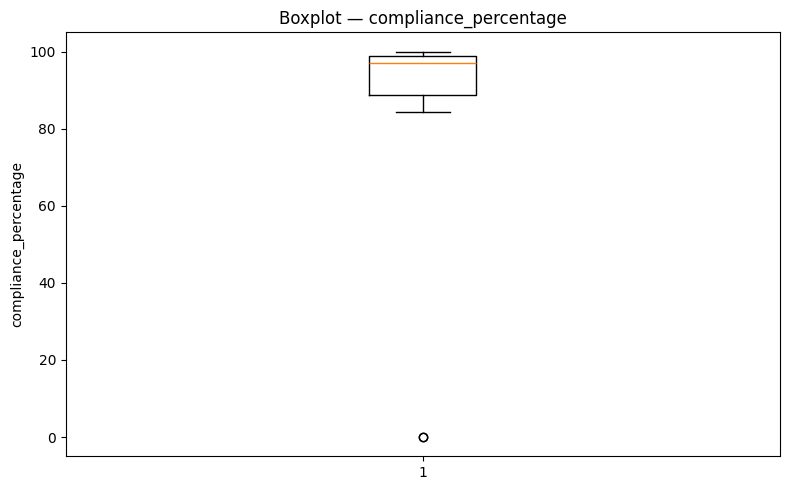

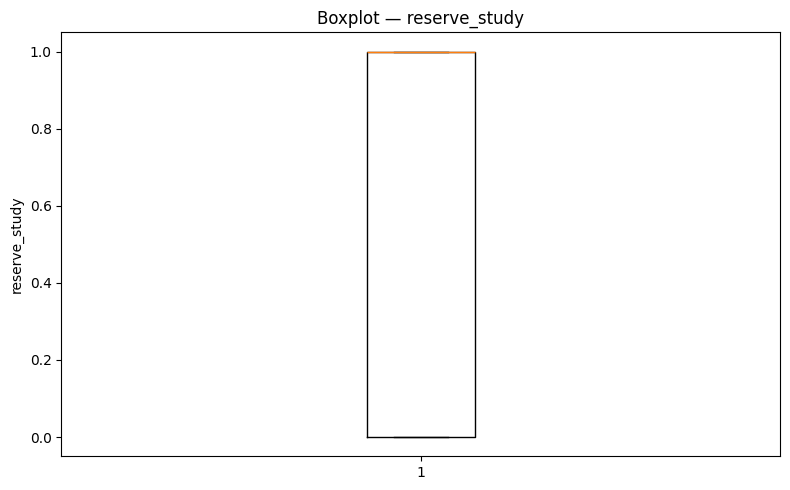

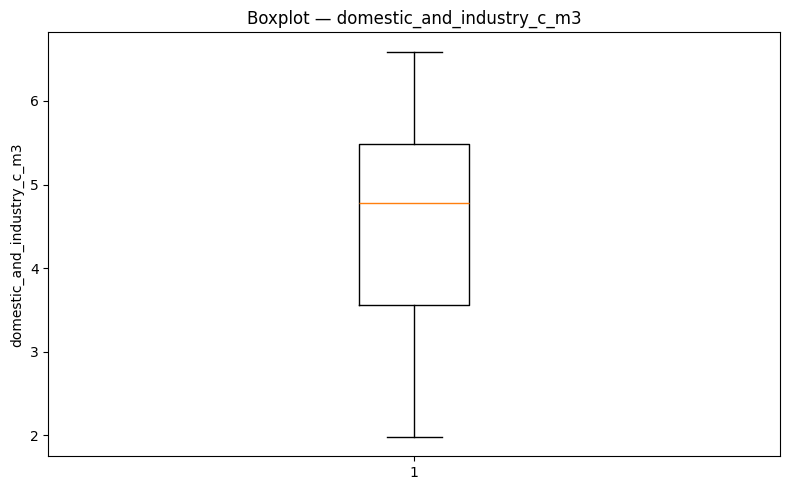

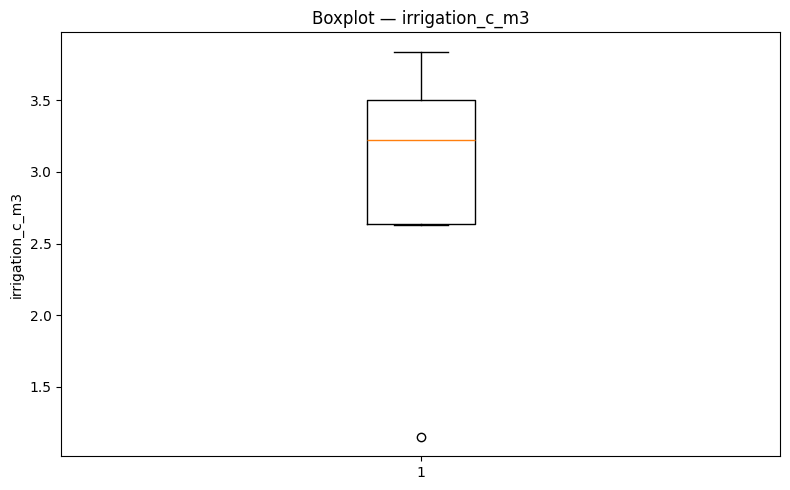

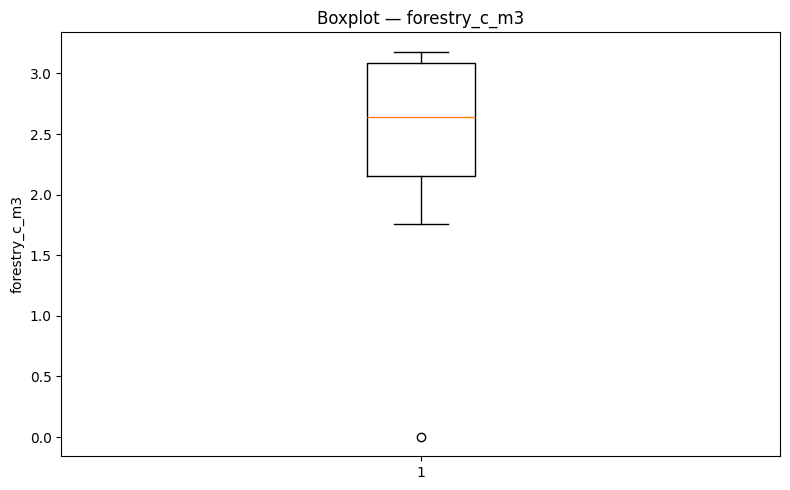

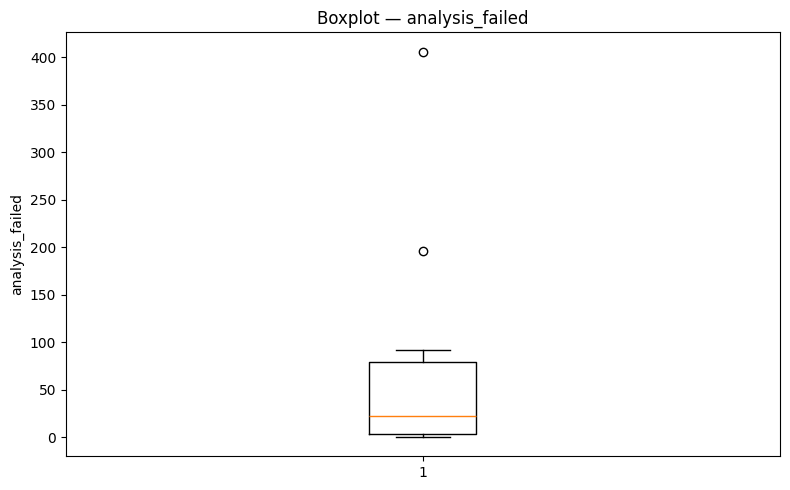

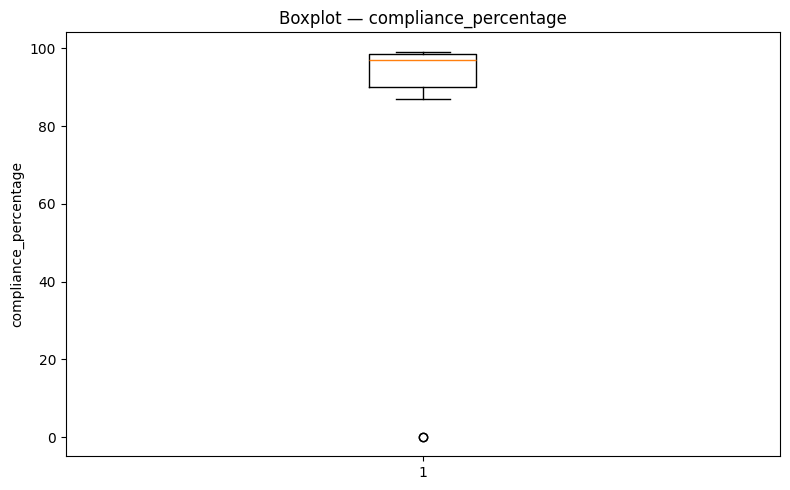

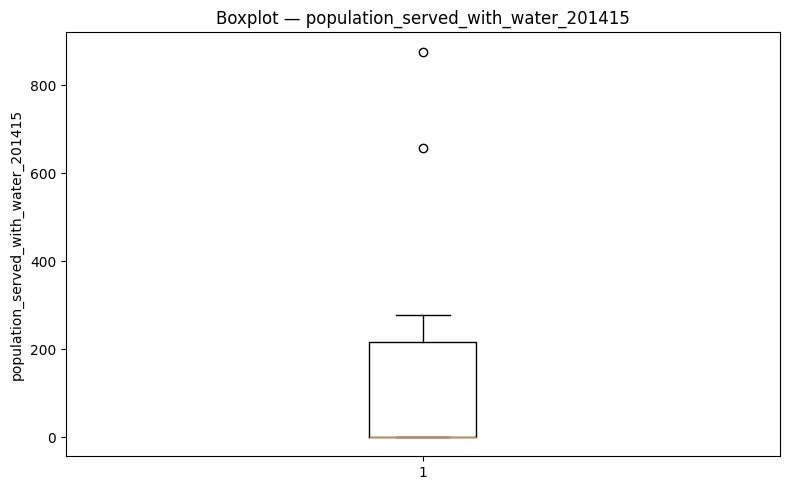

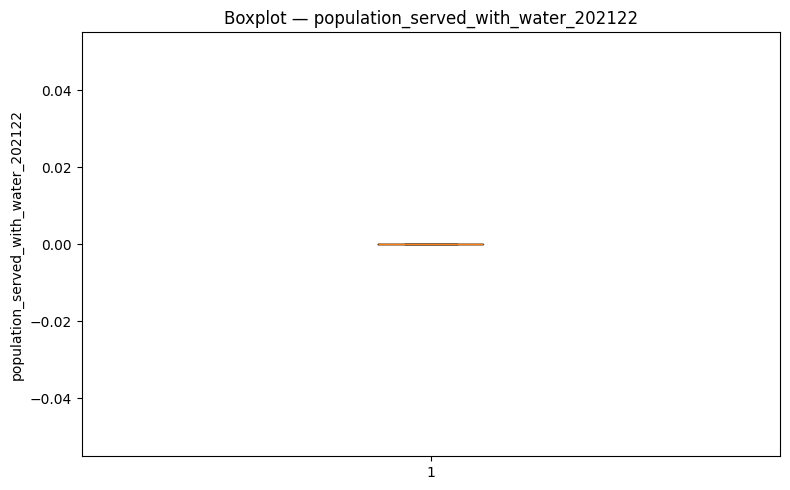

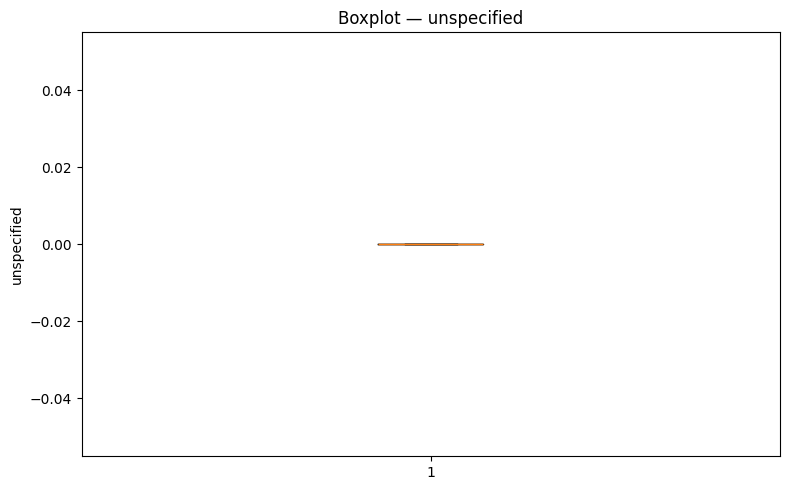

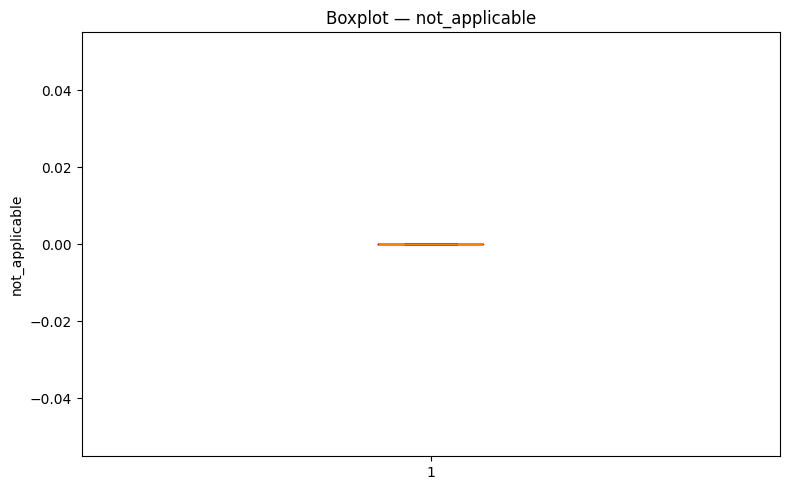

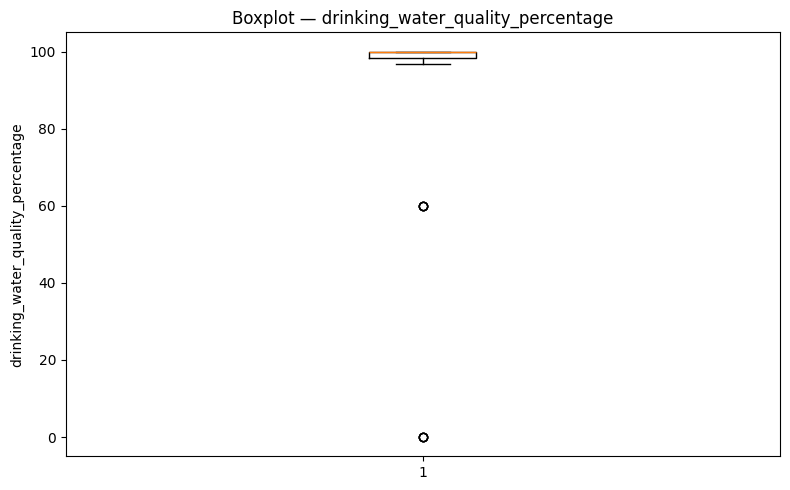

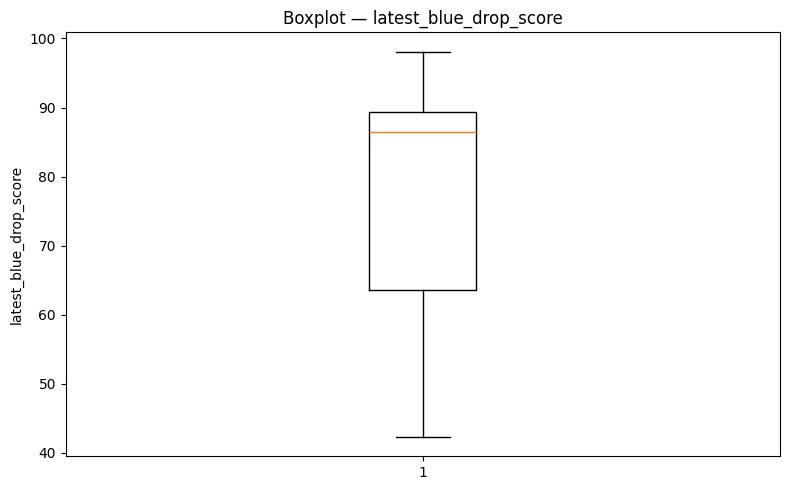

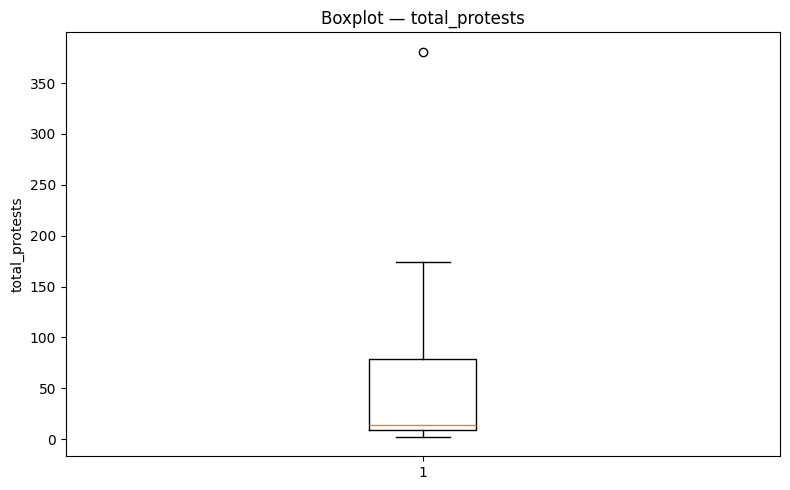

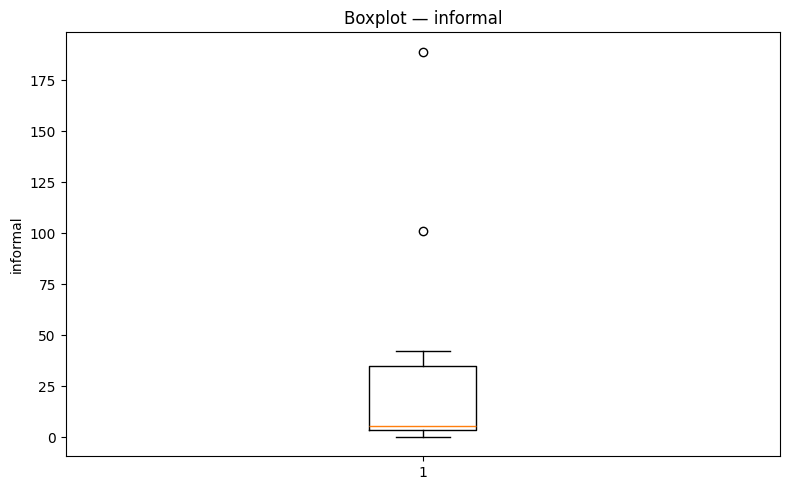

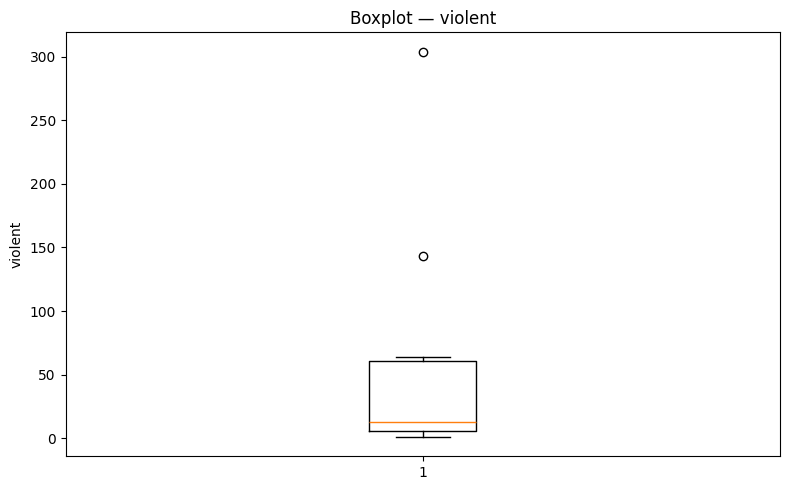

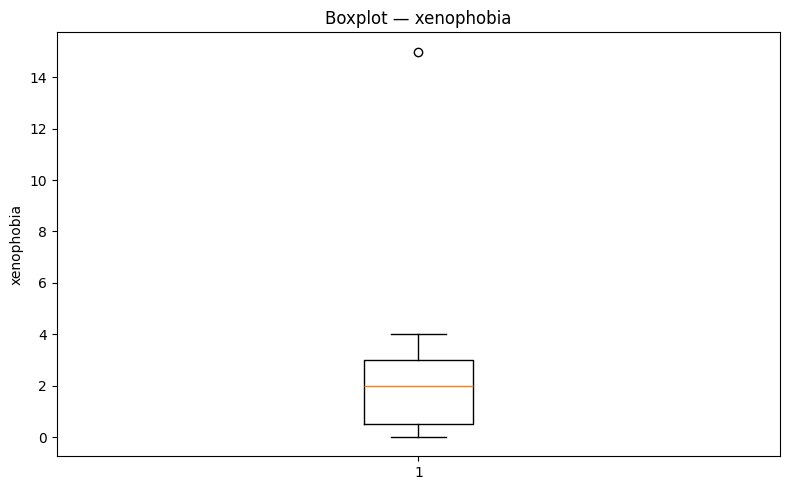

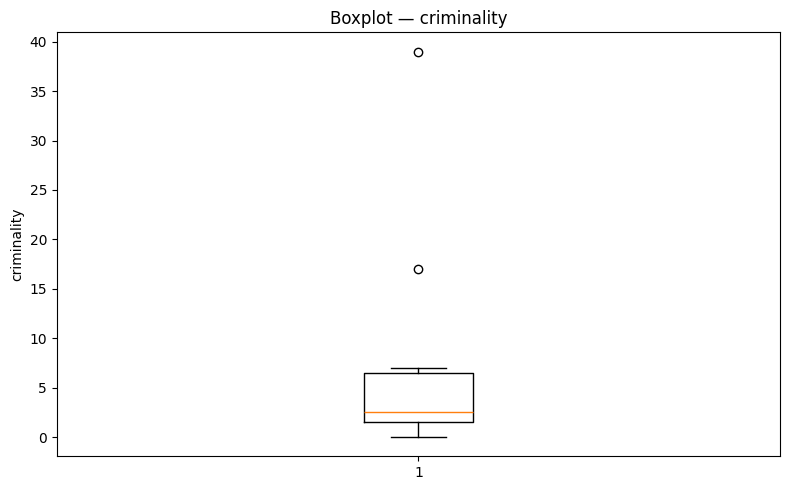

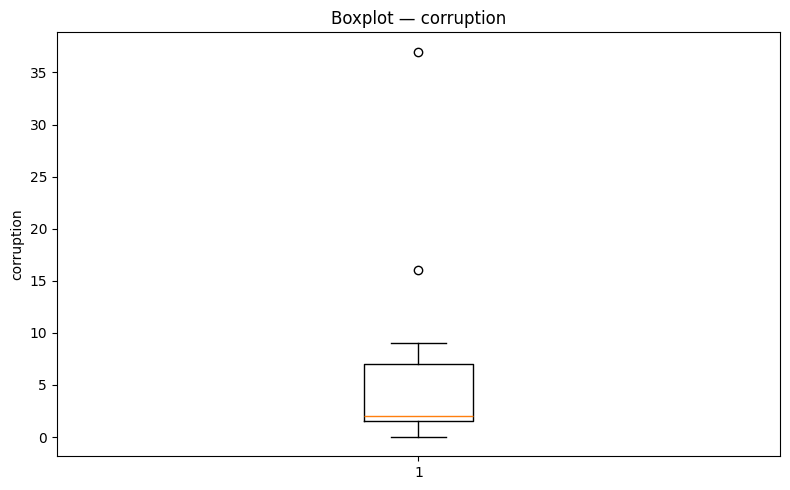

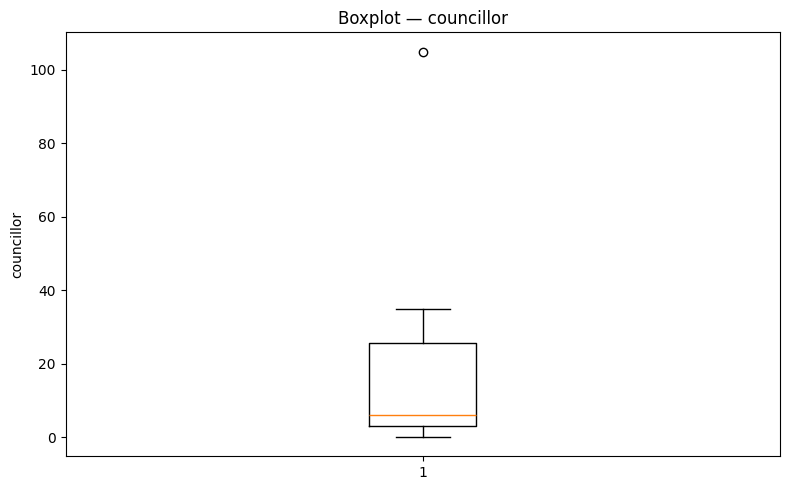

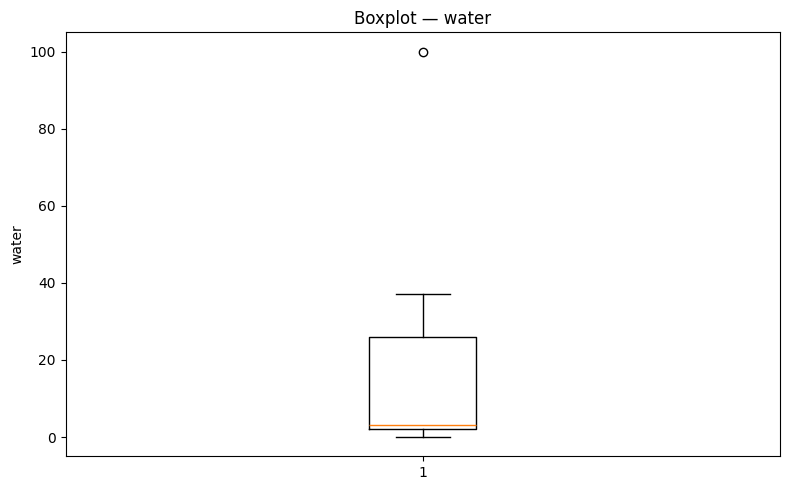

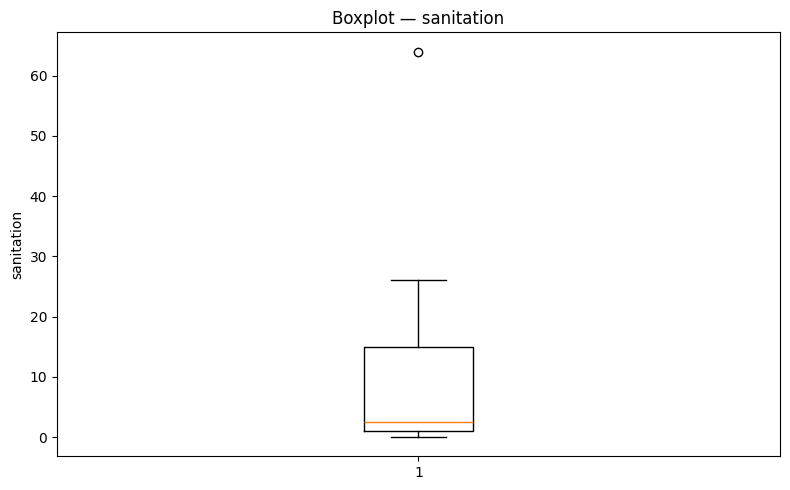

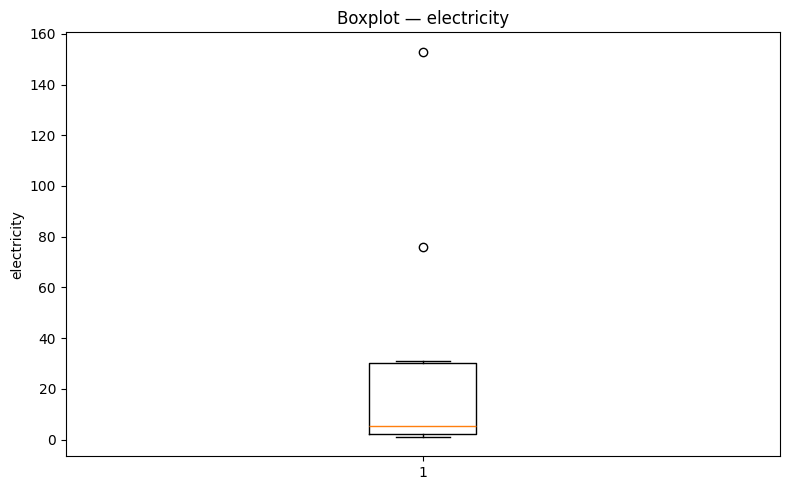

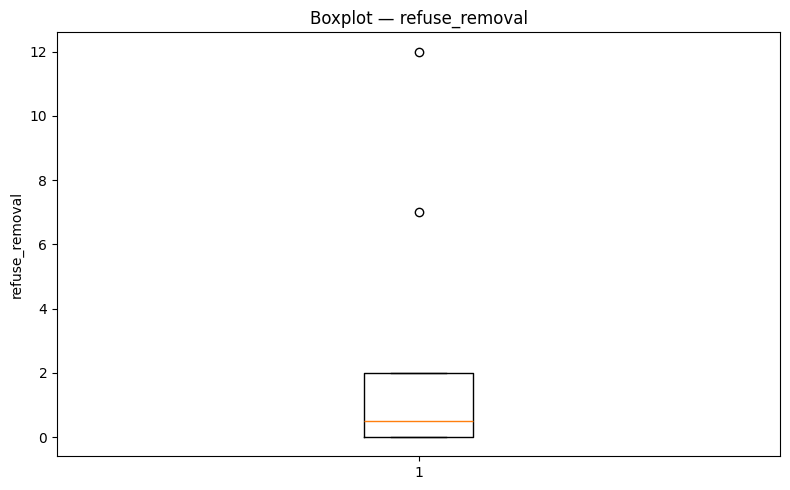

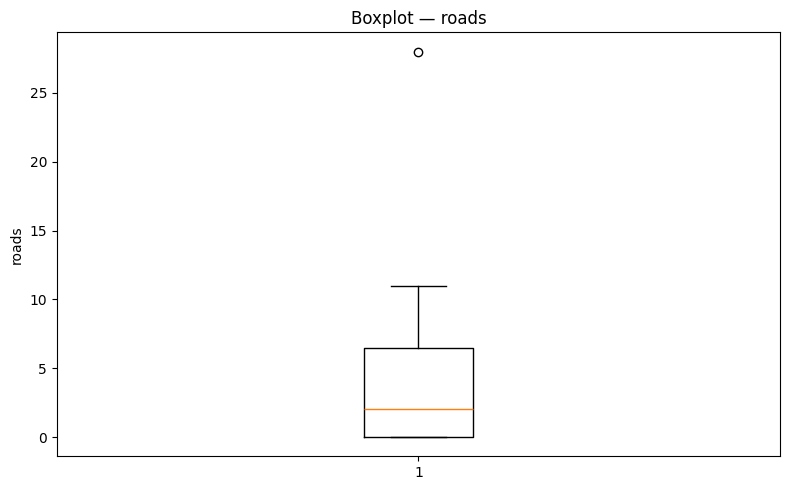

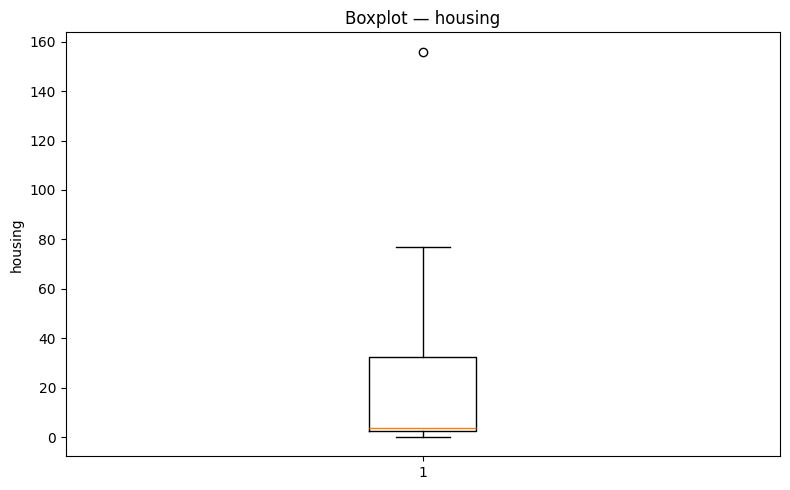

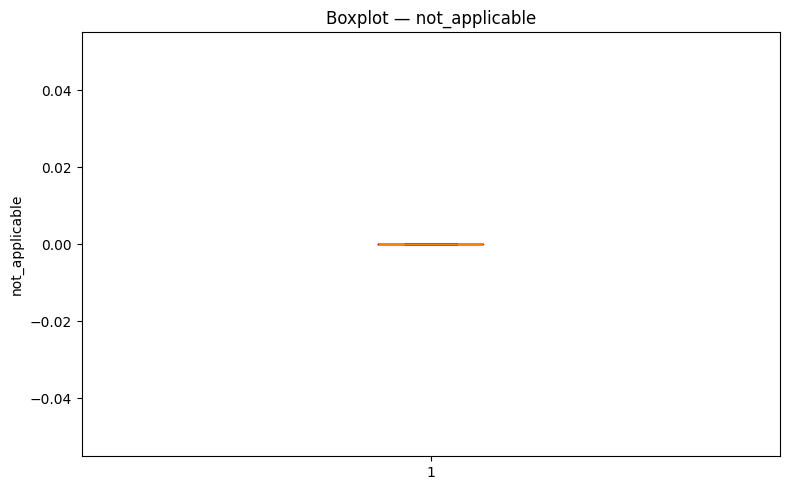

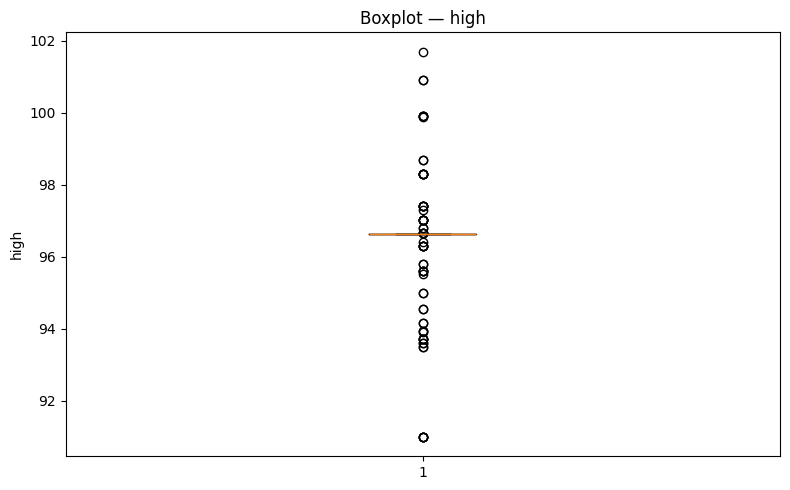

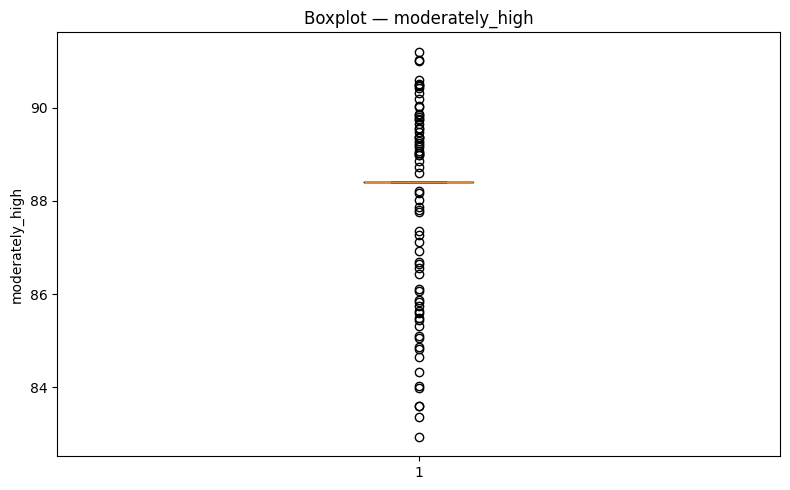

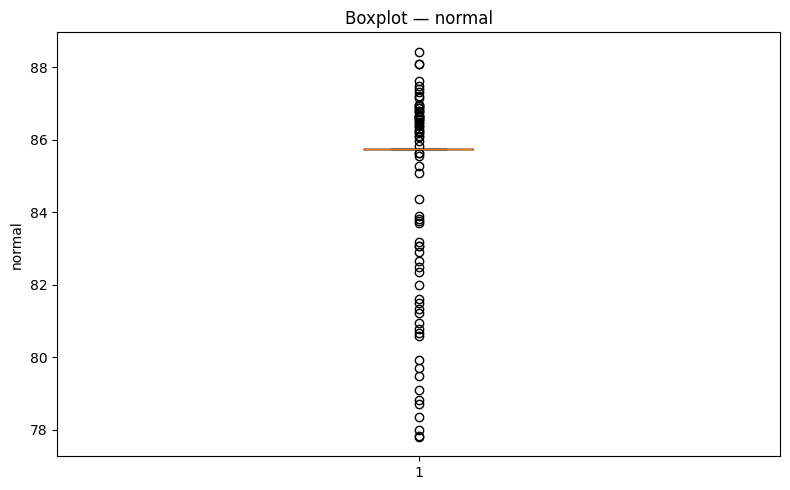

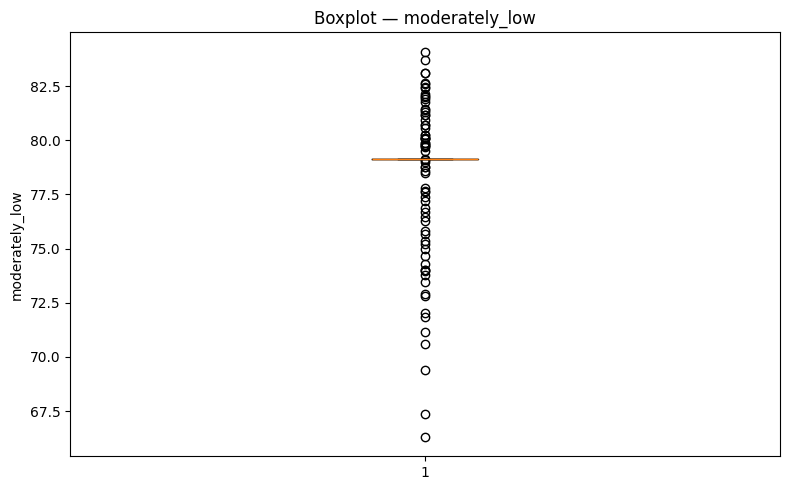

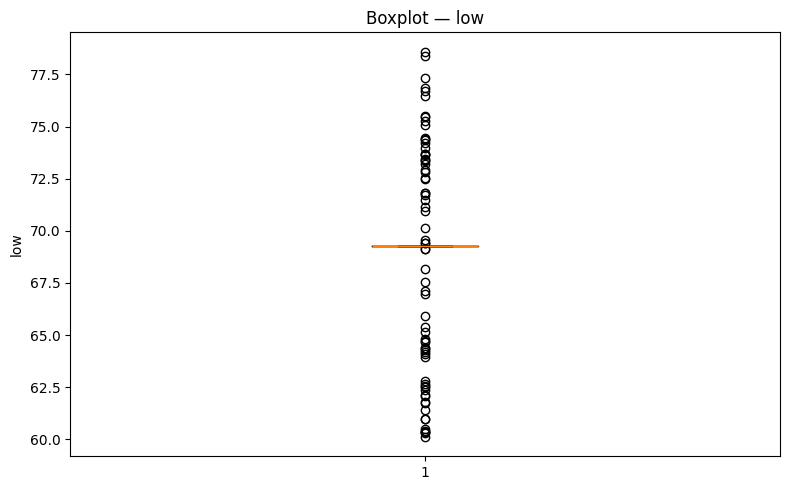

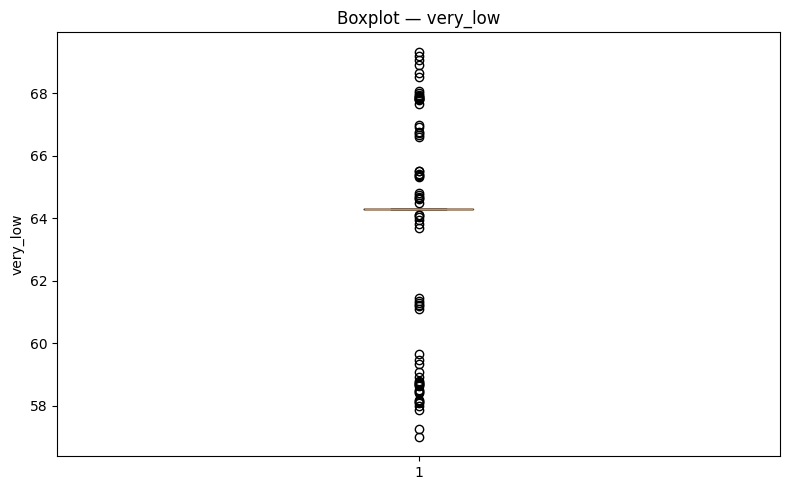

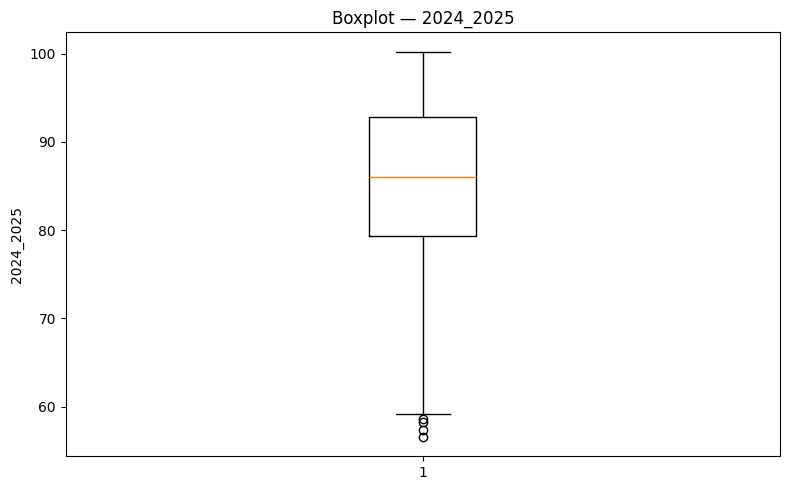

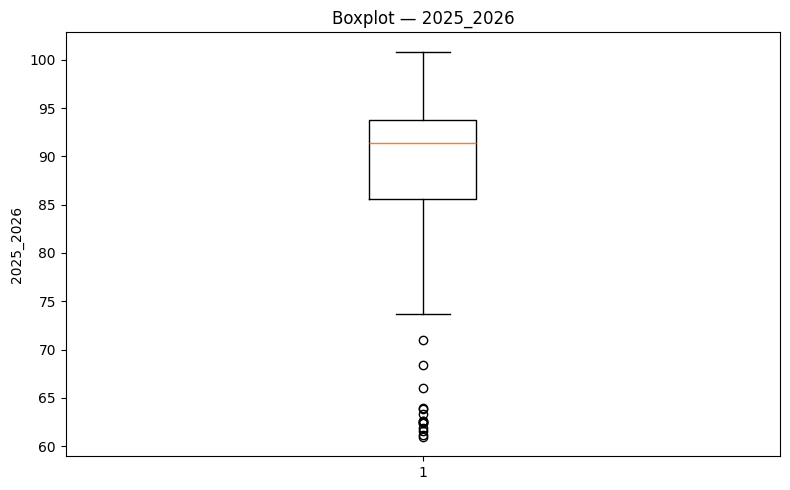

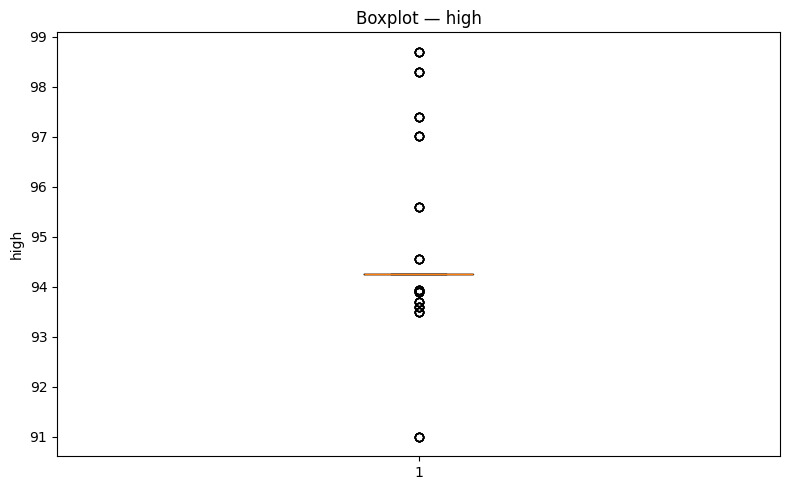

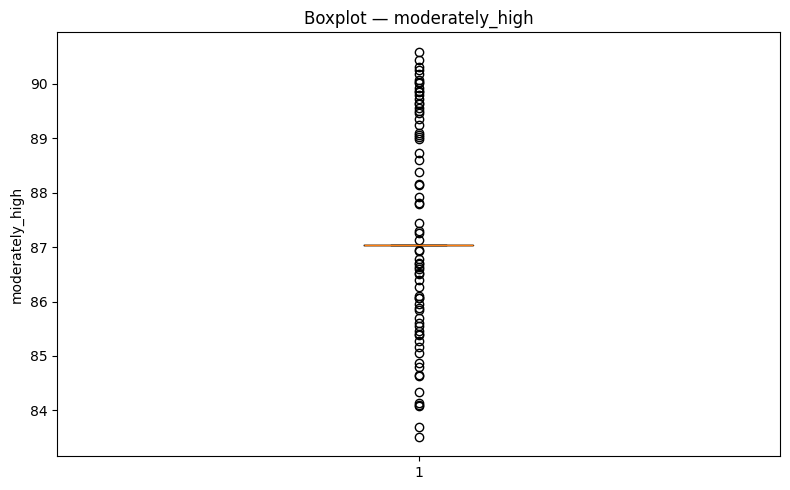

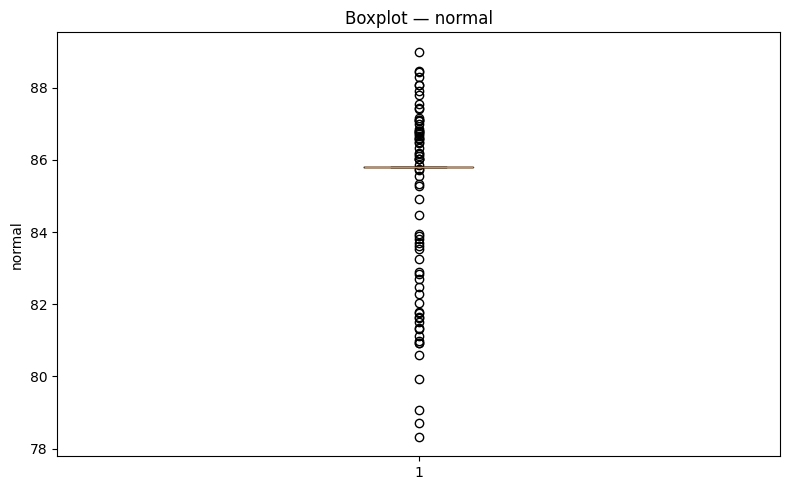

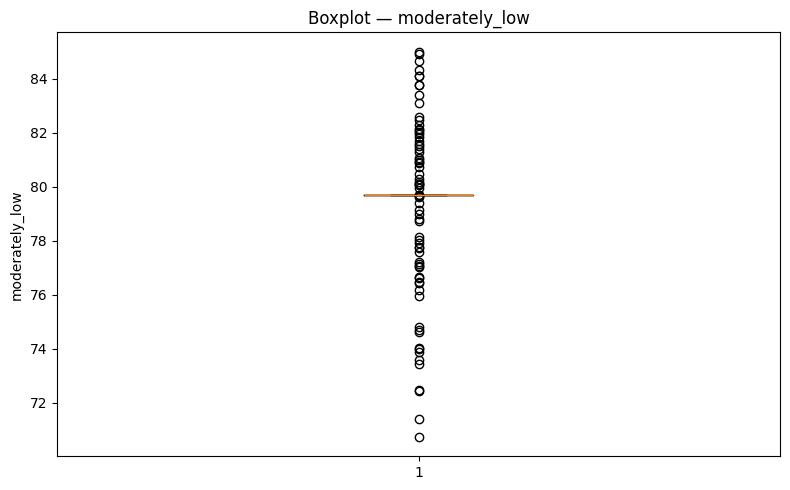

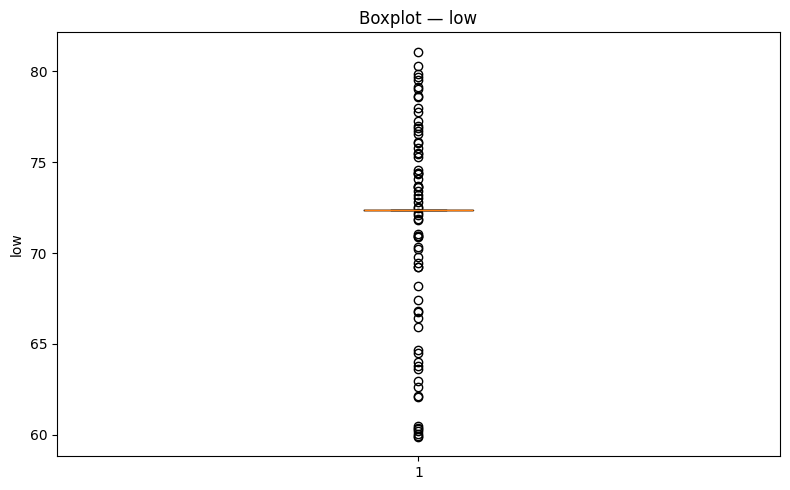

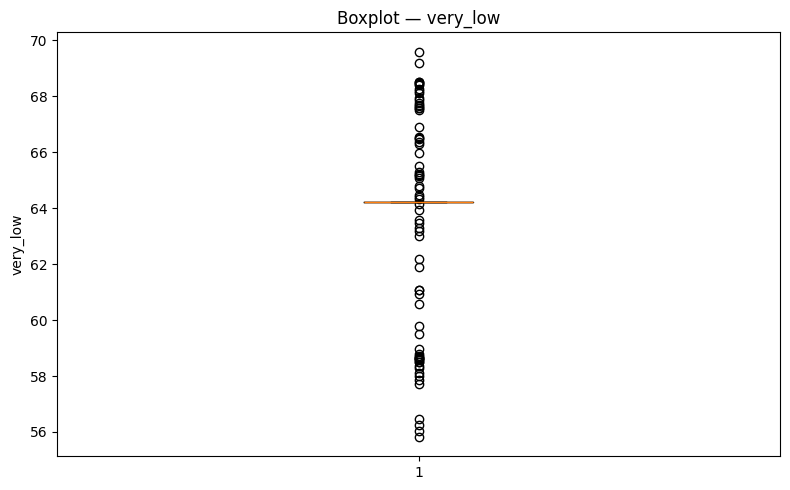

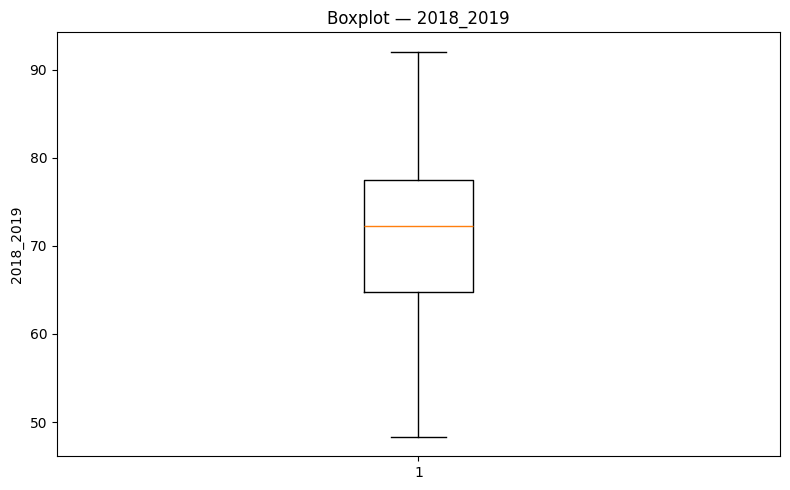

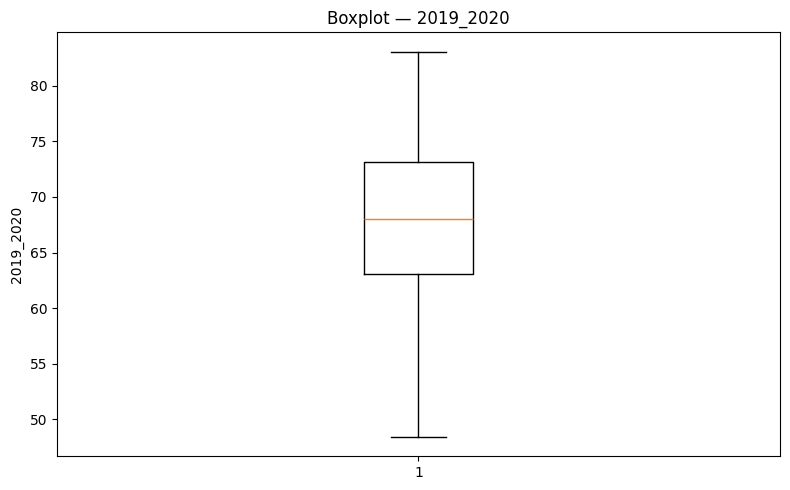

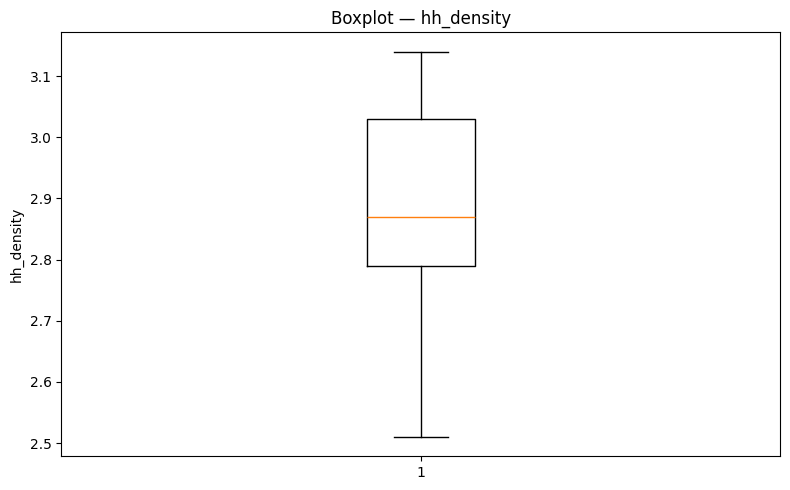

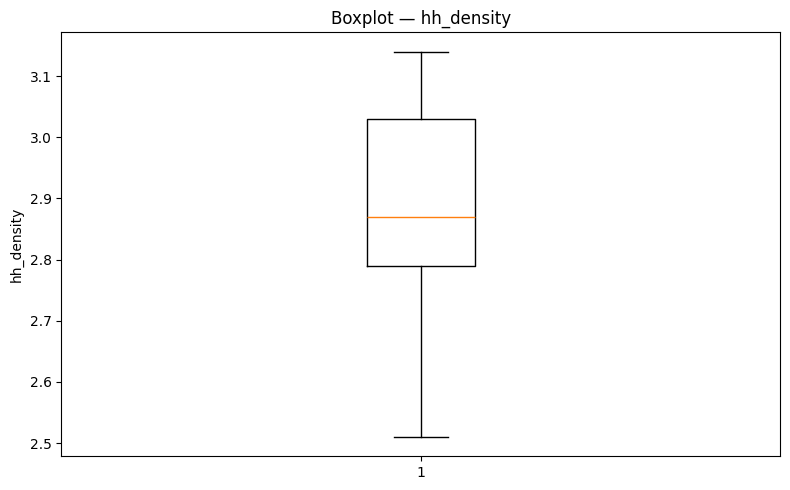

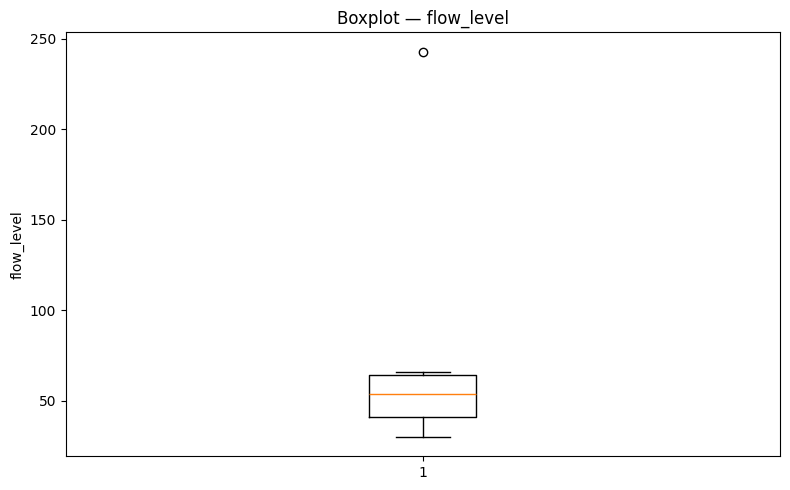

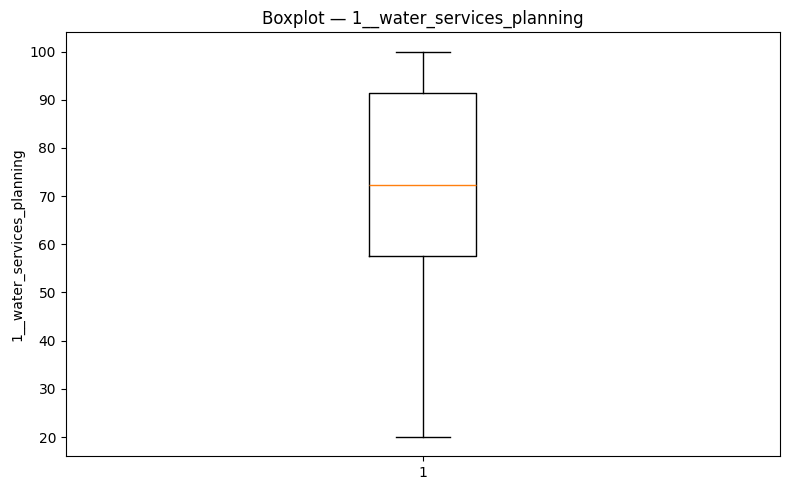

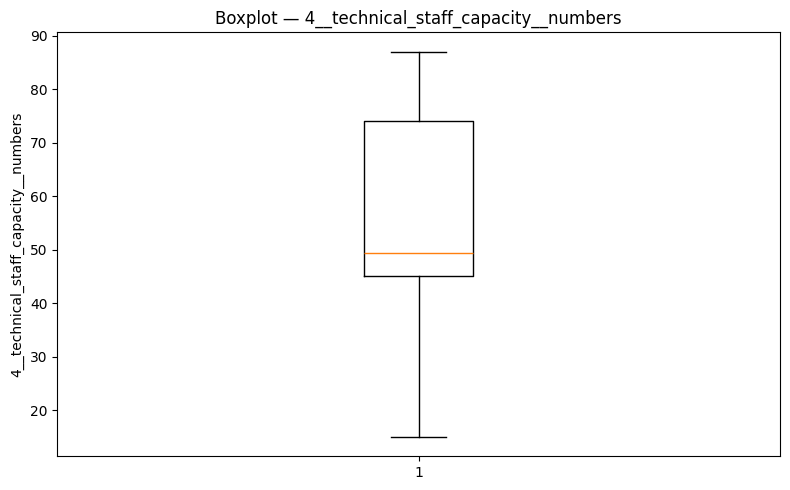

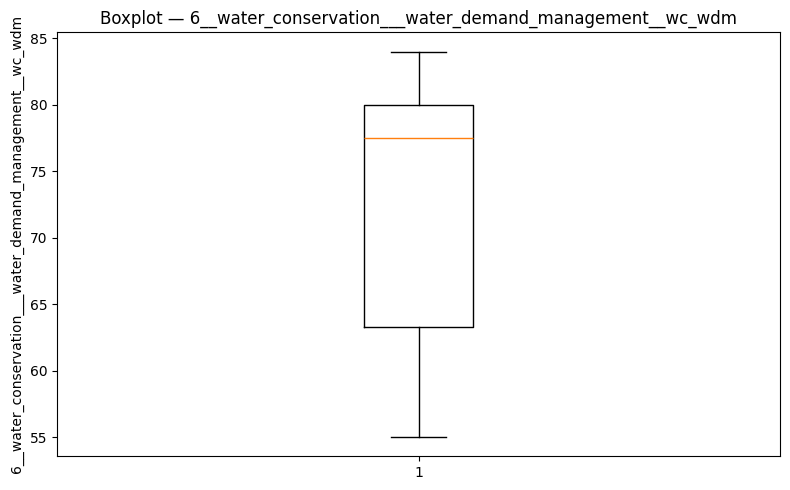

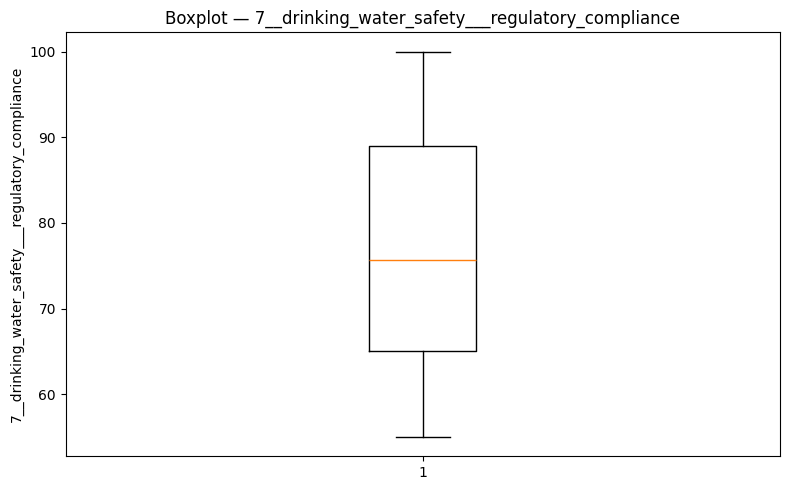

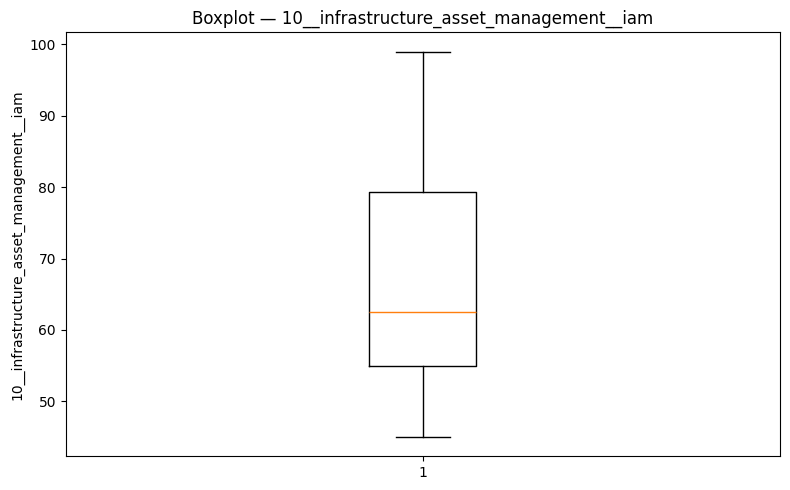

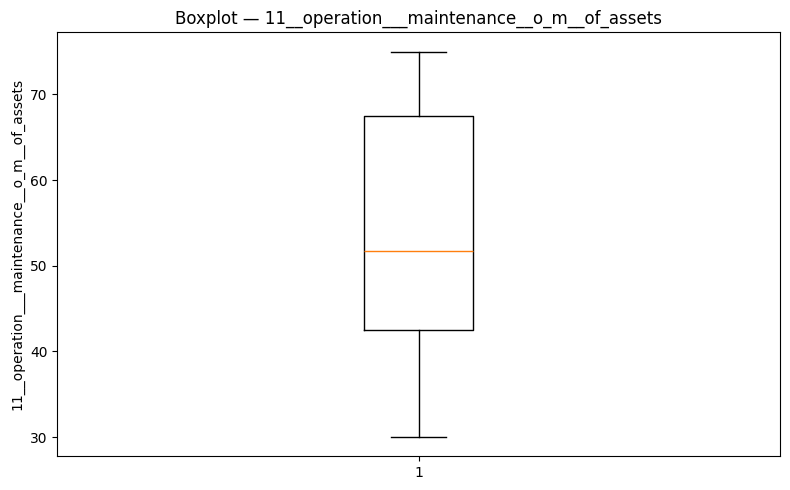

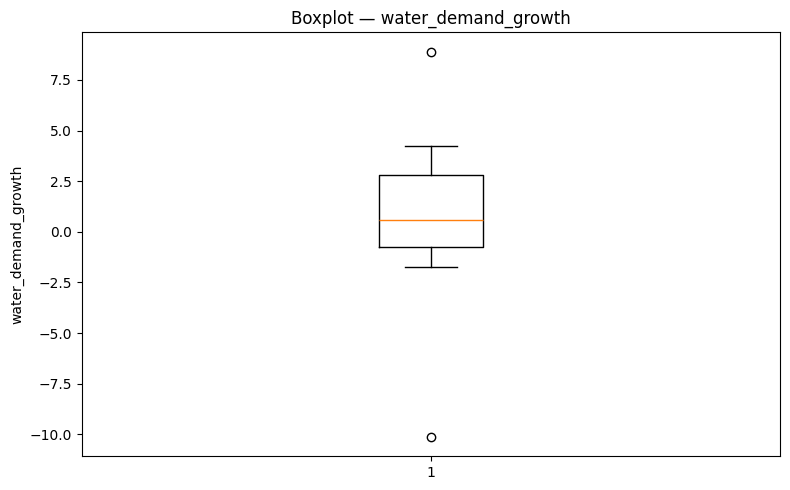

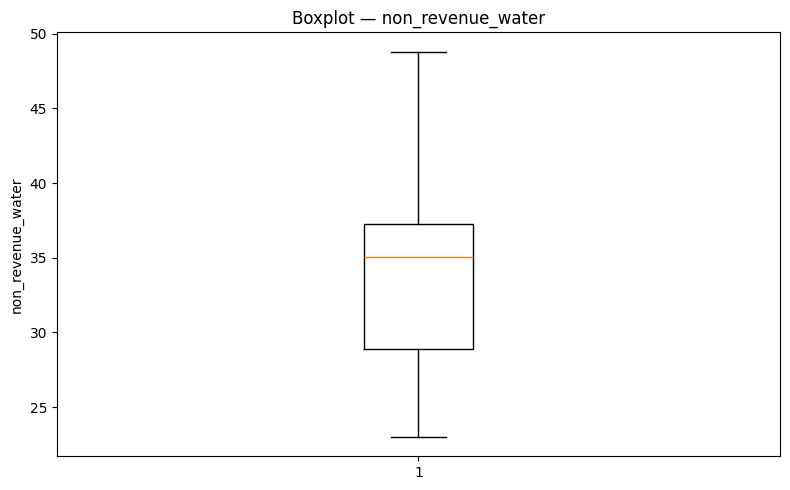

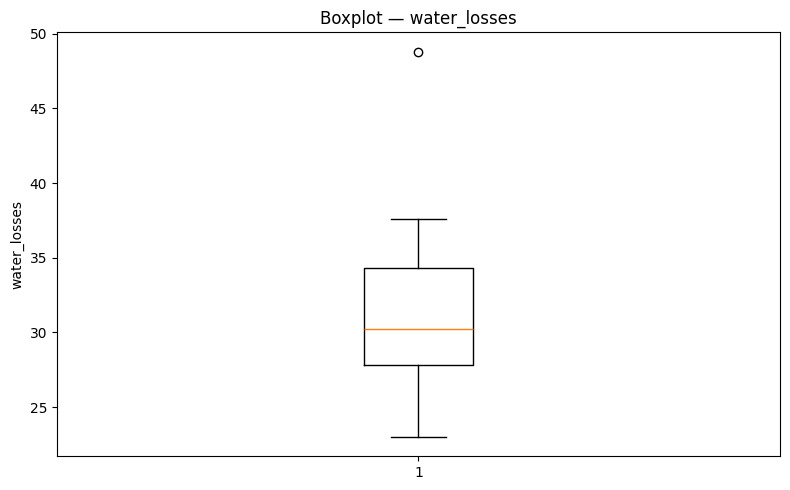

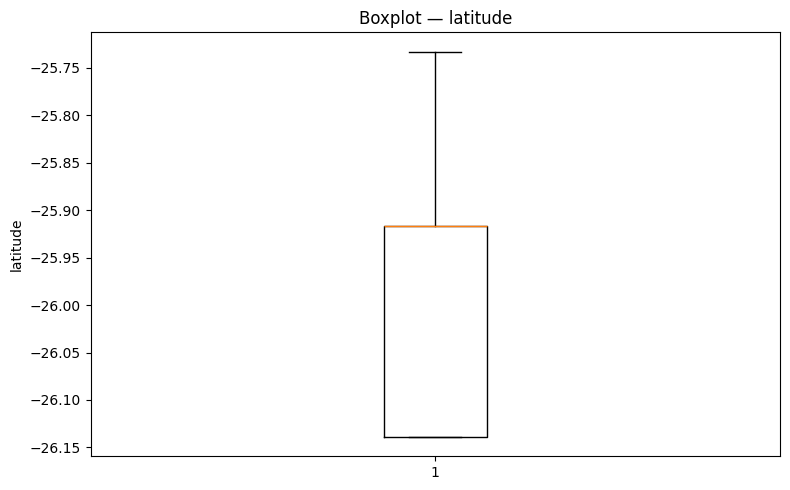

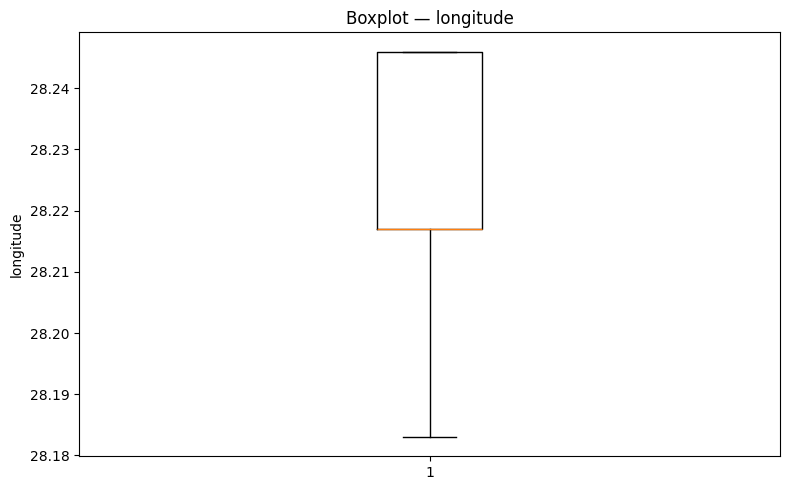

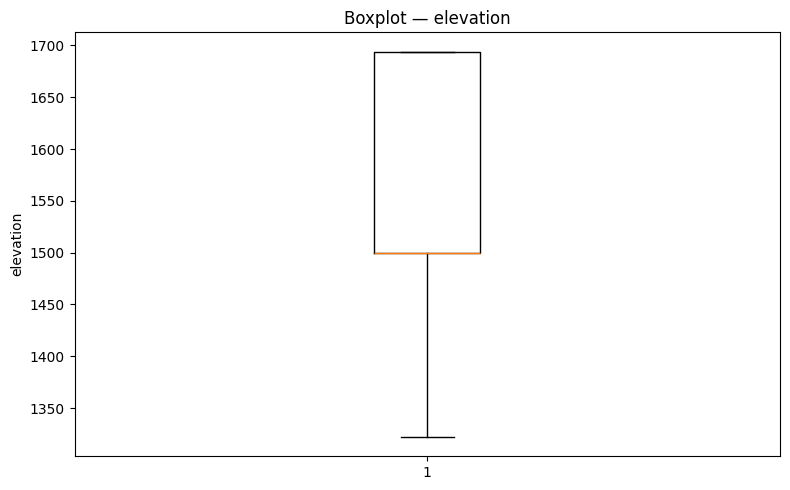

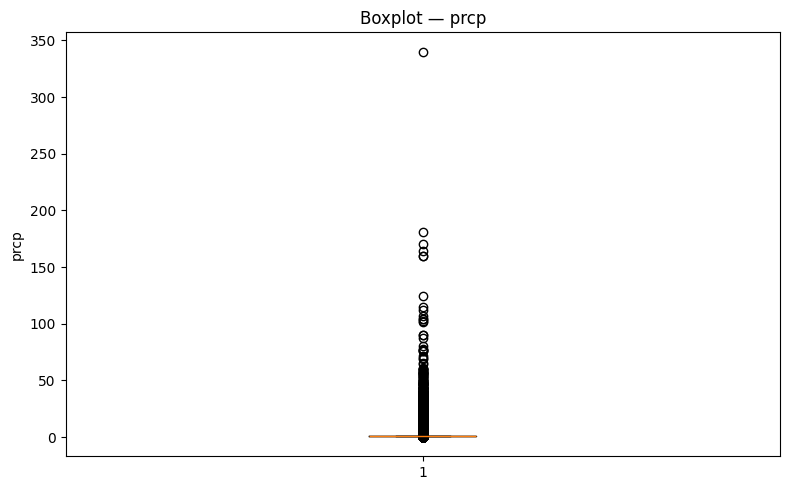

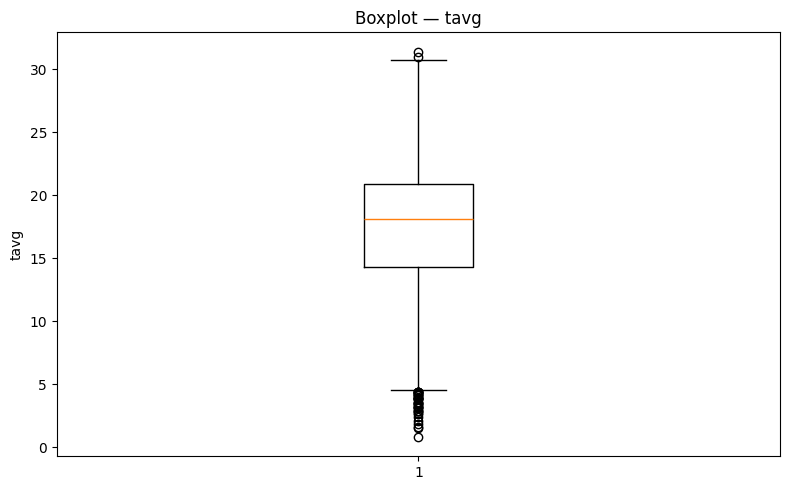

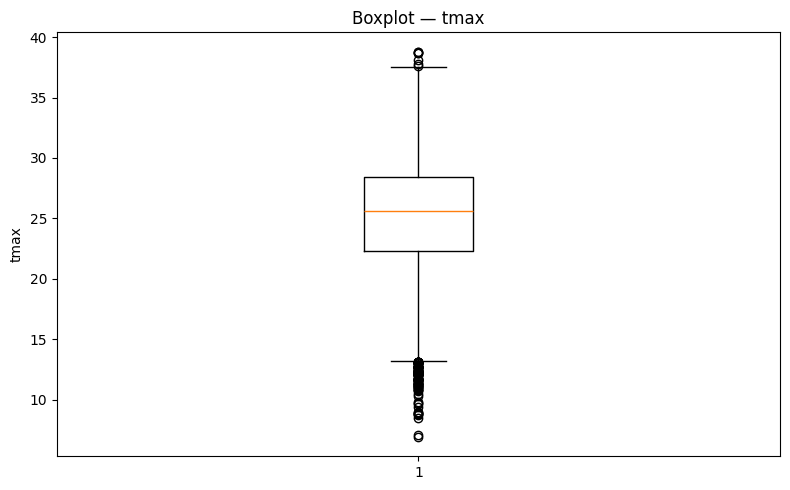

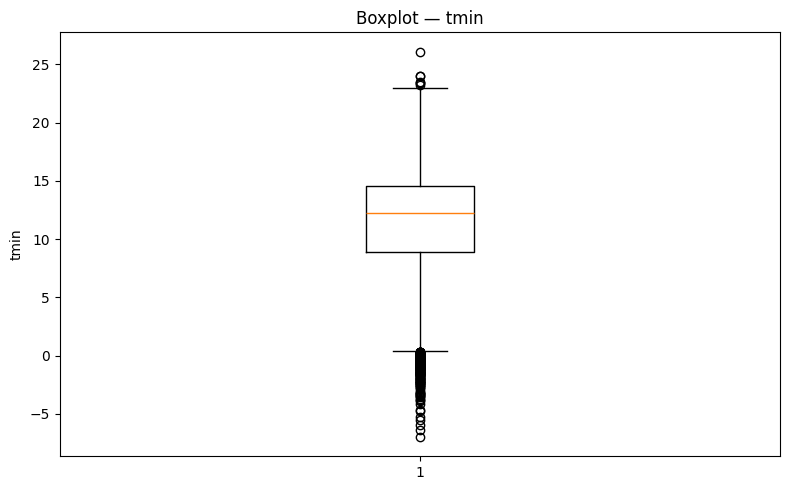

In [23]:
# ============================================================
# VISUALISATION — BOX PLOTS
# ============================================================

for name, df in cleaned.items():

    numeric_columns = (
        df.select_dtypes(
            include=np.number
        ).columns
    )

    for col in numeric_columns:

        series = df[col].dropna()

        if series.empty:
            continue

        plt.figure(
            figsize=(8, 5)
        )

        plt.boxplot(
            series,
            vert=True
        )

        plt.title(
            f"Boxplot — {col}"
        )

        plt.ylabel(
            str(col)
        )

        plt.tight_layout()

        safe_name = (
            str(col)
            .replace("/", "_")
            .replace("\\", "_")
            .replace(" ", "_")
        )

        output_path = os.path.join(
            VISUALISATION_DIR,
            f"{name}_{safe_name}_boxplot.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()

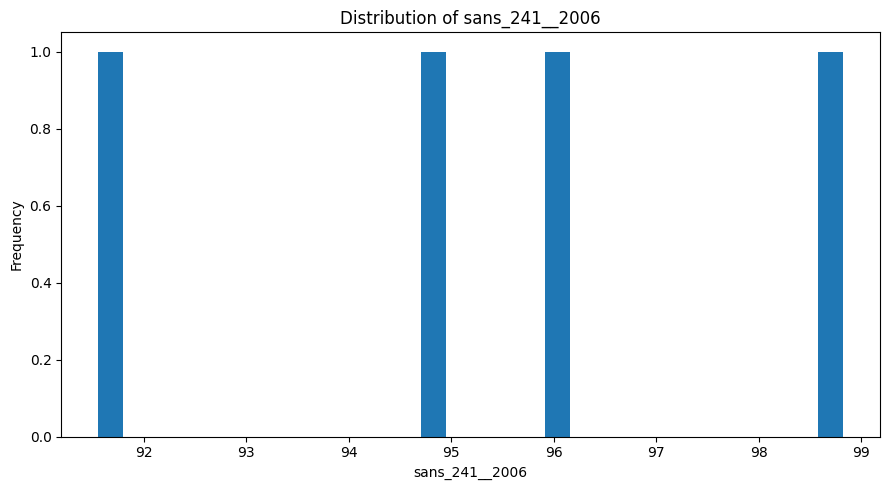

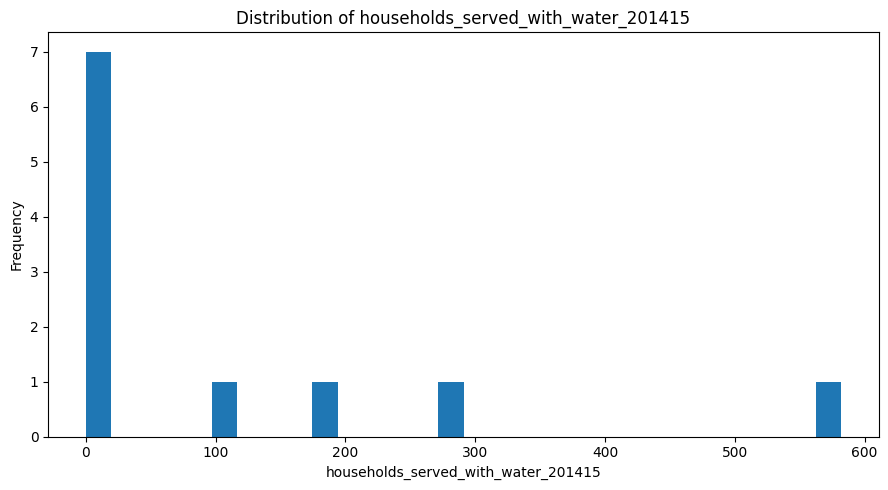

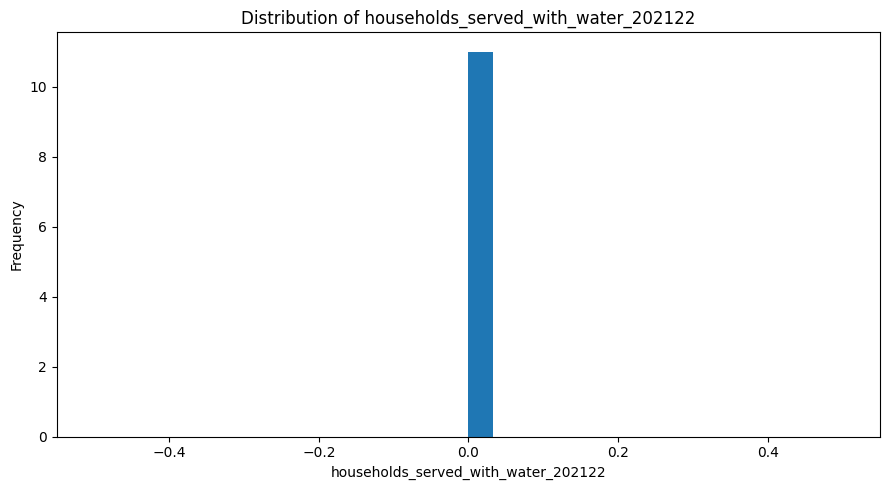

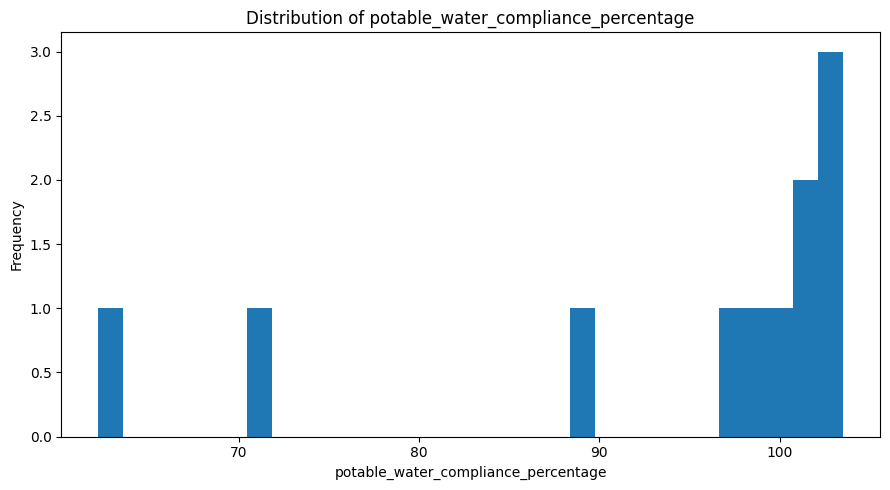

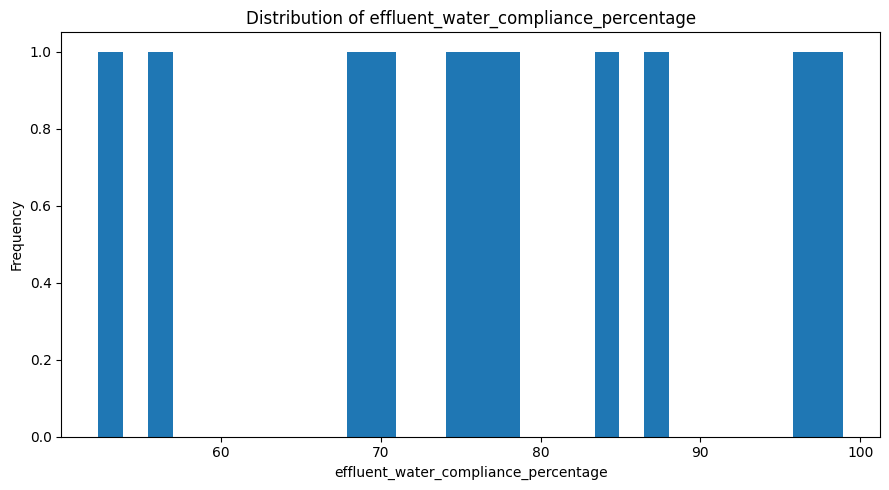

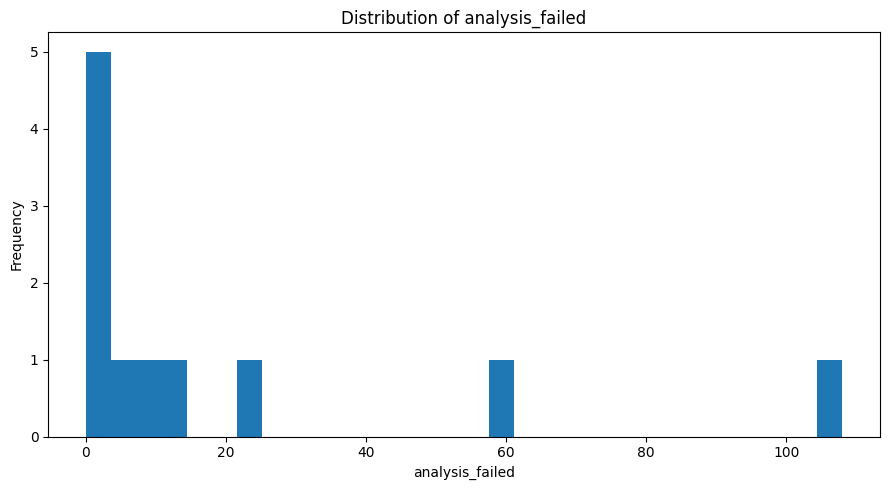

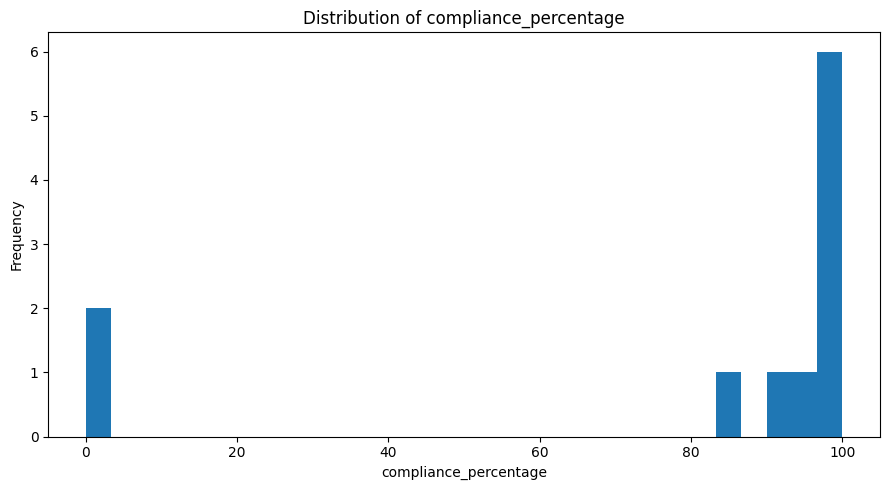

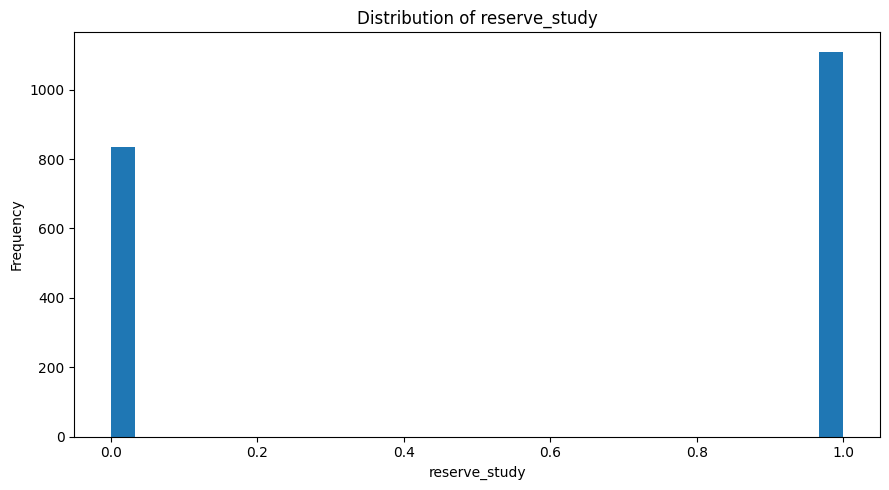

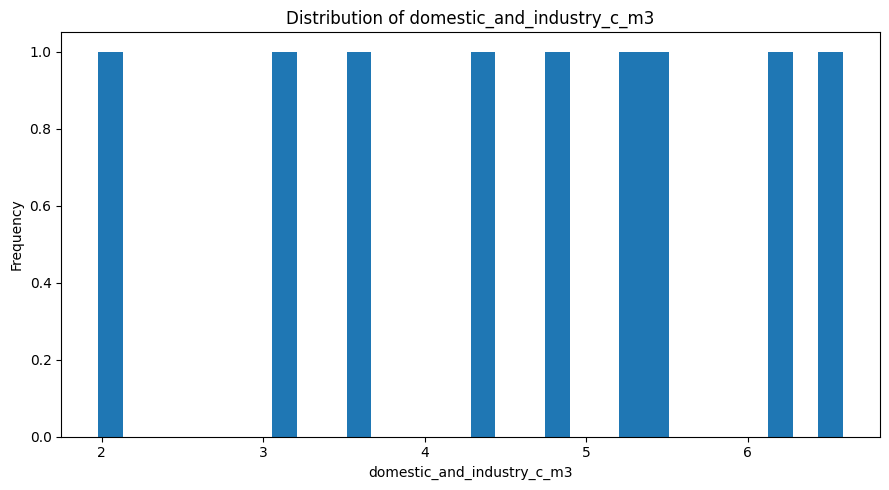

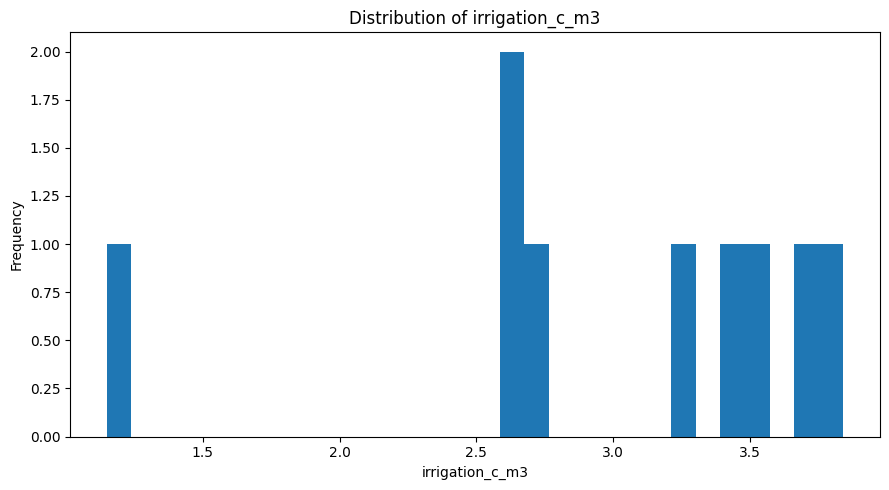

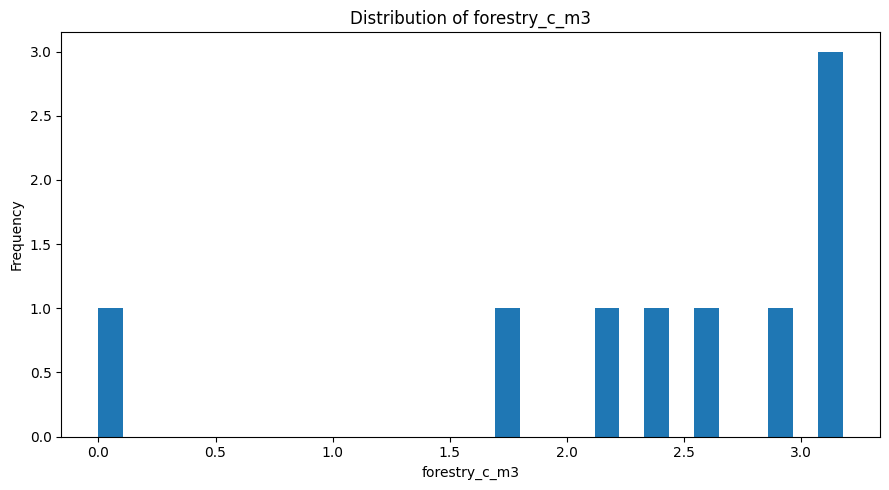

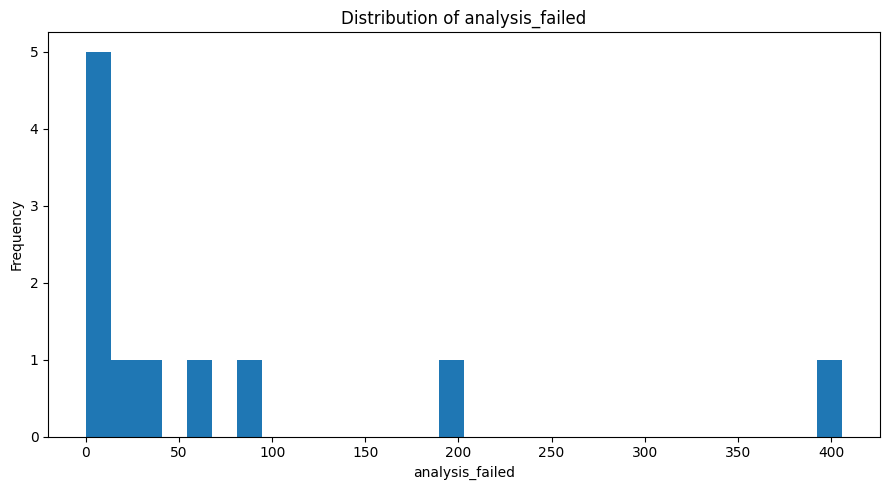

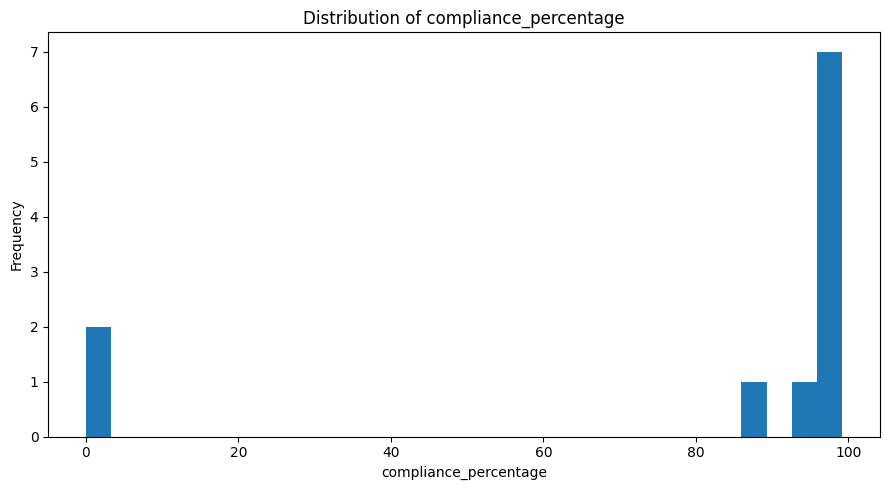

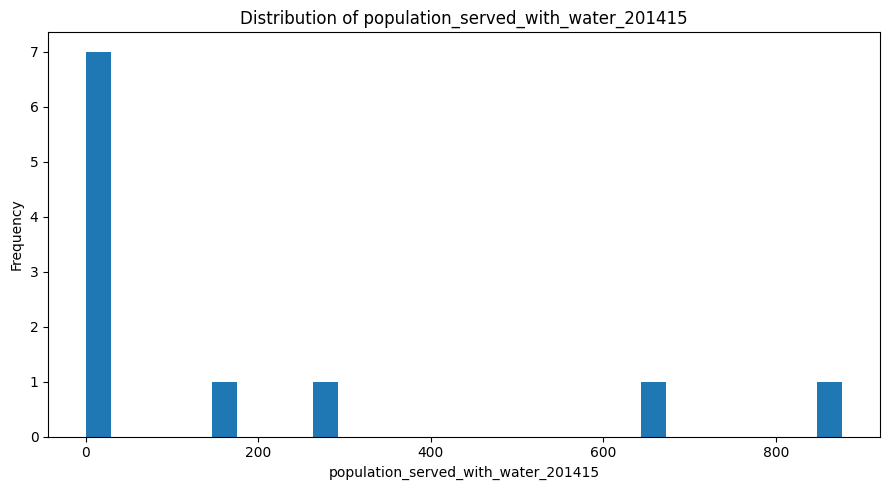

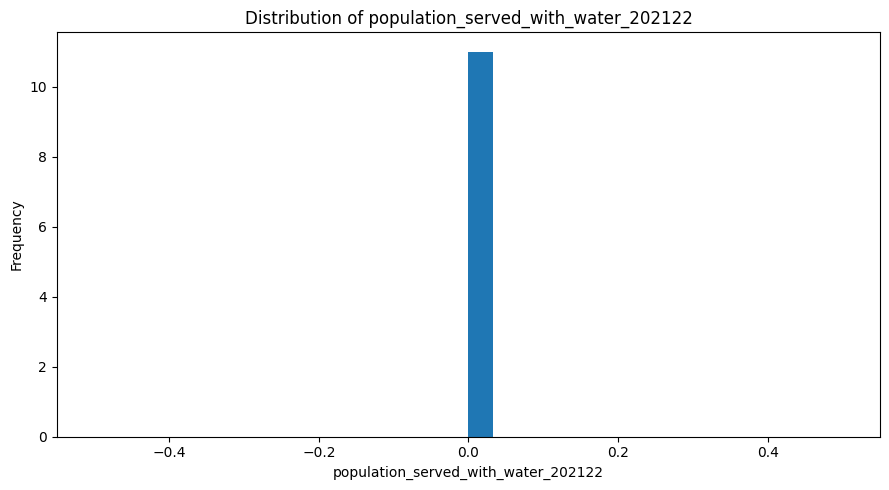

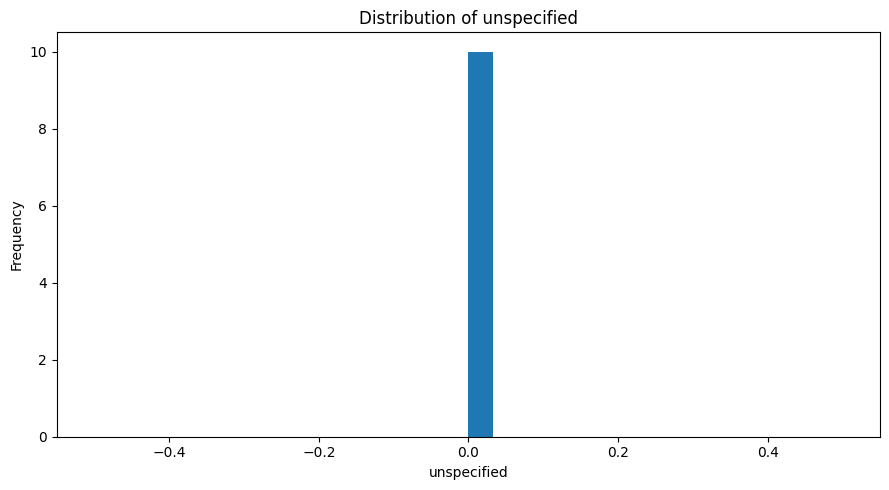

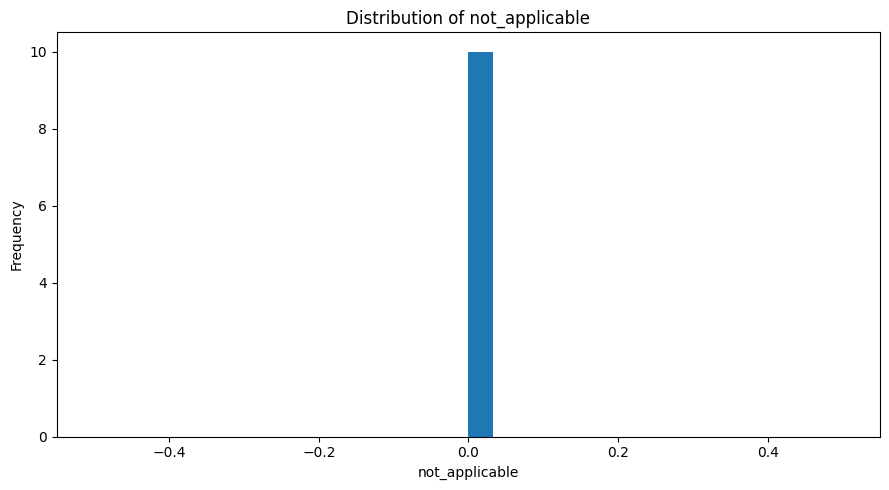

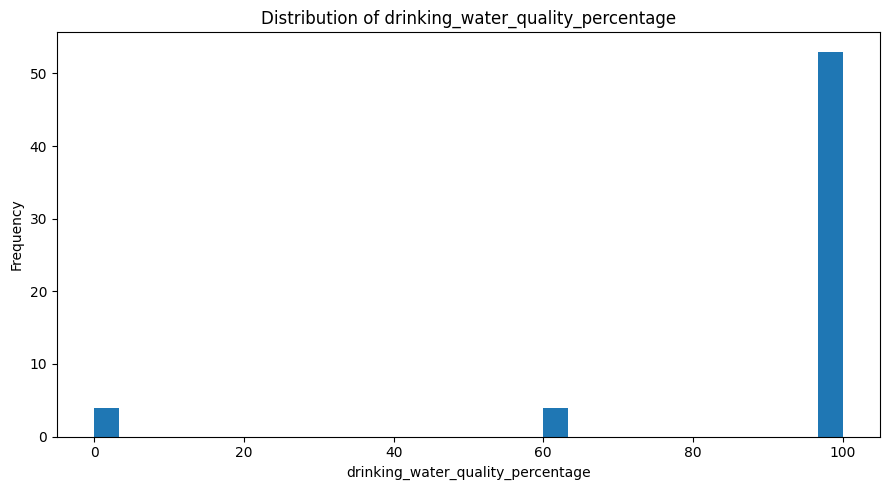

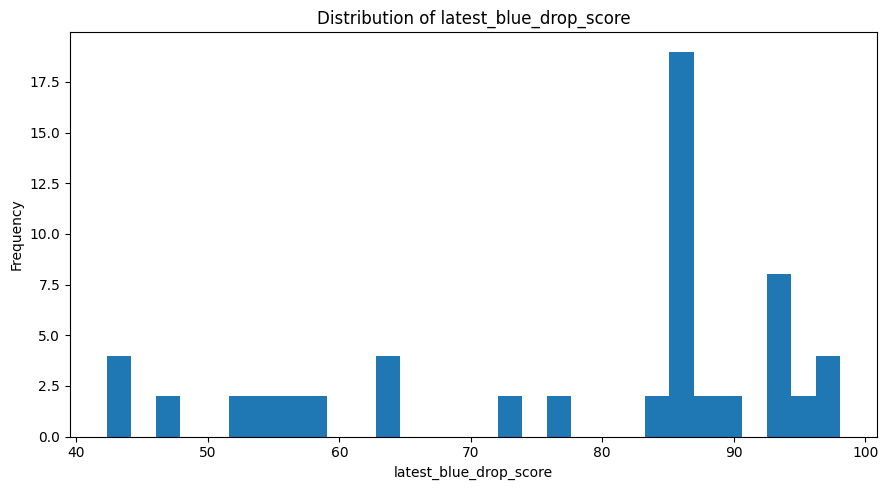

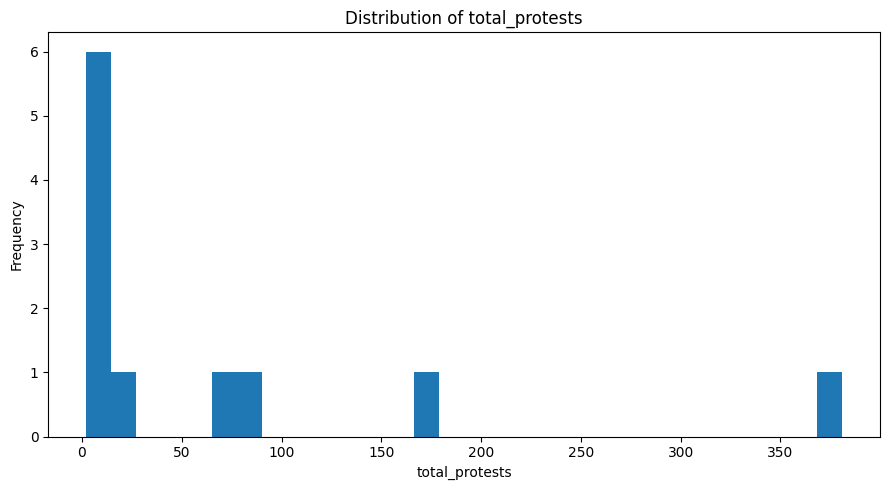

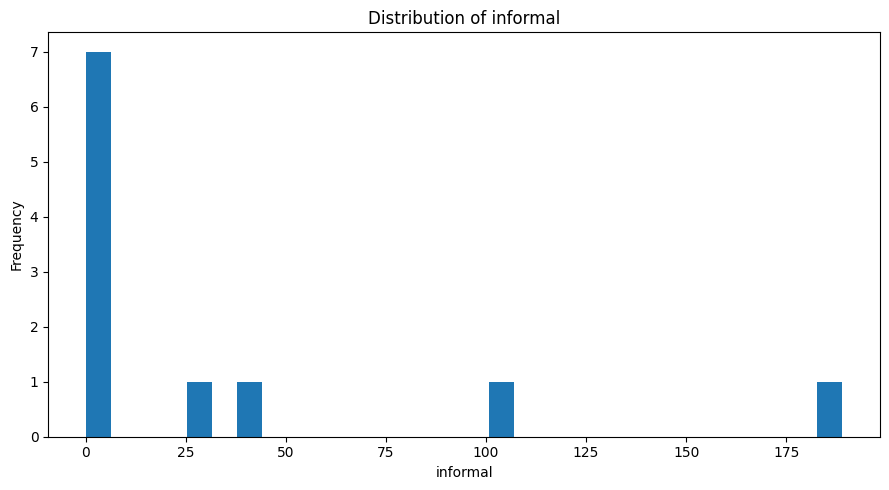

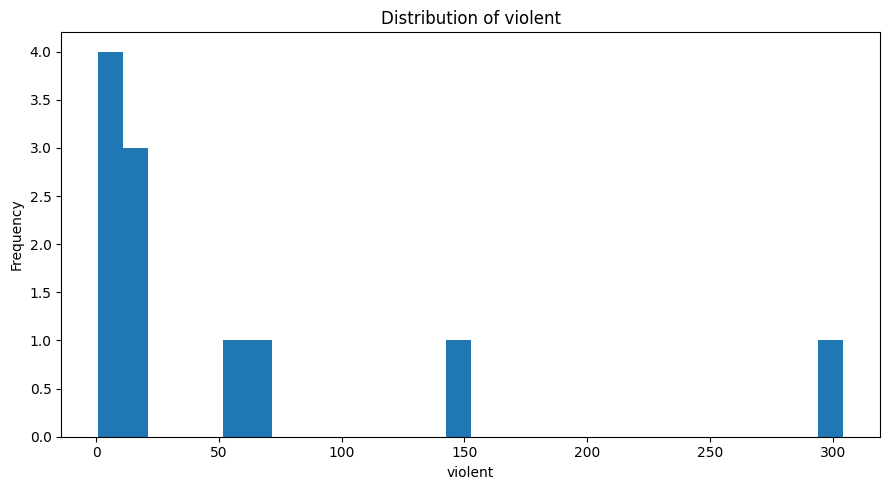

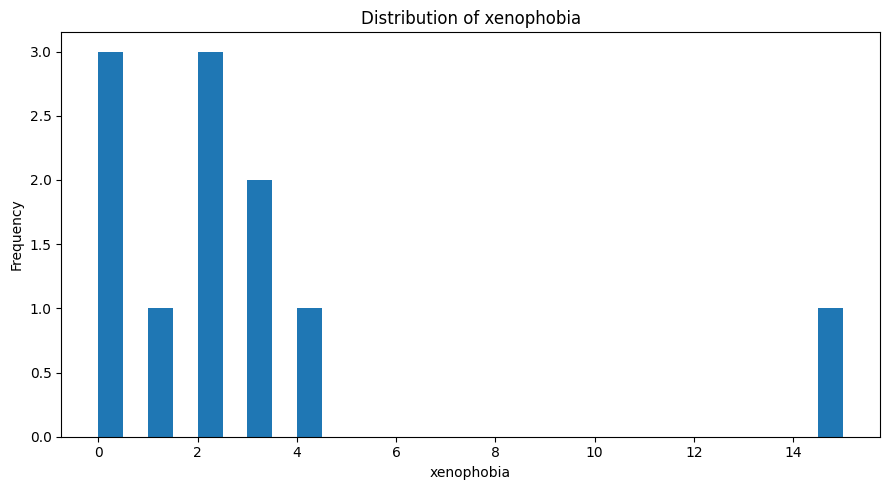

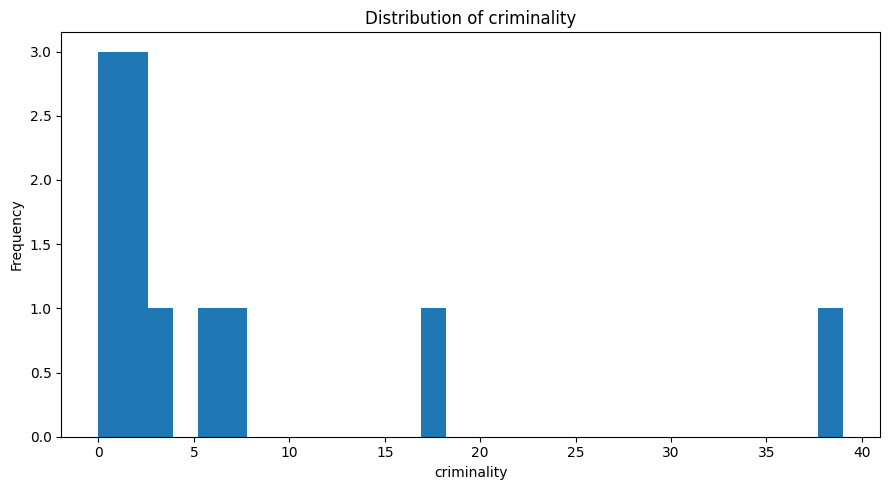

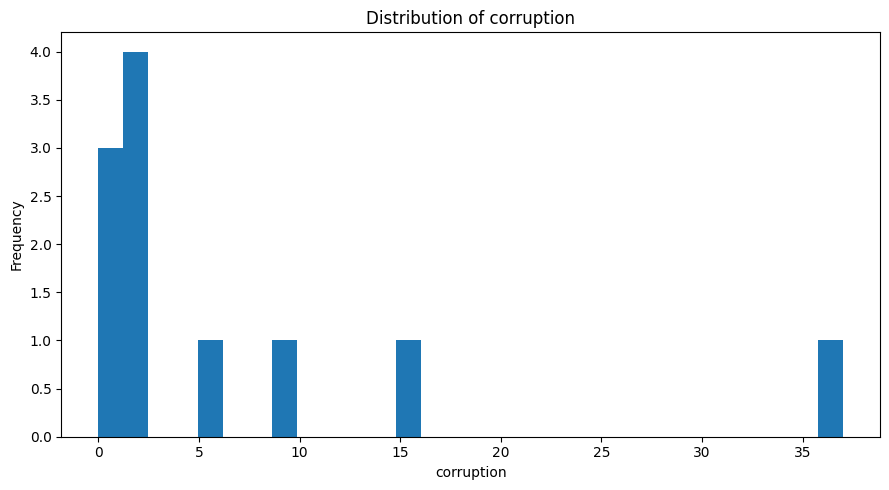

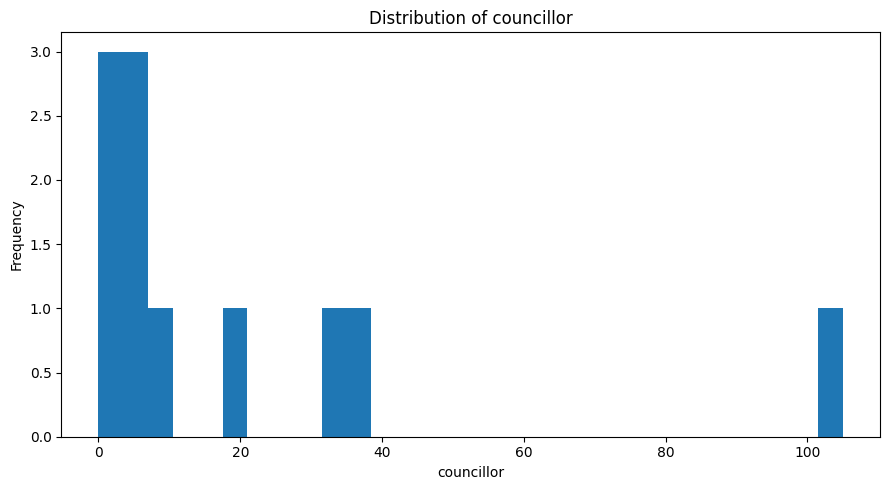

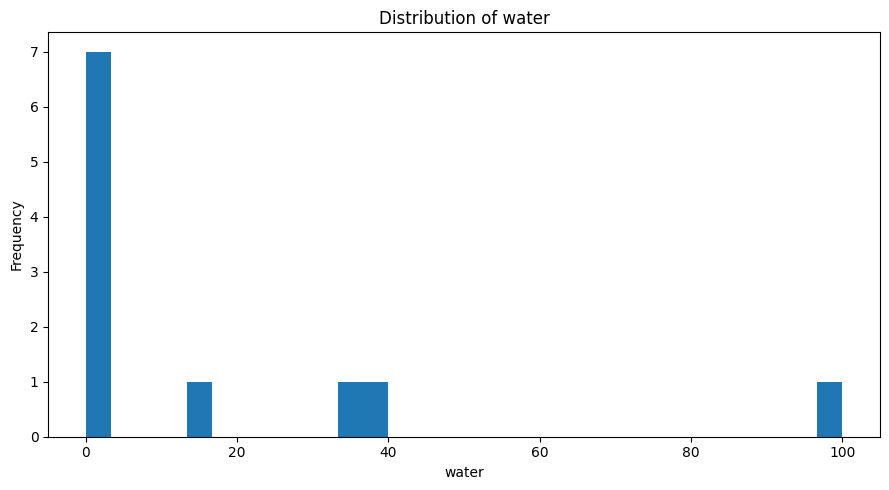

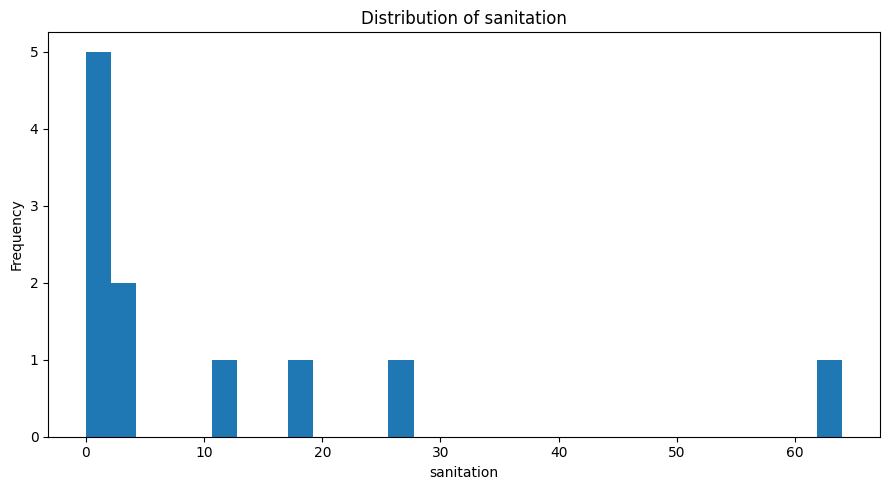

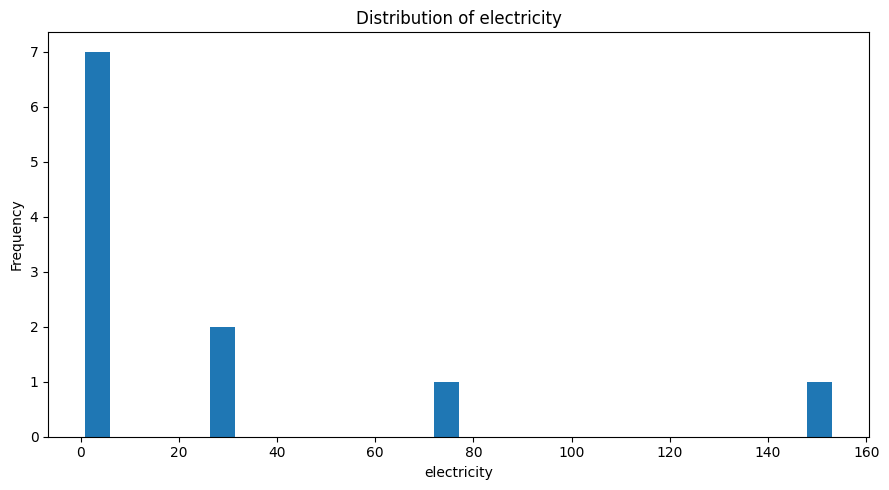

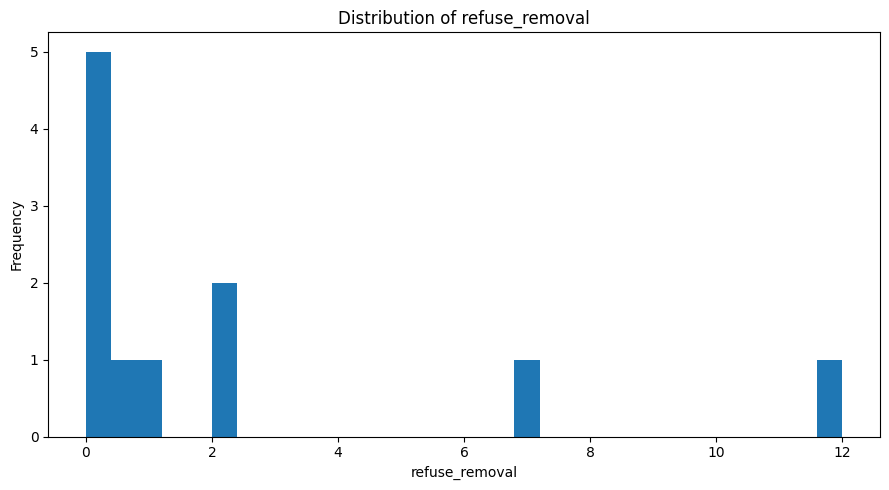

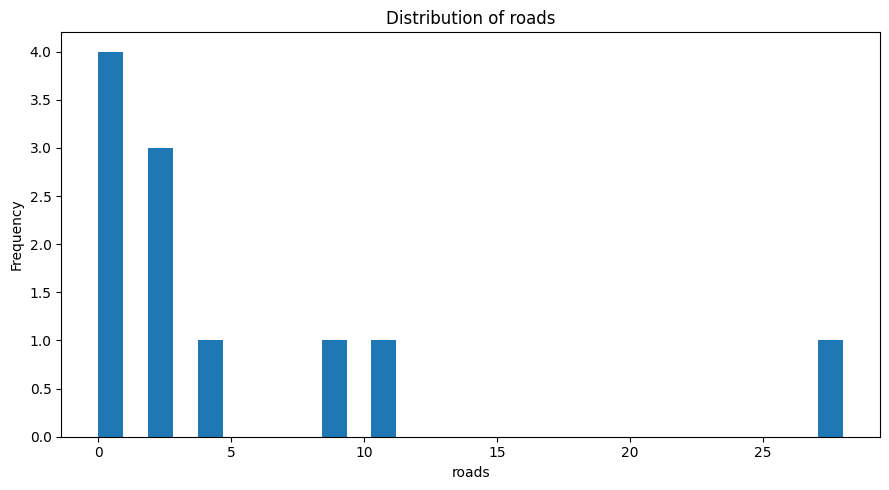

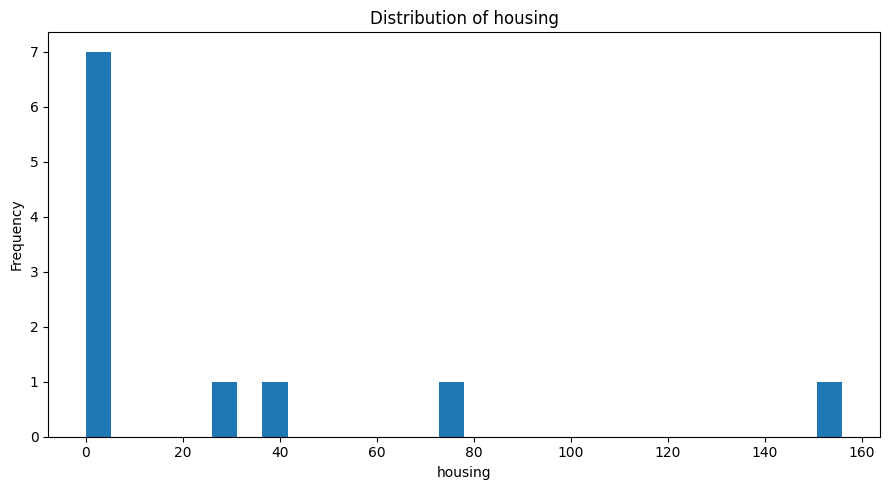

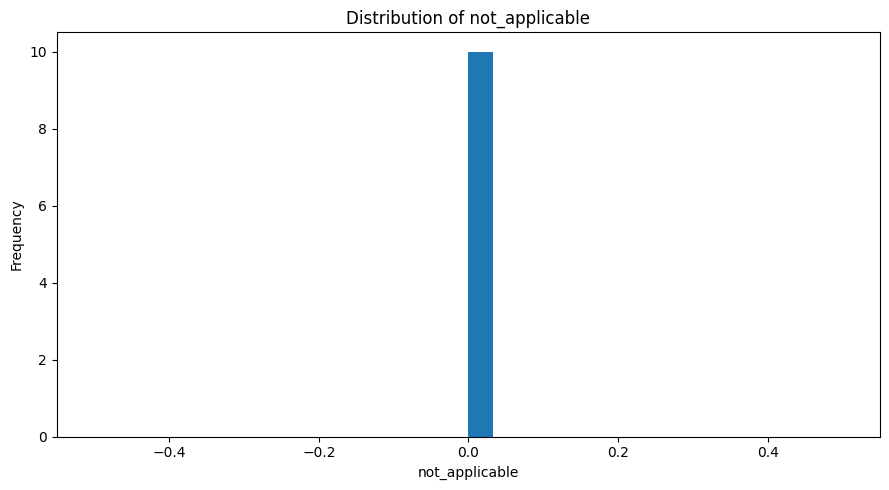

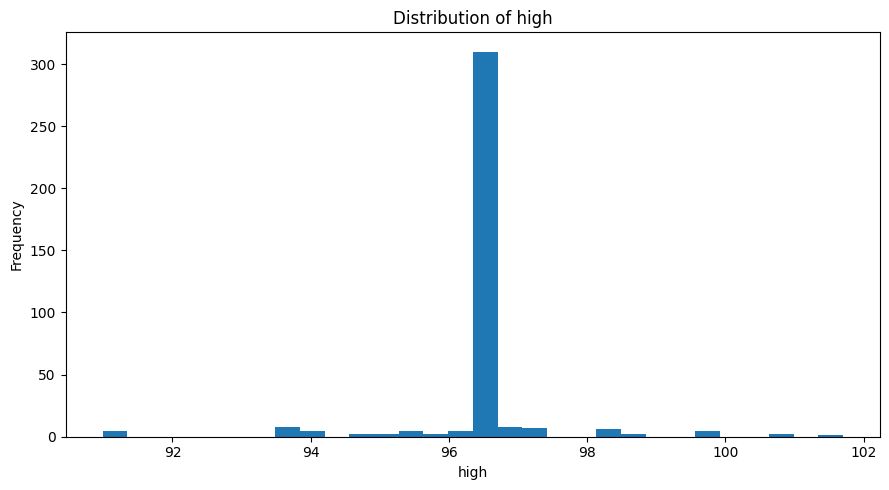

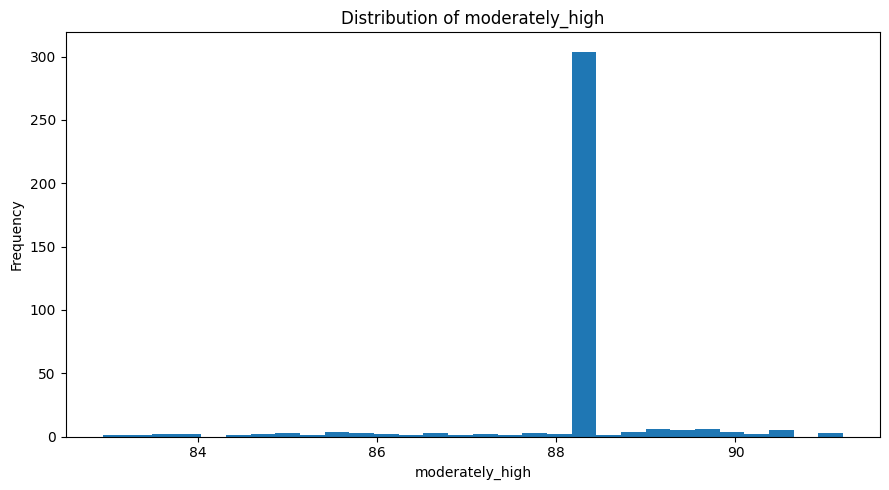

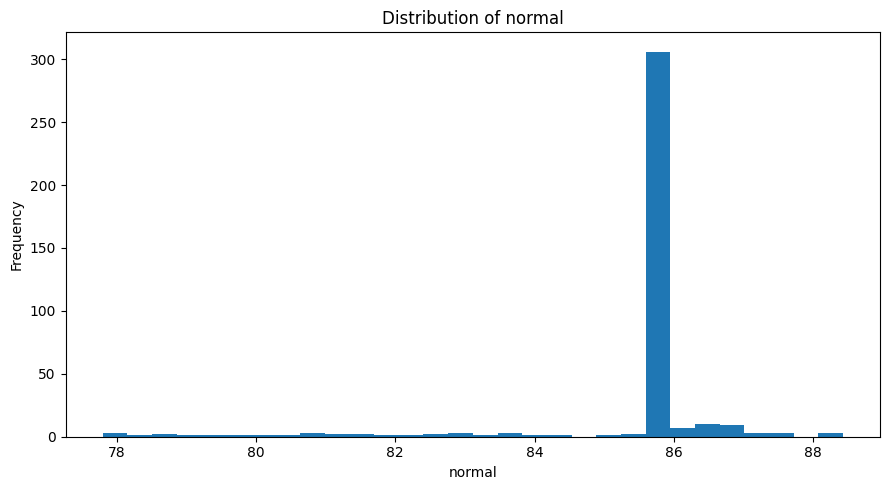

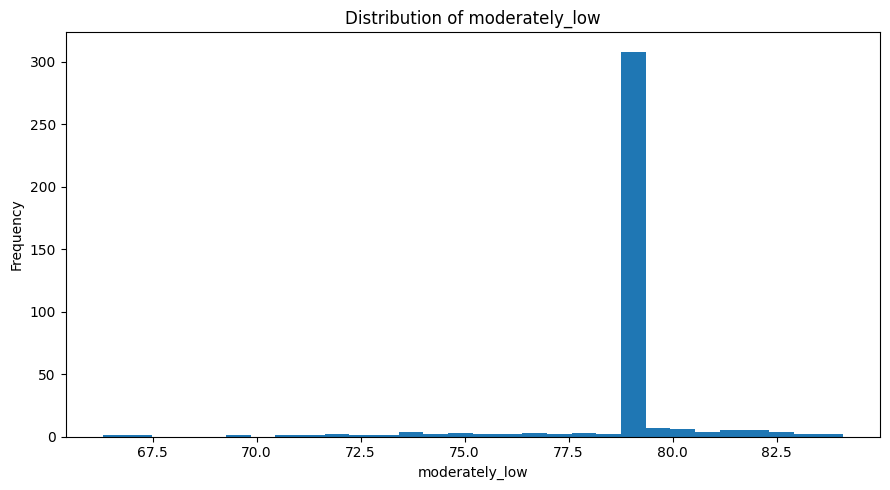

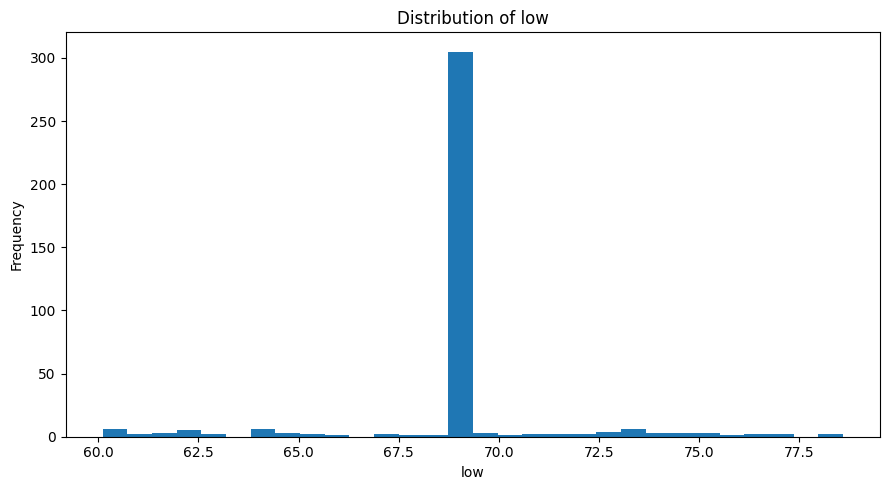

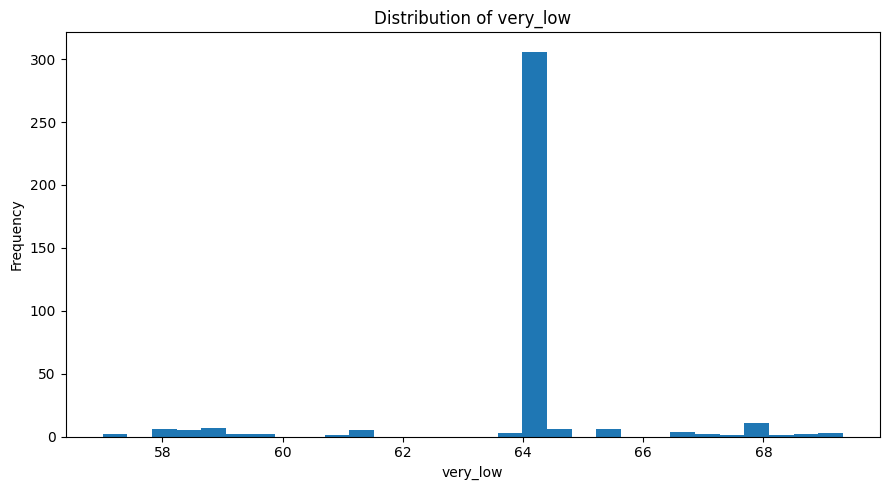

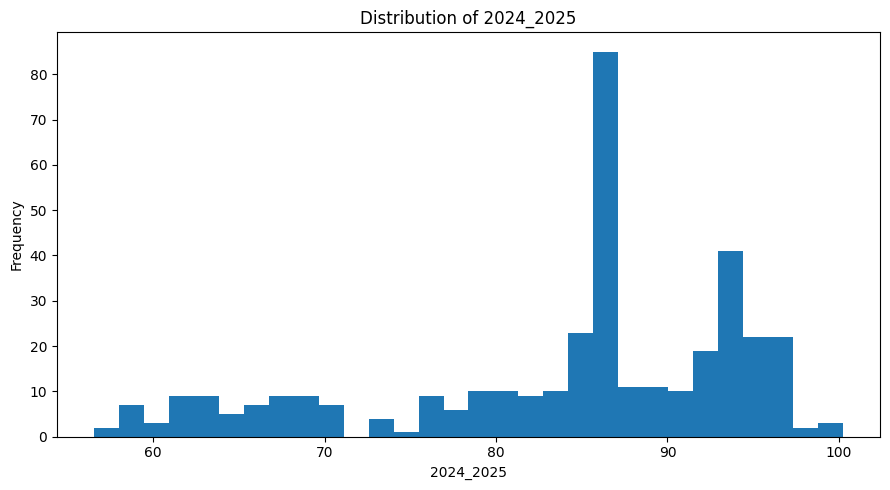

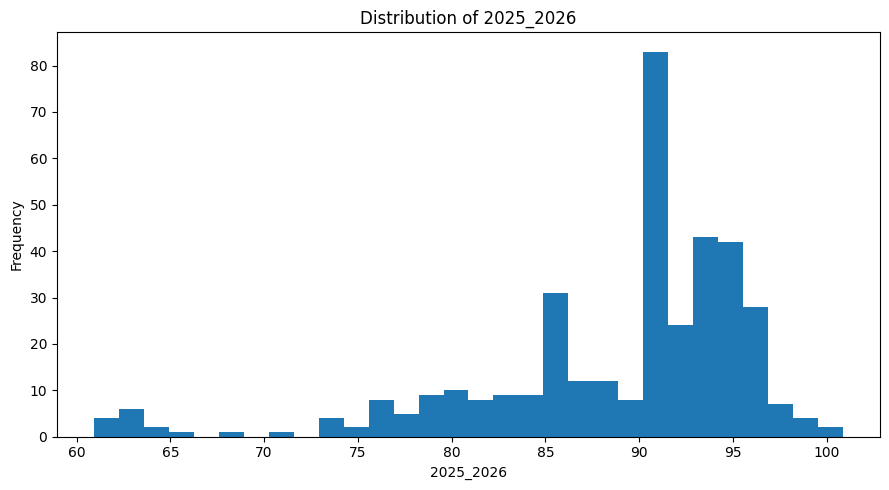

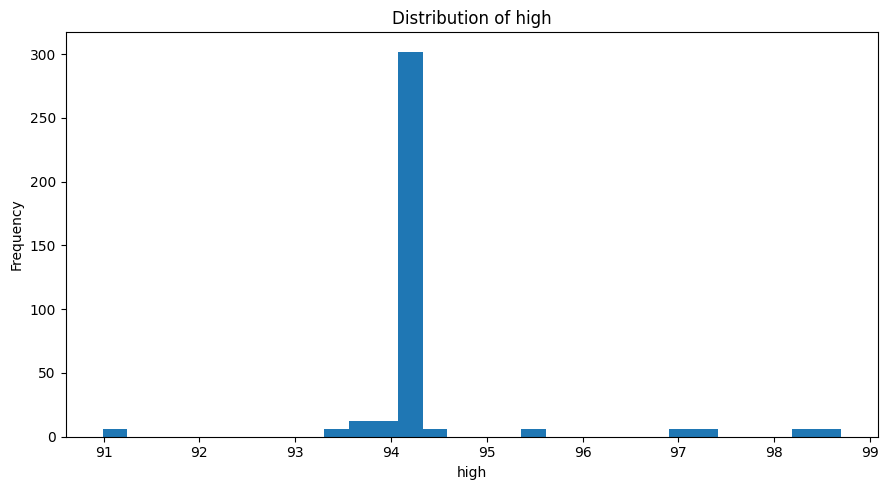

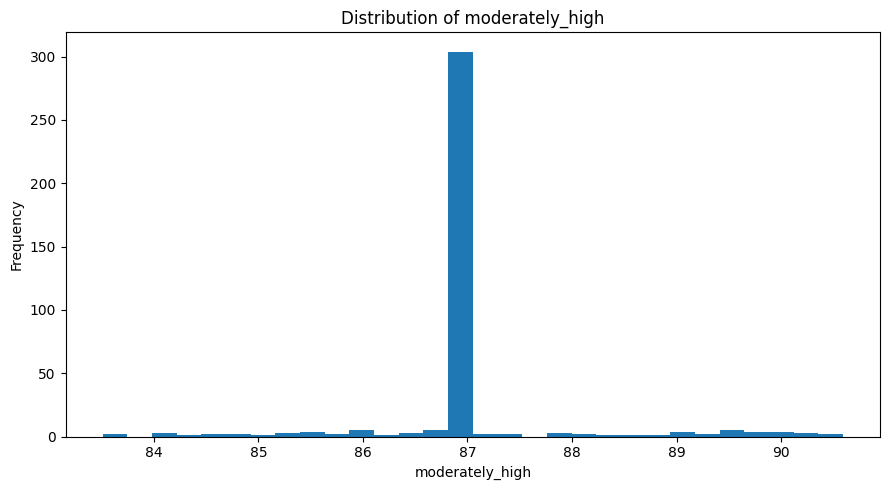

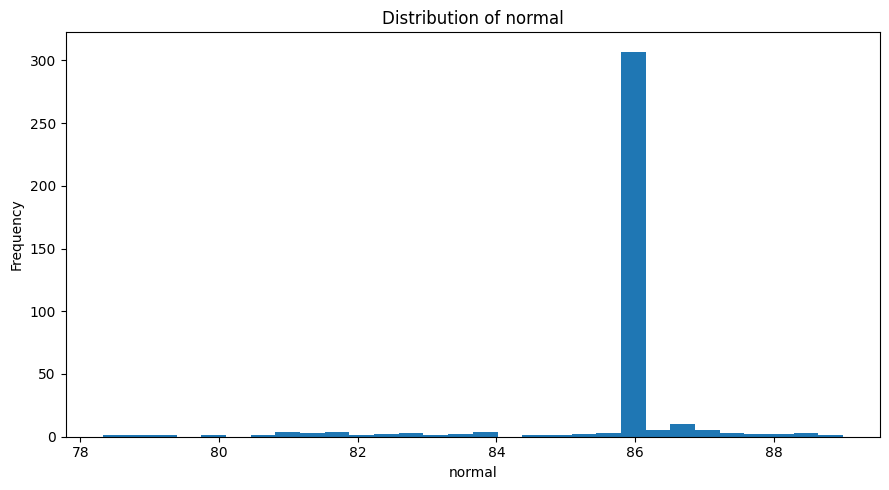

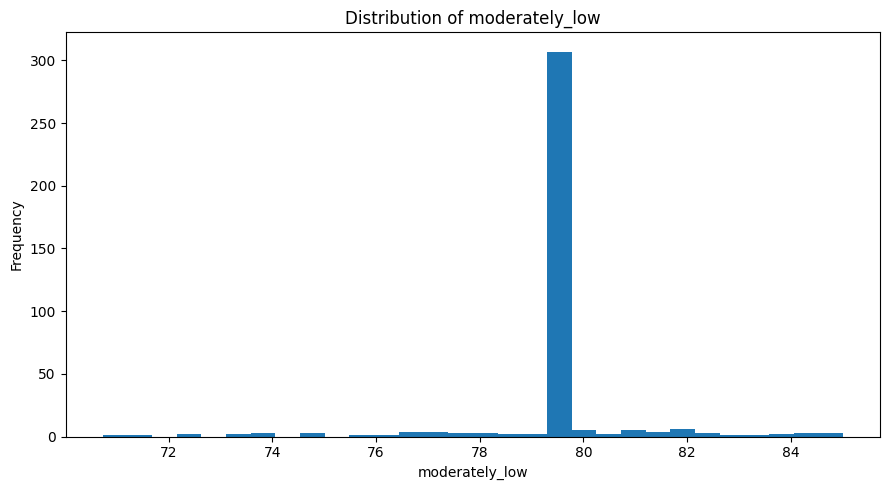

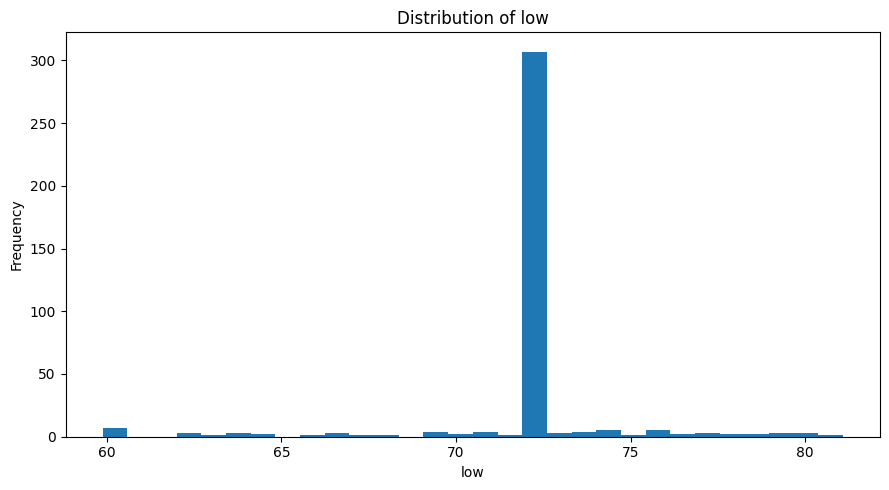

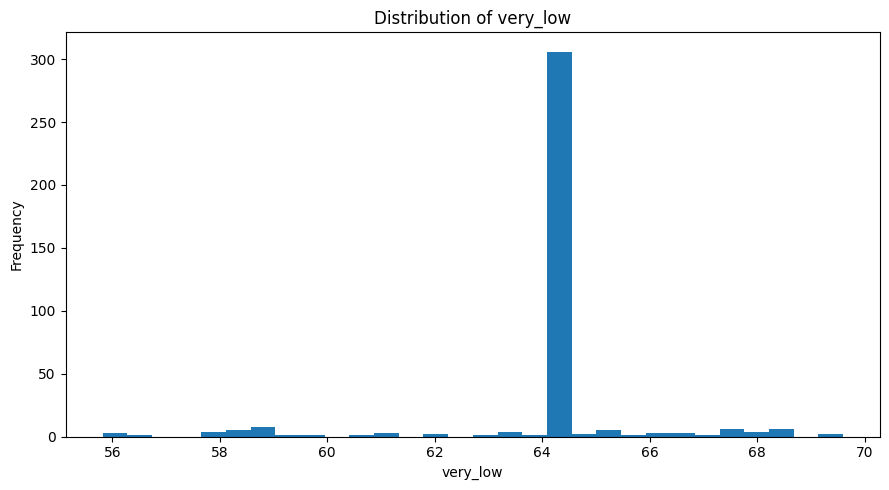

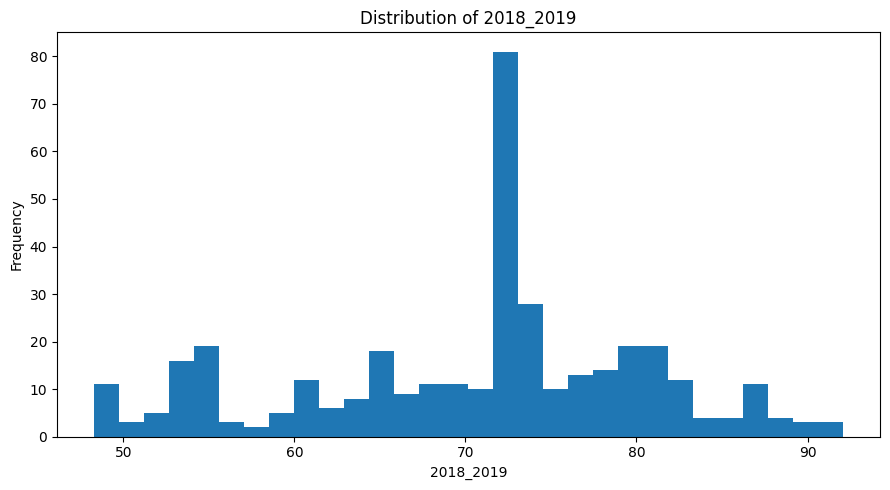

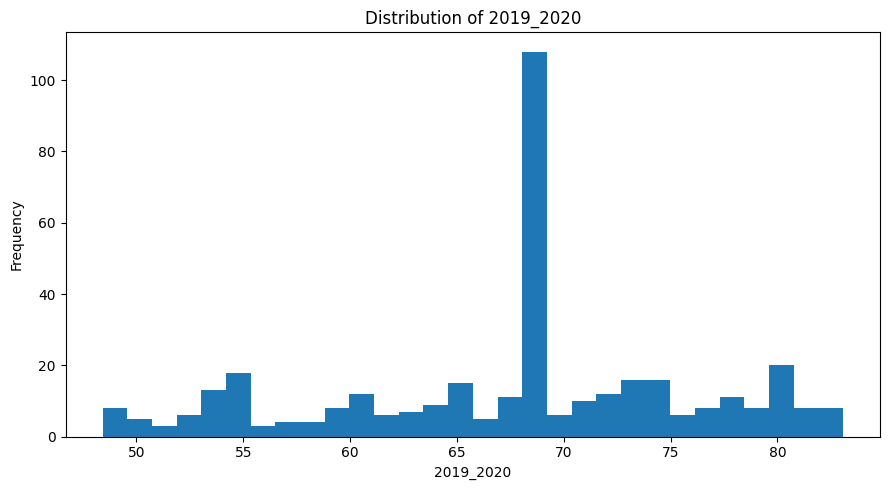

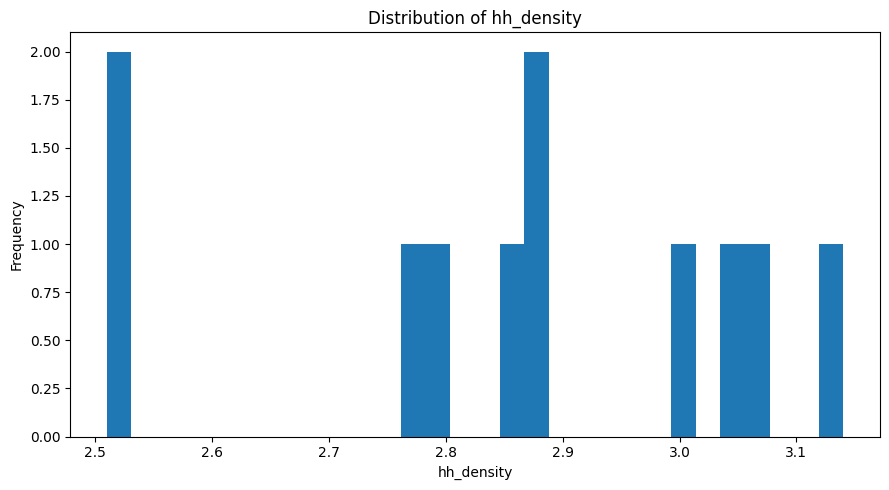

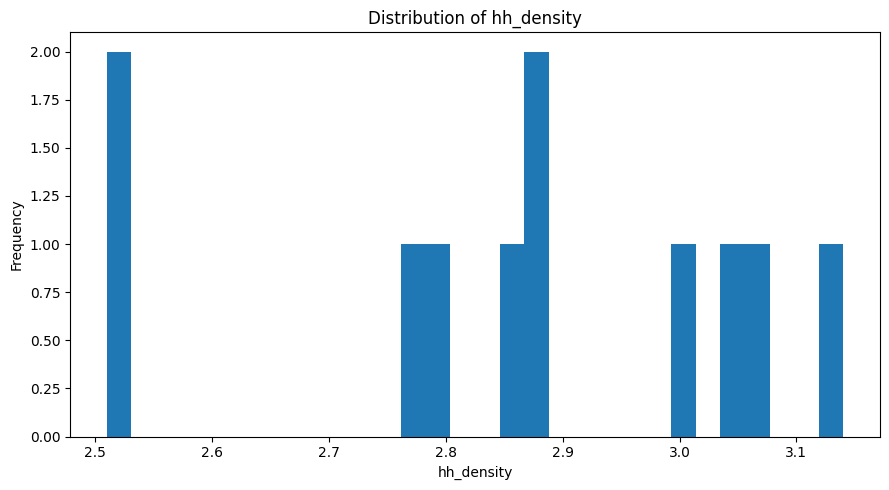

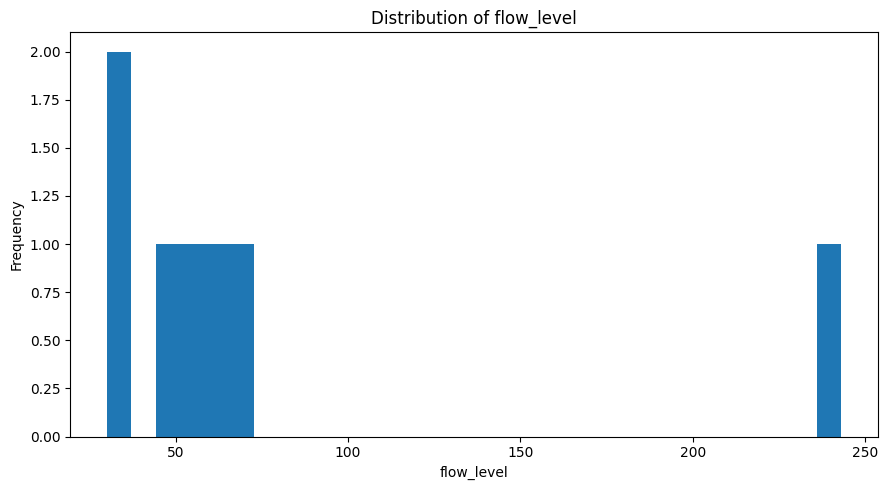

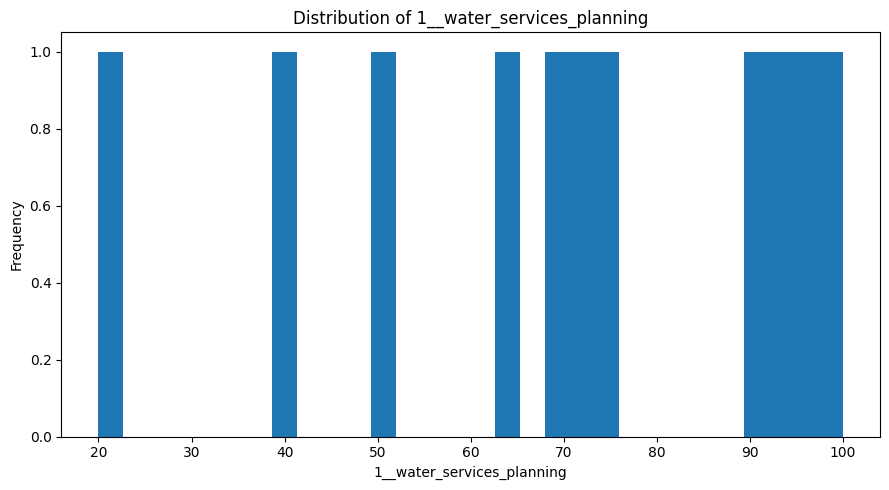

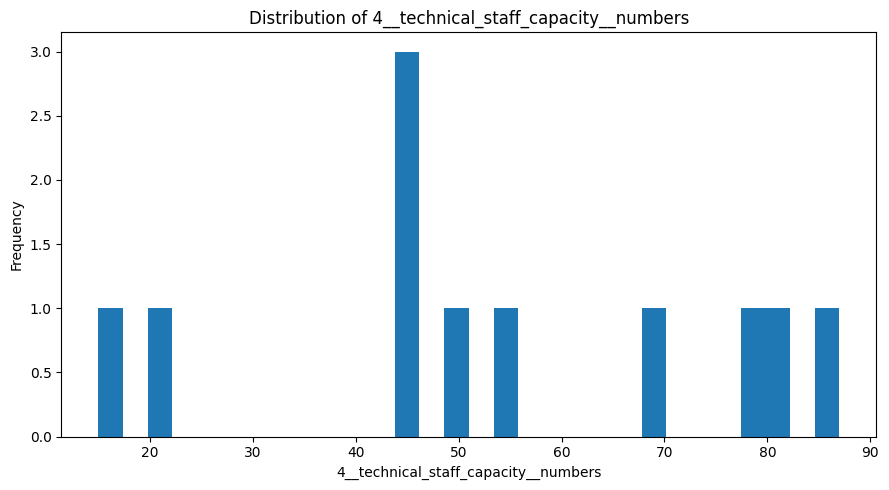

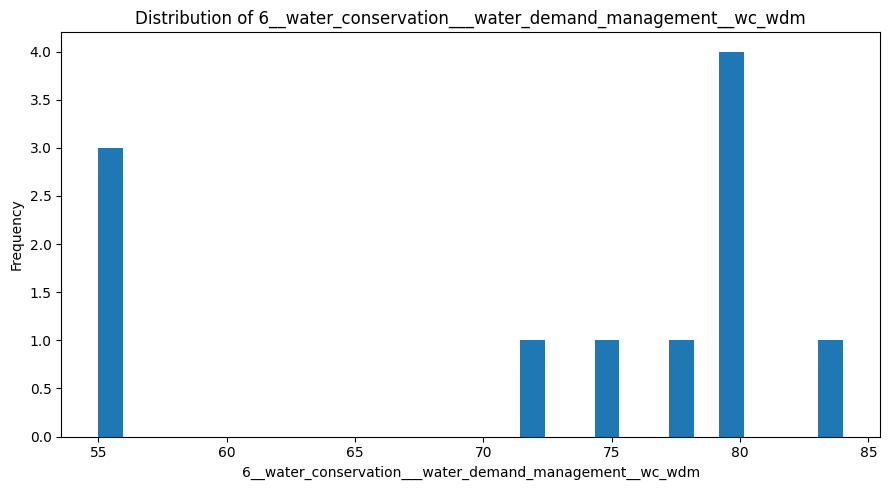

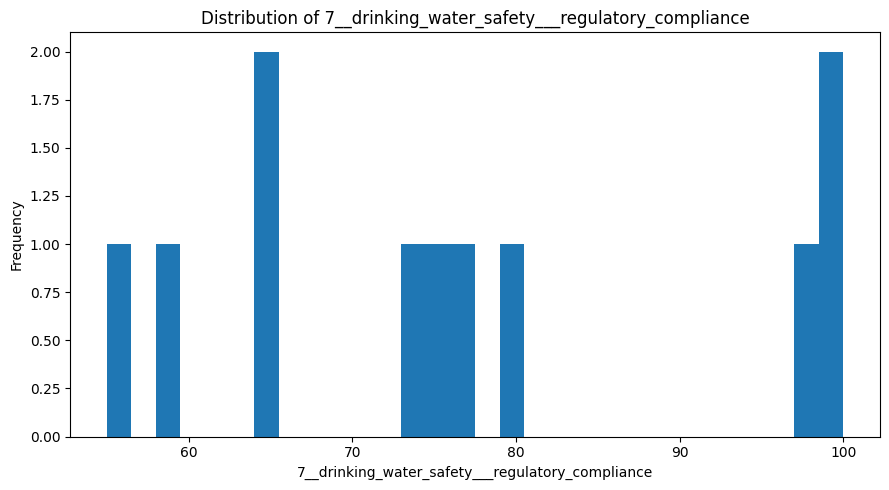

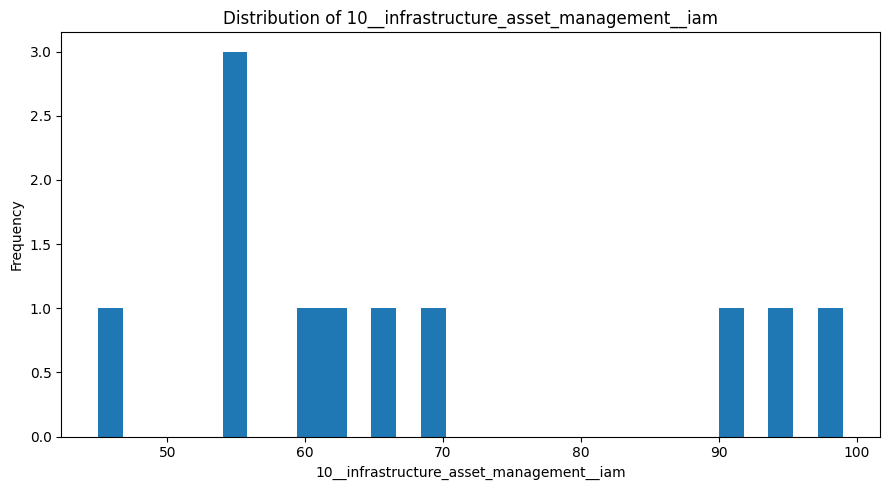

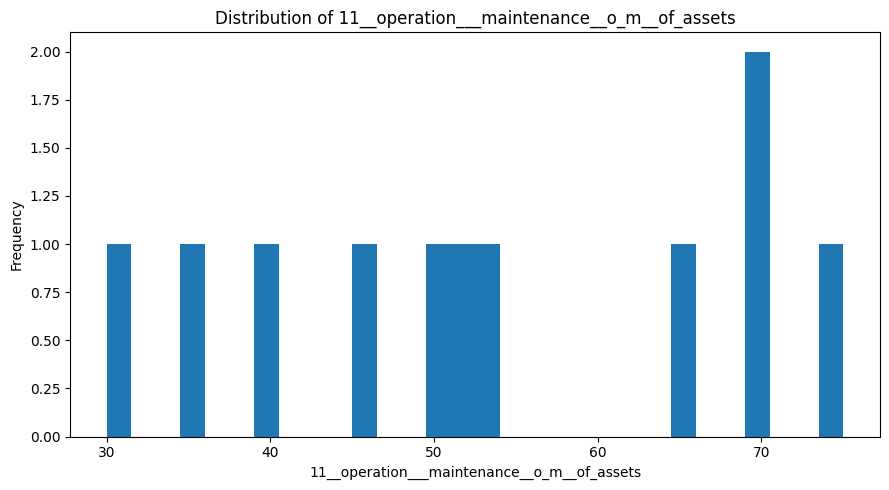

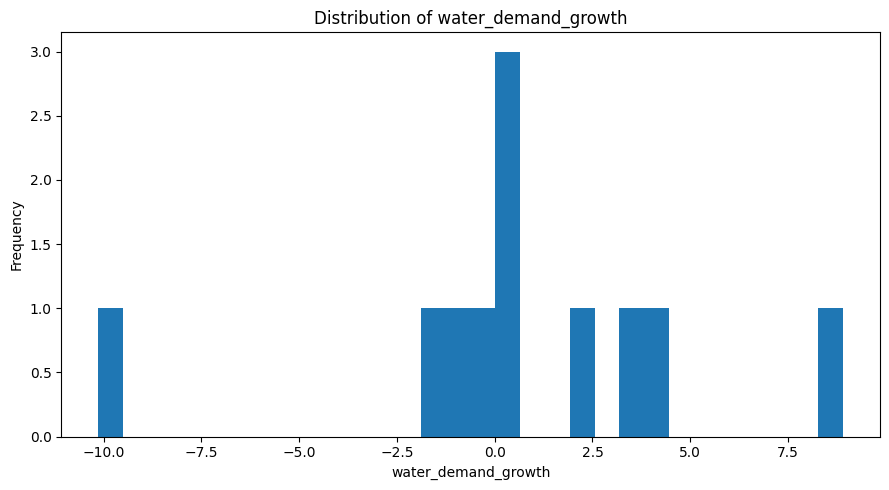

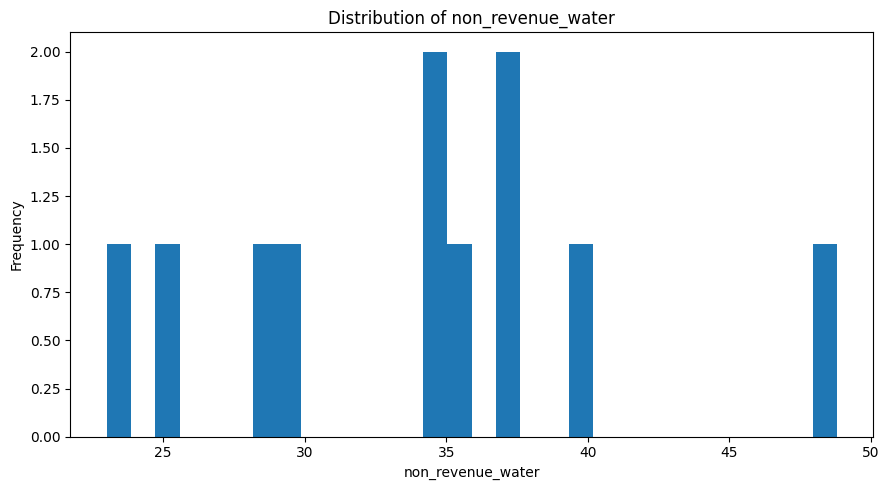

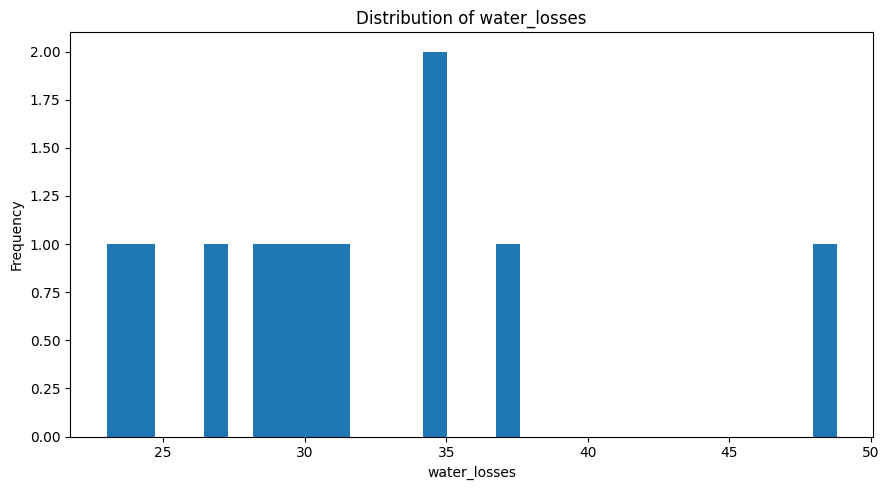

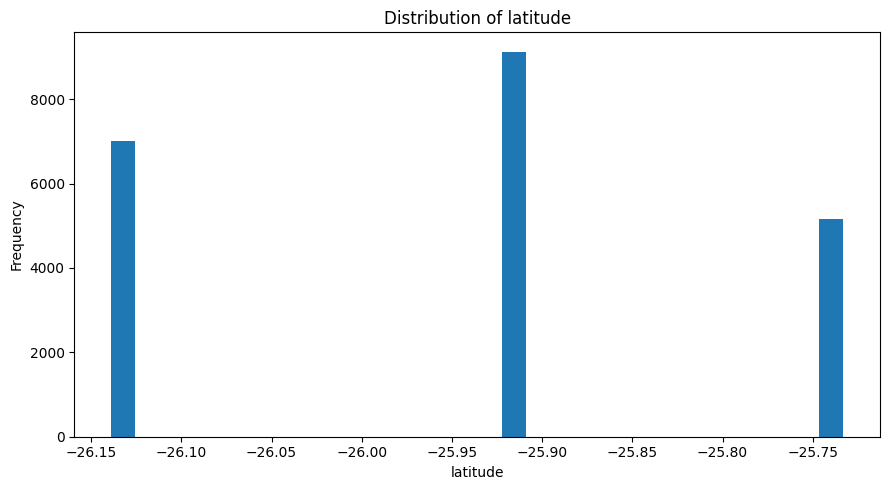

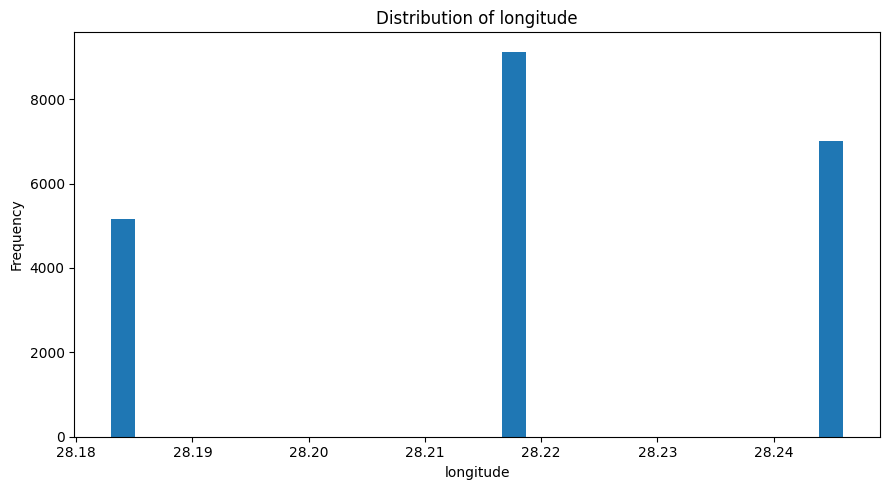

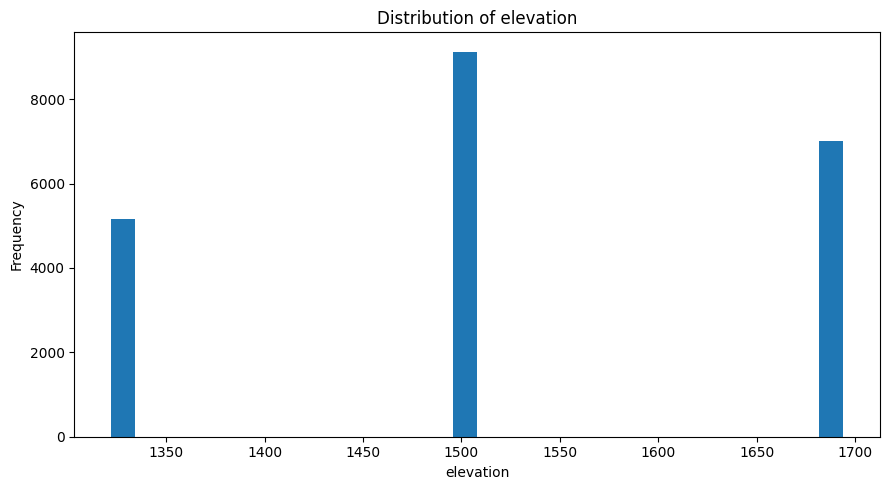

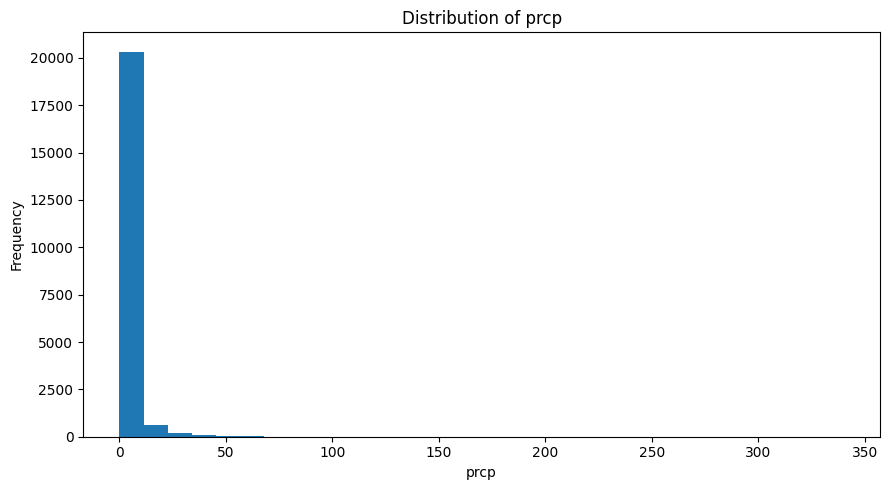

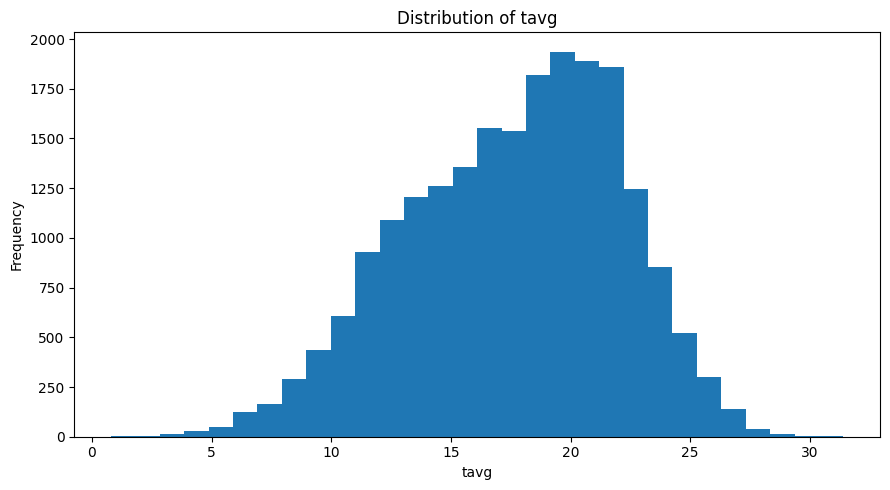

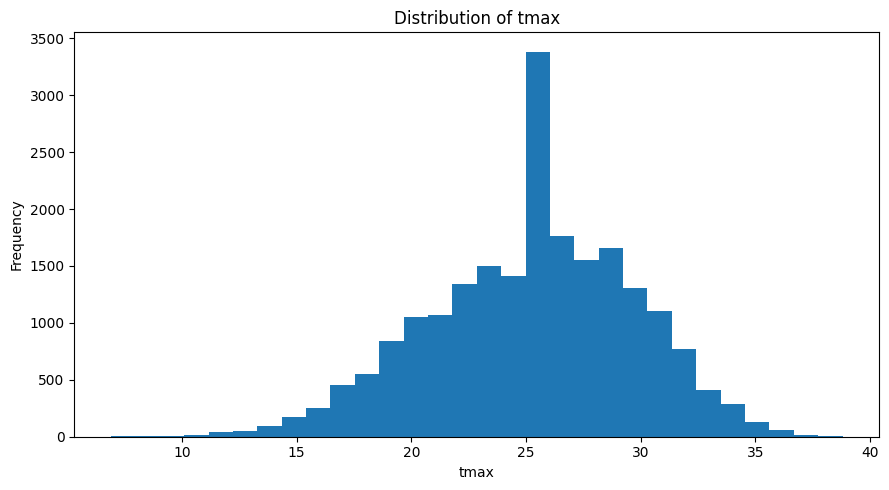

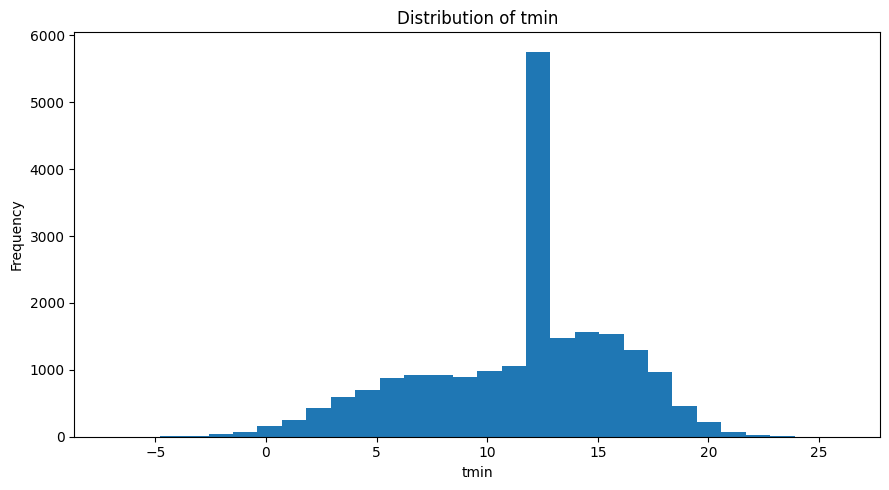

In [24]:
# ============================================================
# VISUALISATION — NUMERICAL DISTRIBUTIONS
# ============================================================

for name, df in cleaned.items():

    numeric_columns = (
        df.select_dtypes(
            include=np.number
        ).columns
    )

    for col in numeric_columns:

        series = df[col].dropna()

        if series.empty:
            continue

        plt.figure(
            figsize=(9, 5)
        )

        plt.hist(
            series,
            bins=30
        )

        plt.title(
            f"Distribution of {col}"
        )

        plt.xlabel(
            str(col)
        )

        plt.ylabel(
            "Frequency"
        )

        plt.tight_layout()

        safe_name = (
            str(col)
            .replace("/", "_")
            .replace("\\", "_")
            .replace(" ", "_")
        )

        output_path = os.path.join(
            VISUALISATION_DIR,
            f"{name}_{safe_name}_distribution.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()

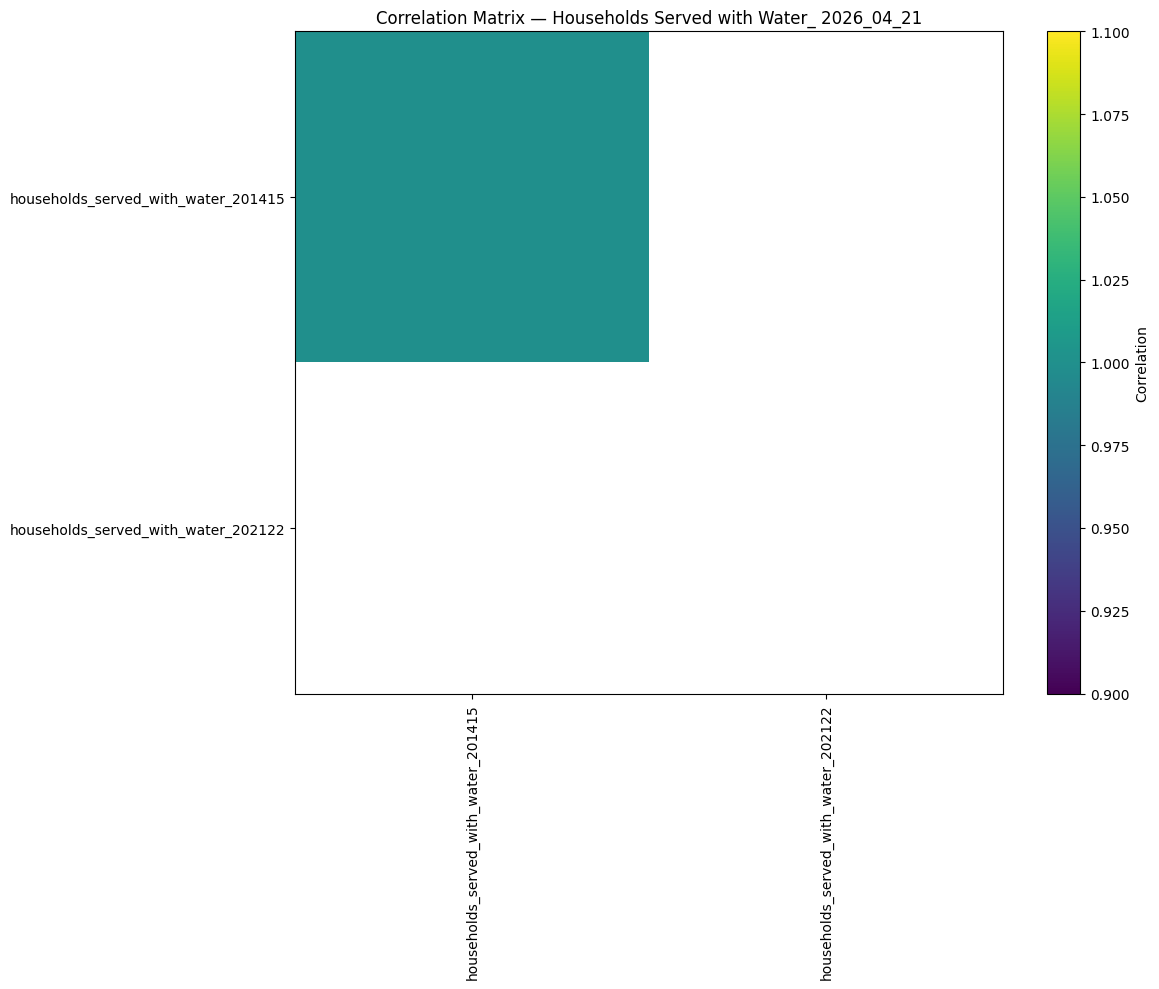

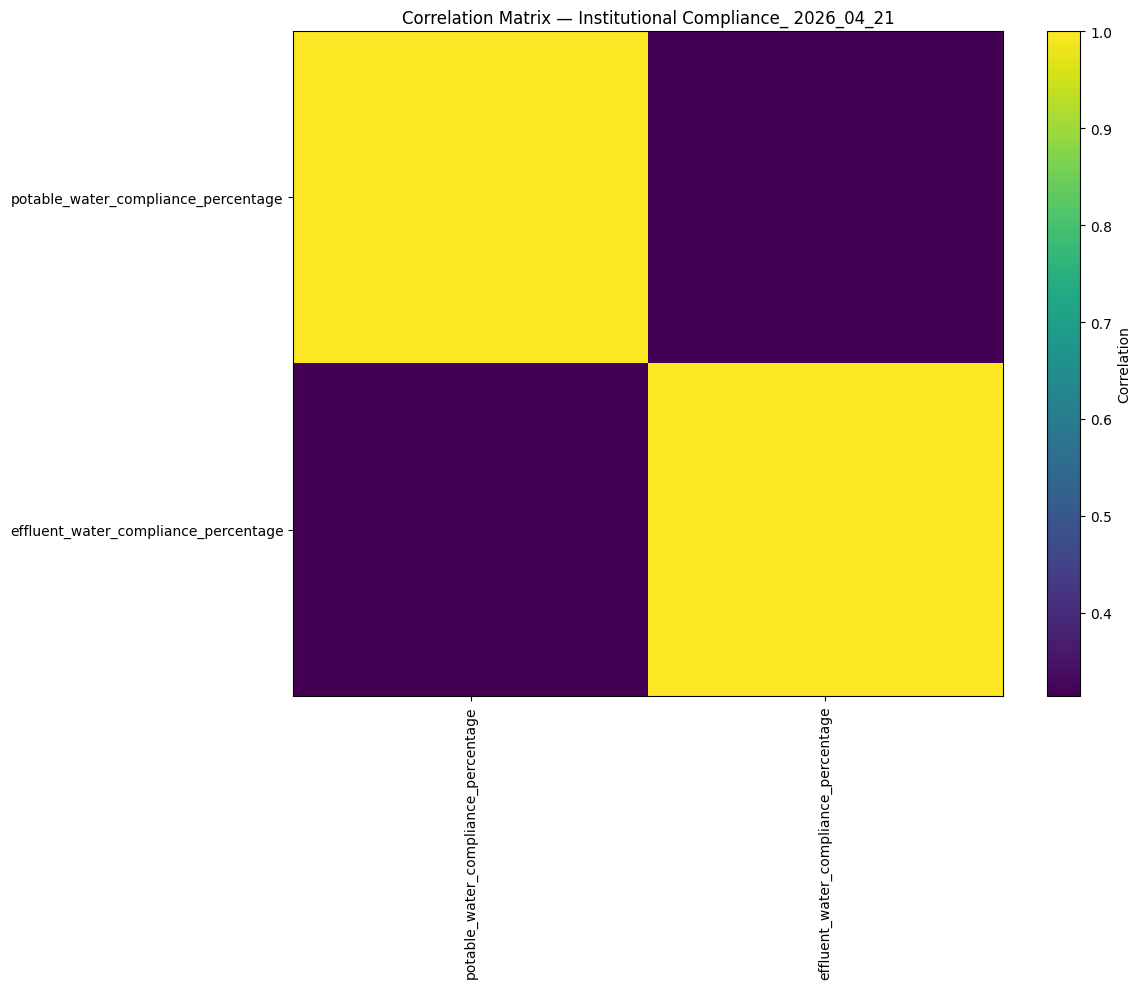

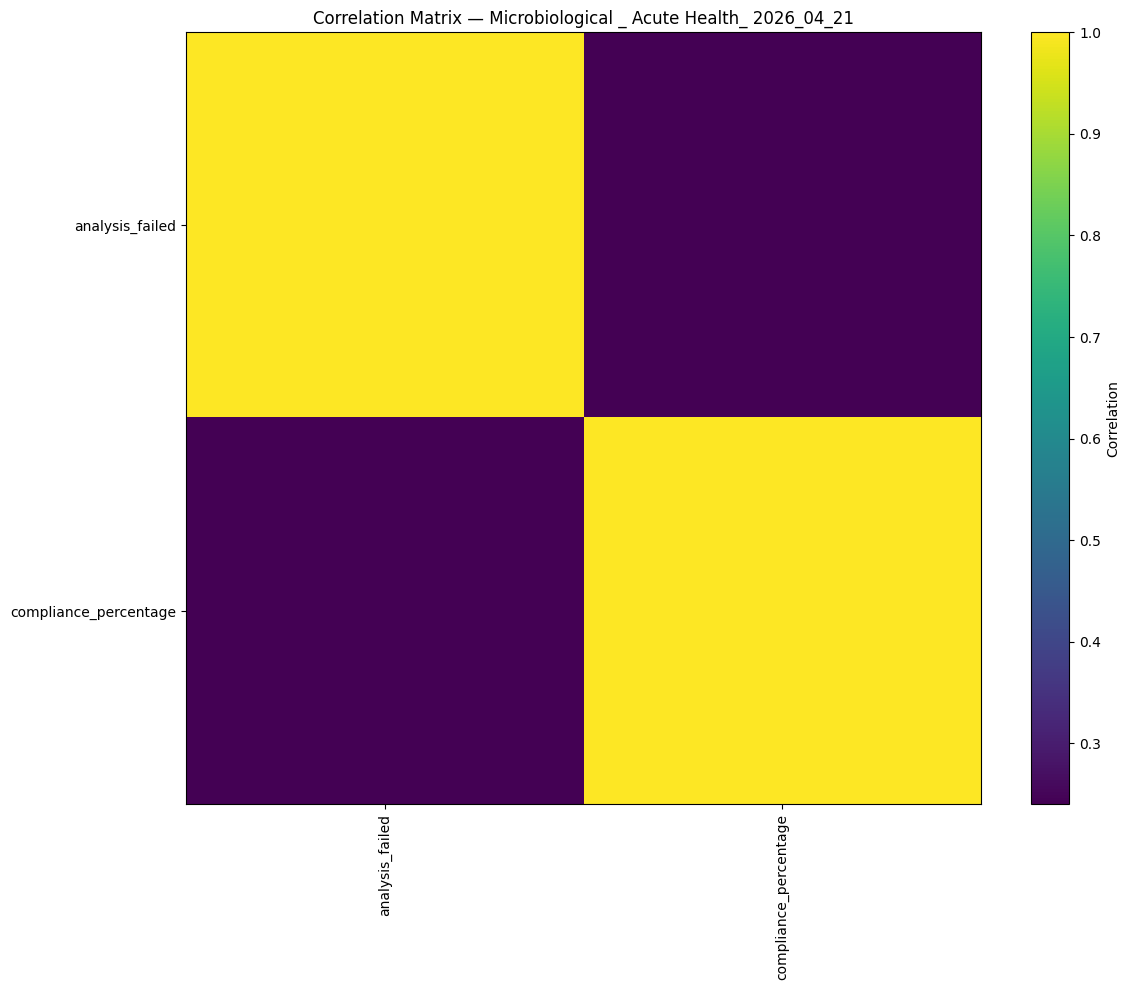

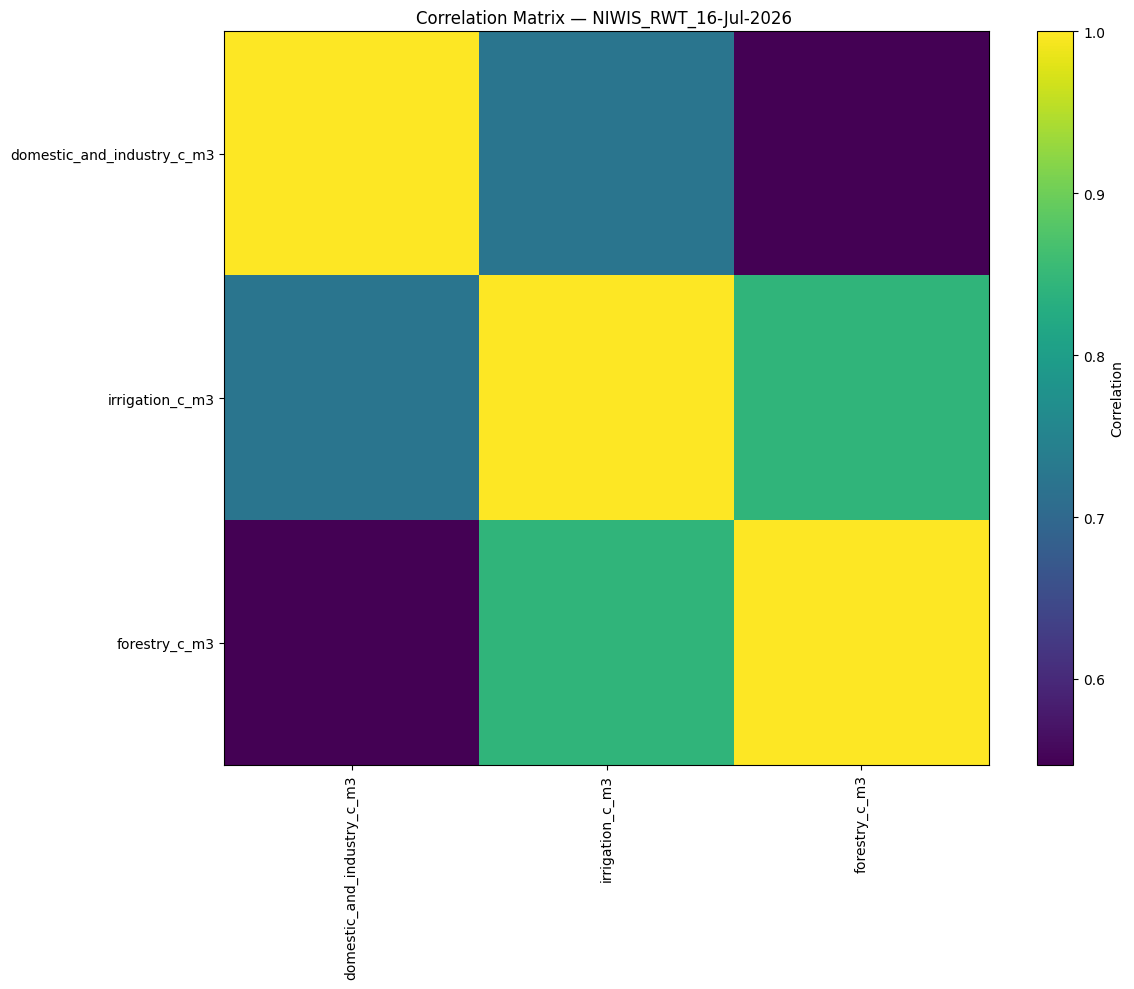

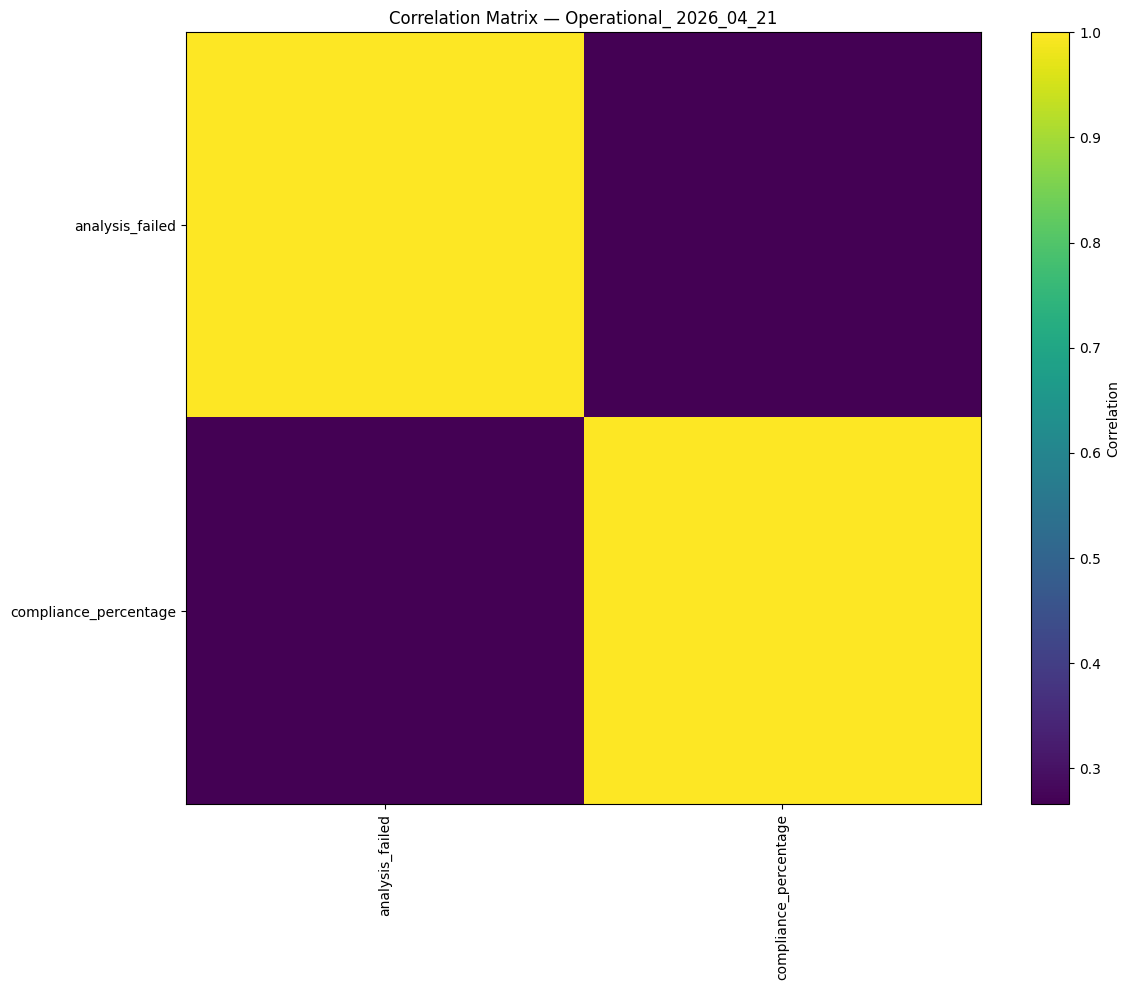

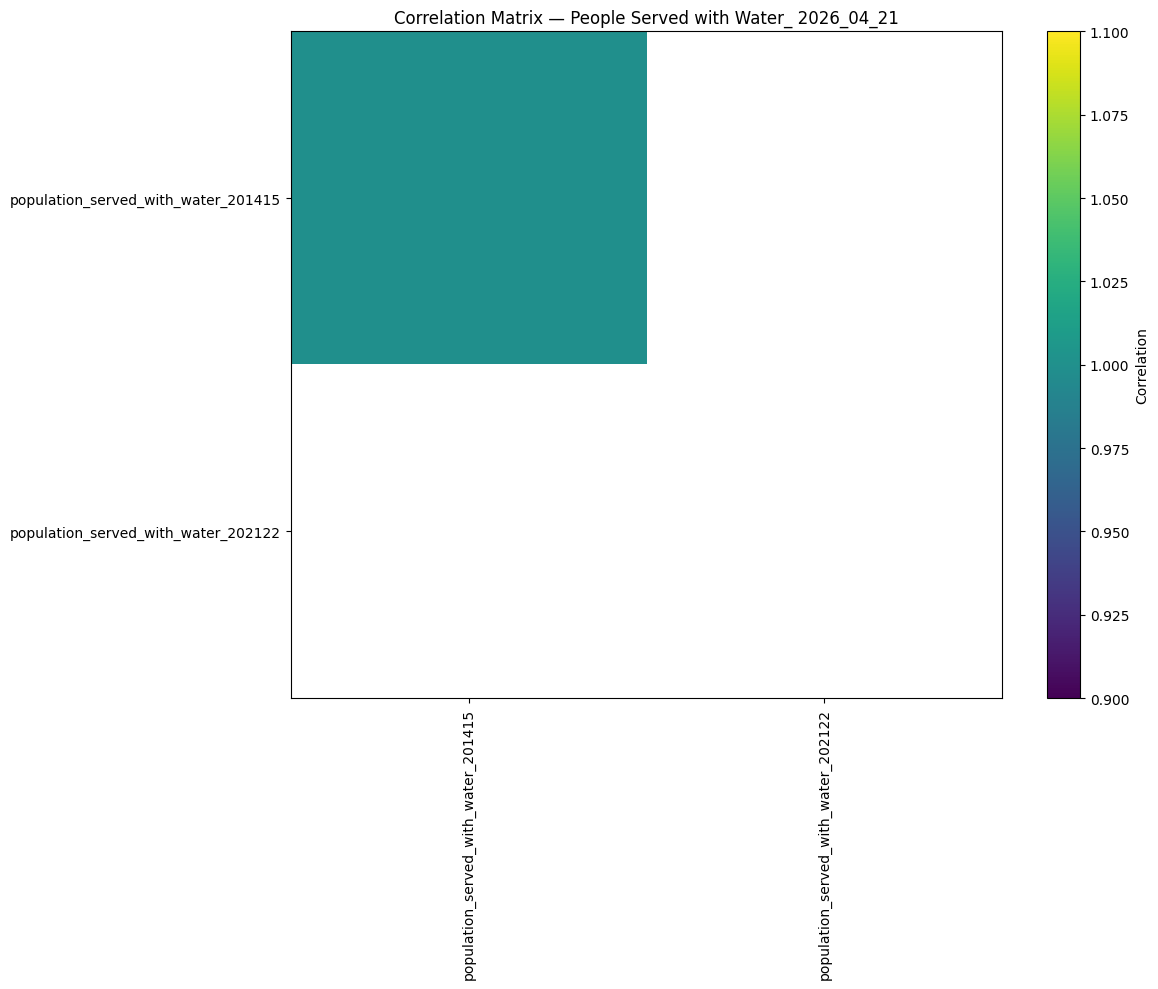

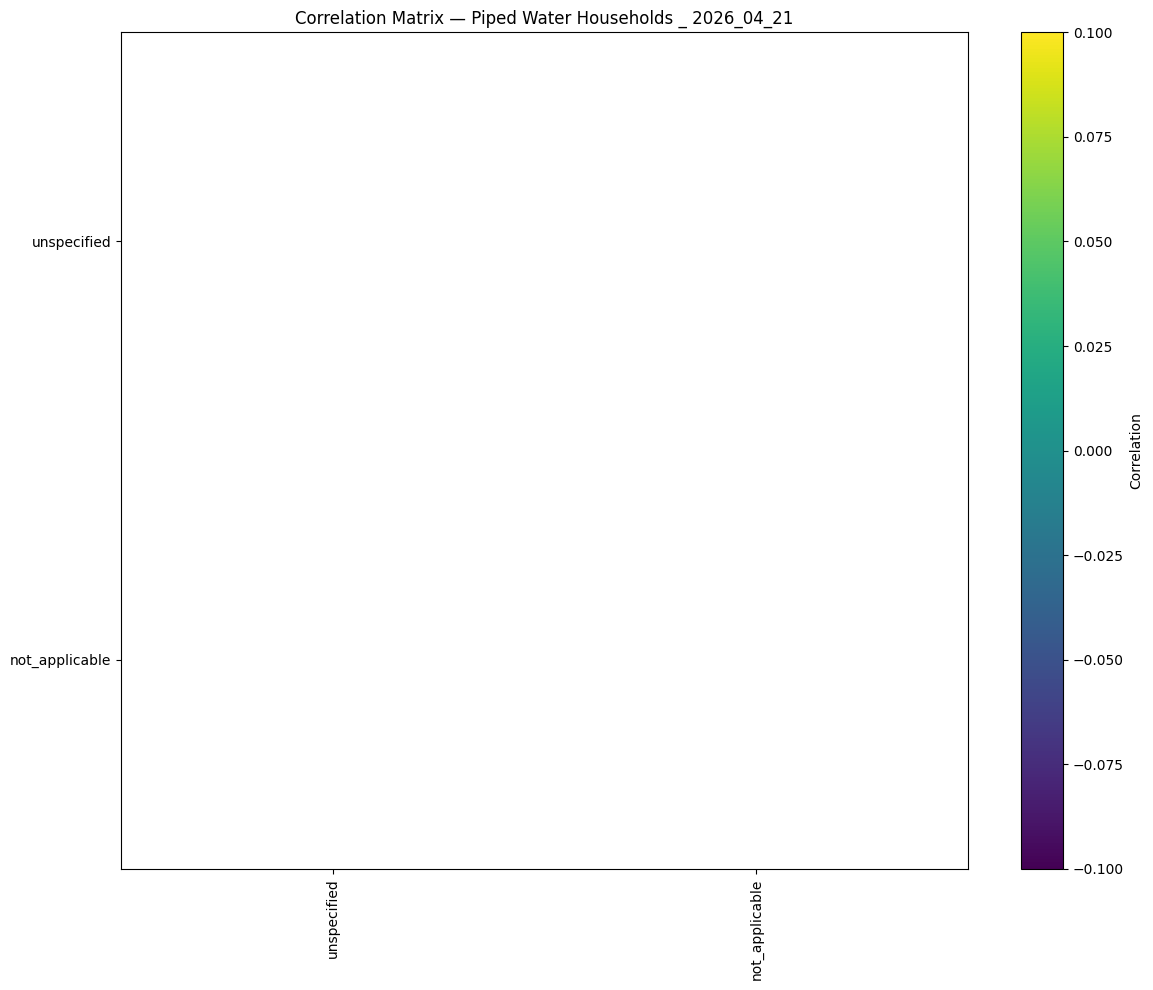

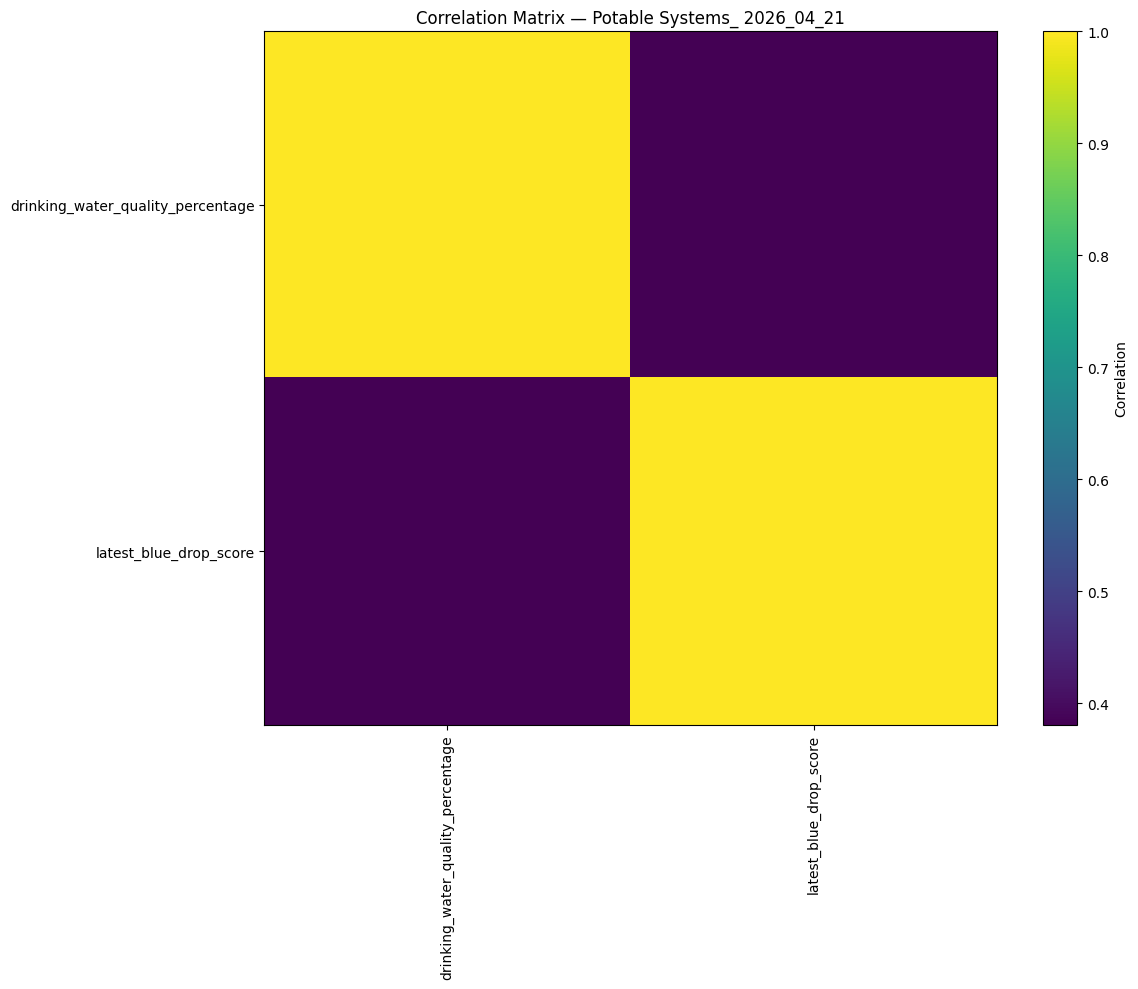

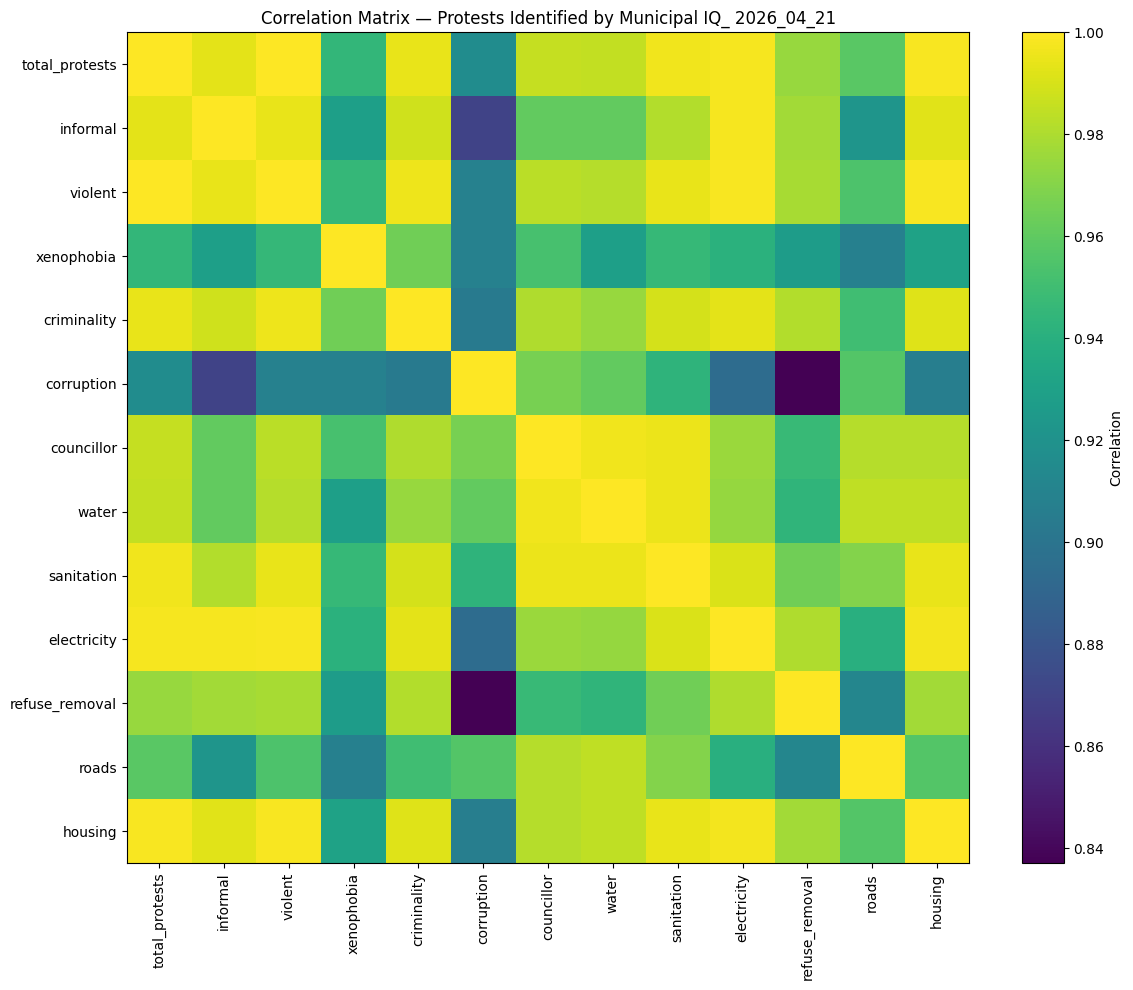

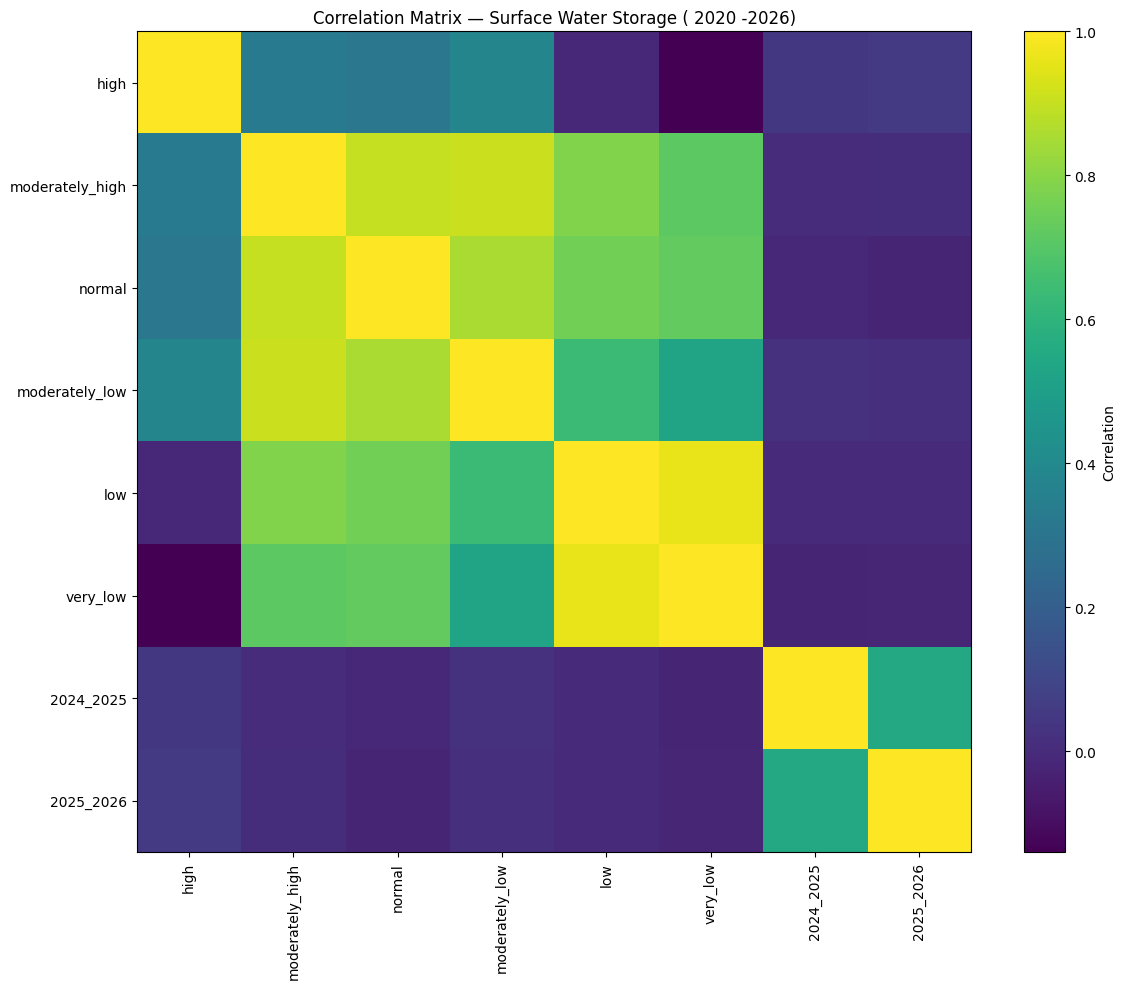

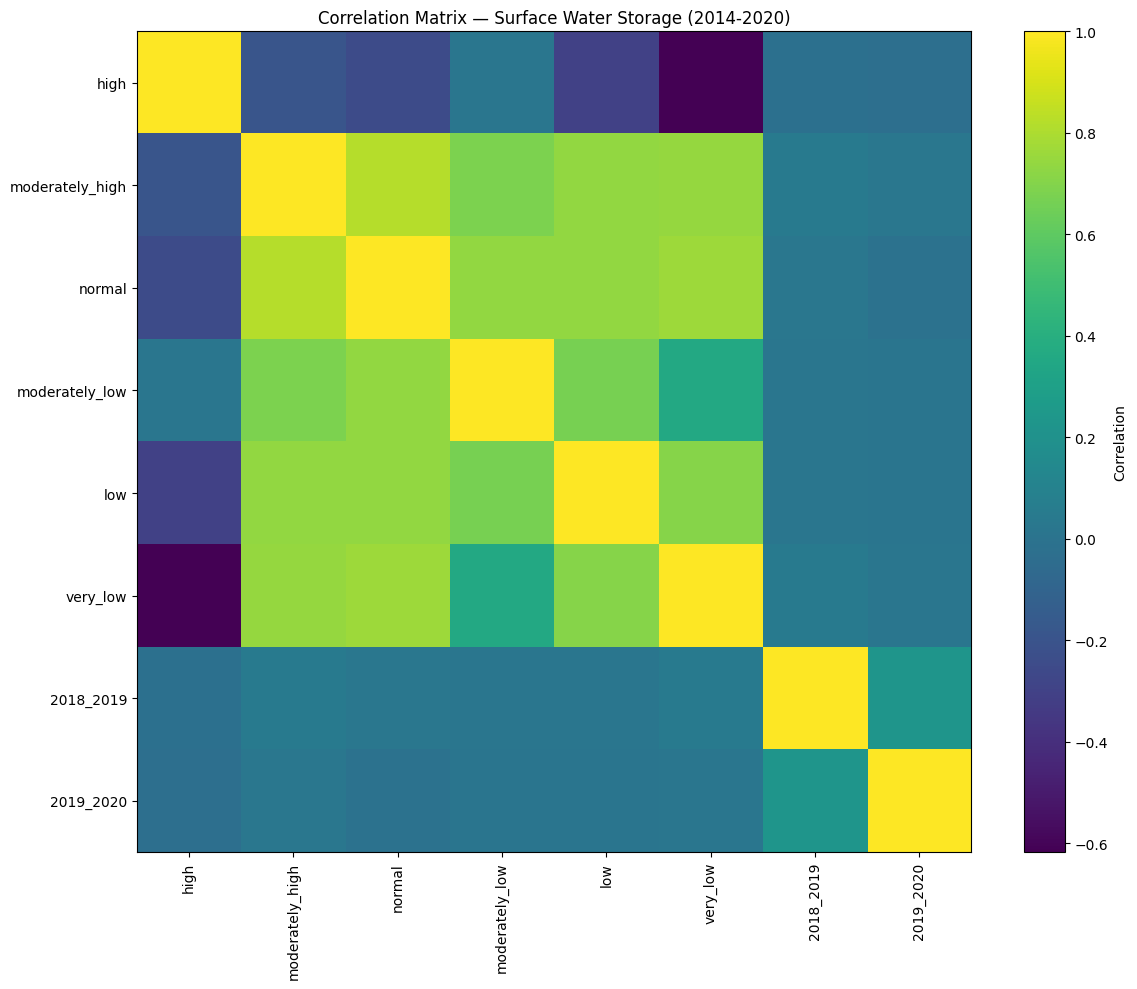

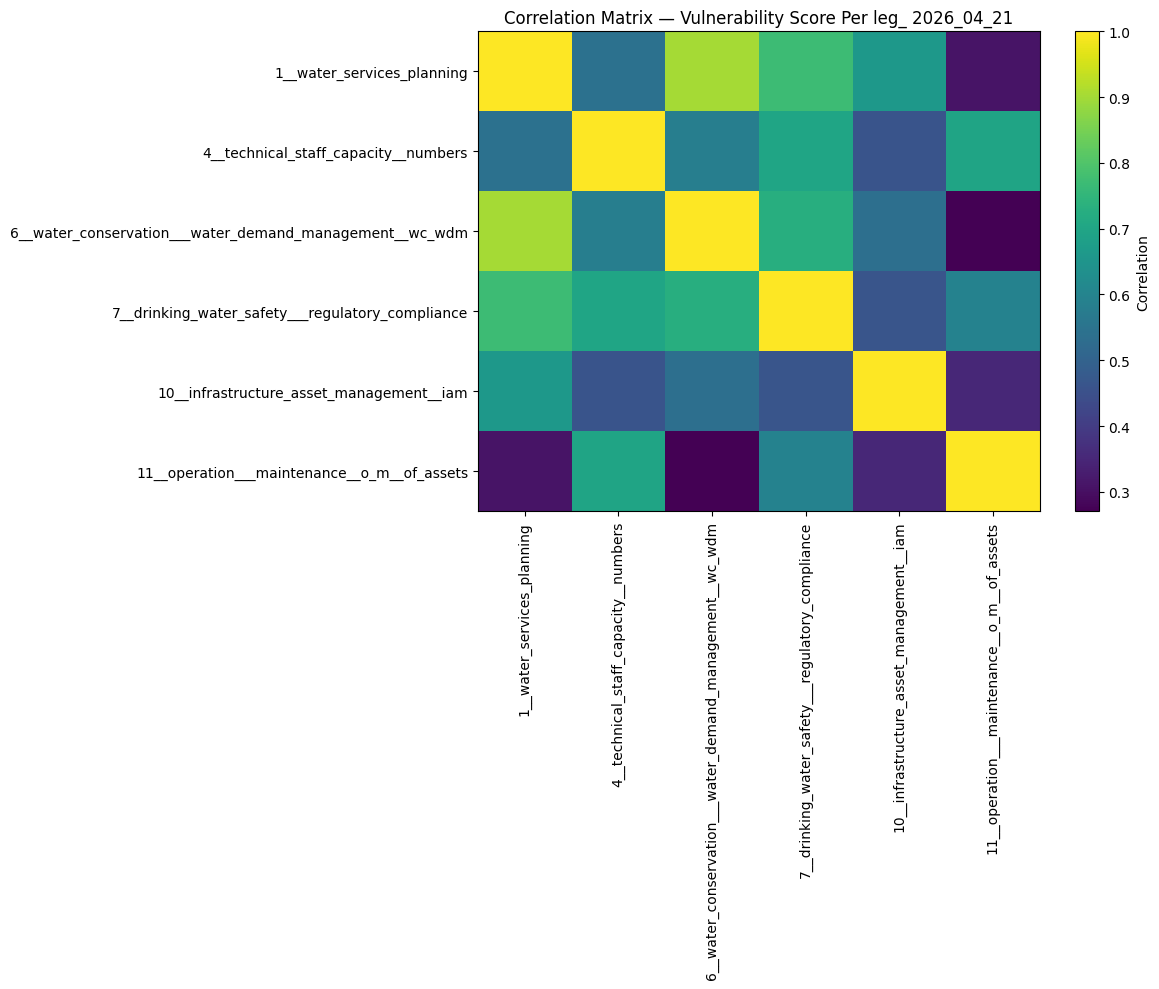

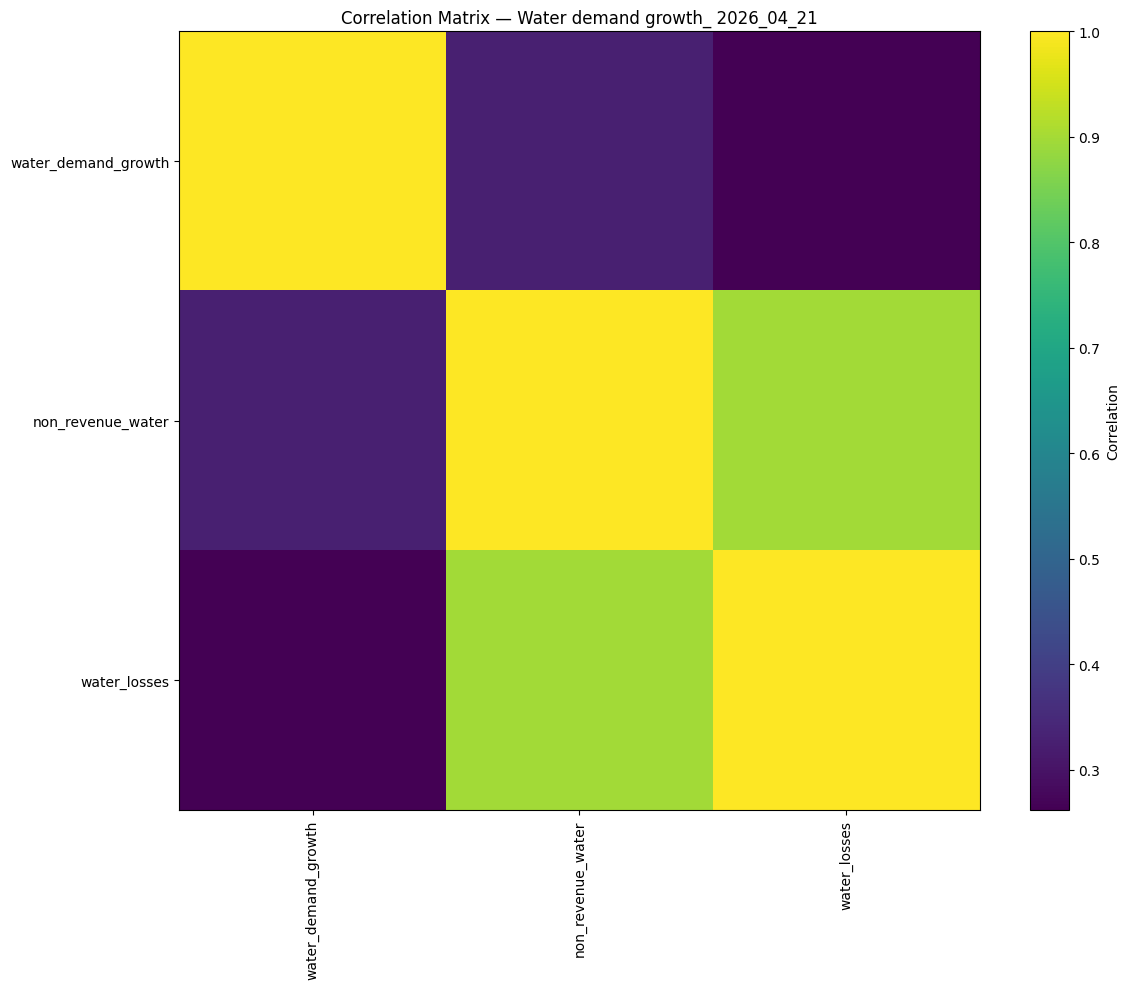

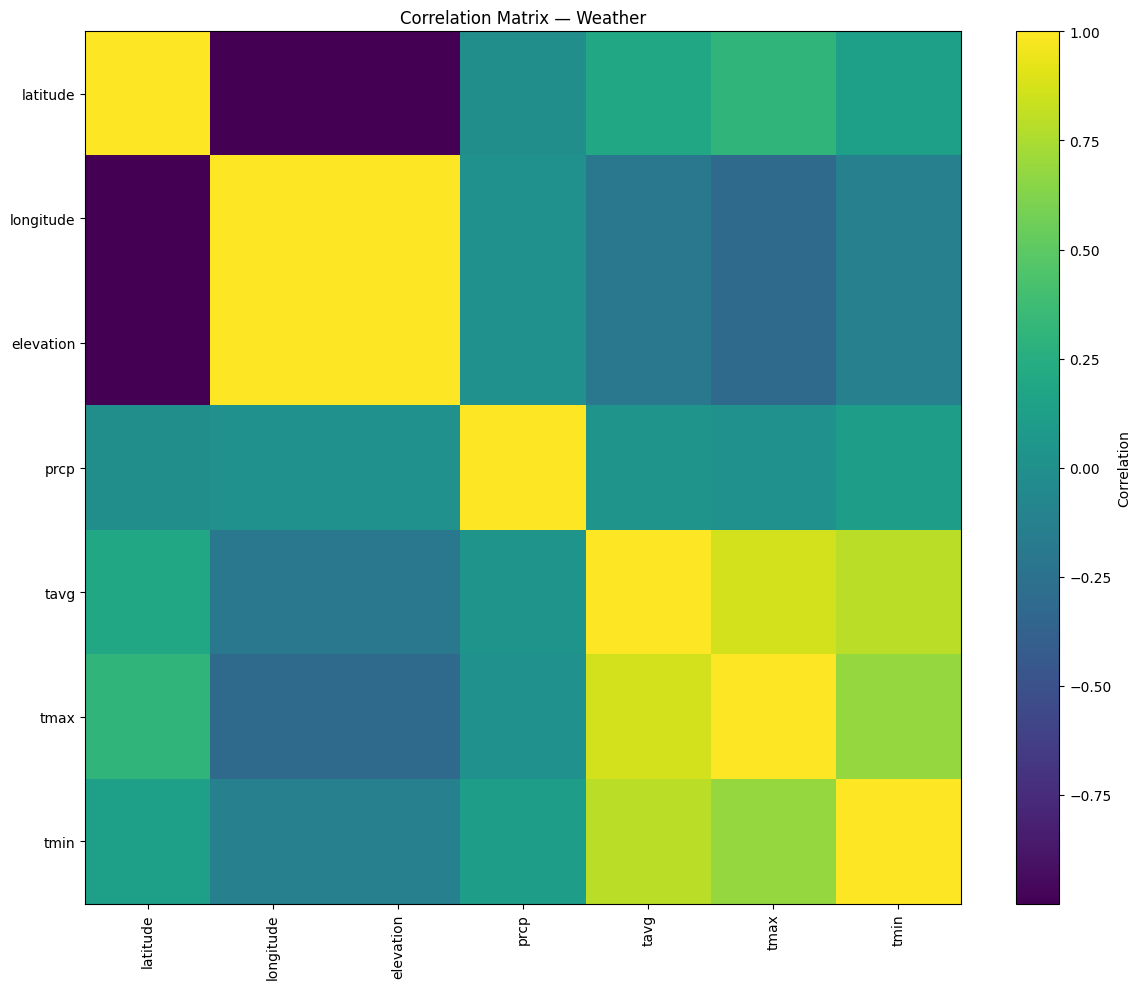

In [25]:
# ============================================================
# VISUALISATION — CORRELATION HEATMAP
# ============================================================

for name, df in cleaned.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    if numeric_df.shape[1] < 2:
        continue

    correlation = (
        numeric_df.corr()
    )

    plt.figure(
        figsize=(12, 10)
    )

    plt.imshow(
        correlation,
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=90
    )

    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    plt.title(
        f"Correlation Matrix — {name}"
    )

    plt.tight_layout()

    output_path = os.path.join(
        VISUALISATION_DIR,
        f"{name}_correlation_heatmap.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [26]:
# ============================================================
# BEFORE VS AFTER CLEANING
# ============================================================

comparison_records = []

for name in datasets.keys():

    original = datasets[name]

    final = cleaned[name]

    comparison_records.append({

        "Dataset": name,

        "Original Rows":
            original.shape[0],

        "Clean Rows":
            final.shape[0],

        "Rows Removed":
            original.shape[0]
            - final.shape[0],

        "Original Columns":
            original.shape[1],

        "Clean Columns":
            final.shape[1],

        "Original Missing":
            int(
                original.isna()
                .sum()
                .sum()
            ),

        "Remaining Missing":
            int(
                final.isna()
                .sum()
                .sum()
            ),

        "Original Duplicates":
            int(
                original.duplicated()
                .sum()
            ),

        "Remaining Duplicates":
            int(
                final.duplicated()
                .sum()
            )
    })

comparison_df = pd.DataFrame(
    comparison_records
)

display(
    comparison_df
)

,Dataset,Original Rows,Clean Rows,Rows Removed,Original Columns,Clean Columns,Original Missing,Remaining Missing,Original Duplicates,Remaining Duplicates
0,Areas of Highest Vulnerability_ 2026_04_21,11,11,0,21,21,29,0,0,0
1,Drinking Water Quality Compliance - SANS 241 _...,4,4,0,2,2,0,0,0,0
2,Households Served with Water_ 2026_04_21,11,11,0,17,17,25,0,0,0
3,Institutional Compliance_ 2026_04_21,11,11,0,5,5,13,0,0,0
4,Microbiological _ Acute Health_ 2026_04_21,11,11,0,8,8,16,0,0,0
5,NIWIS_Access to Water Infrastructure Delivered...,0,0,0,4,0,0,0,0,0
6,NIWIS_GroundwaterStatus_16-Jul-2026,1947,1946,1,8,8,2511,0,1,0
7,NIWIS_RWT_16-Jul-2026,9,9,0,5,5,0,0,0,0
8,NIWIS_WasteWaterQuality_16-Jul-2026,143,143,0,6,5,143,0,0,0
9,NIWIS_Water Supply Reliability - population_16...,144,144,0,14,13,189,0,0,0


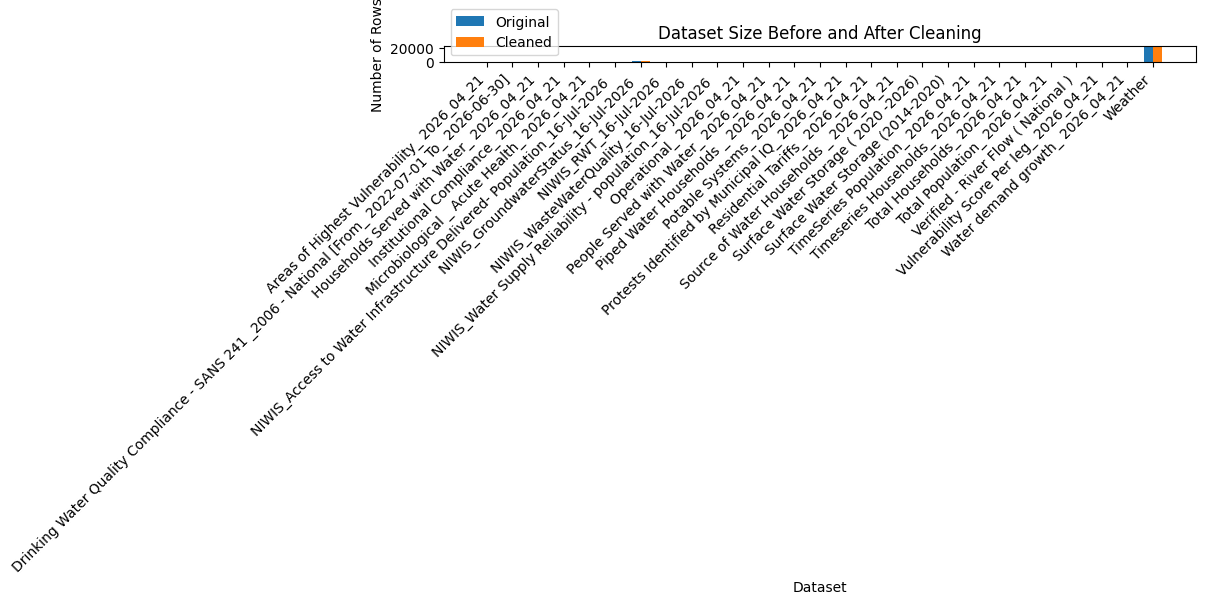

In [27]:
# ============================================================
# VISUALISATION — BEFORE VS AFTER ROW COUNTS
# ============================================================

x = np.arange(
    len(comparison_df)
)

width = 0.35

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    x - width / 2,
    comparison_df["Original Rows"],
    width,
    label="Original"
)

plt.bar(
    x + width / 2,
    comparison_df["Clean Rows"],
    width,
    label="Cleaned"
)

plt.xticks(
    x,
    comparison_df["Dataset"],
    rotation=45,
    ha="right"
)

plt.title(
    "Dataset Size Before and After Cleaning"
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "Number of Rows"
)

plt.legend()

plt.tight_layout()

output_path = os.path.join(
    VISUALISATION_DIR,
    "before_after_row_counts.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [28]:
# ============================================================
# SAVE CLEANED DATASETS
# ============================================================

print("=" * 80)
print("SAVING CLEANED DATASETS")
print("=" * 80)

for name, df in cleaned.items():

    output_path = os.path.join(
        CLEAN_DATA_DIR,
        f"{name}_clean.csv"
    )

    df.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {output_path}"
    )

print()
print(
    "All cleaned datasets saved successfully."
)

SAVING CLEANED DATASETS
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/Areas of Highest Vulnerability_ 2026_04_21_clean.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30]_clean.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/Households Served with Water_ 2026_04_21_clean.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/Institutional Compliance_ 2026_04_21_clean.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/Microbiological _ Acute Health_ 2026_04_21_clean.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/NIWIS_Access to Water Infrastructure Delivered- Population_16-Jul-2026 _clean.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/NIWIS_GroundwaterStatus_16-Jul-2026 _clean.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData/NIWIS_RWT

In [29]:
# ============================================================
# SAVE CLEANING REPORTS
# ============================================================

# Before/after report
comparison_df.to_csv(
    os.path.join(
        DATA_CLEANING_DIR,
        "before_after_cleaning.csv"
    ),
    index=False
)

# Outlier report
outlier_df.to_csv(
    os.path.join(
        DATA_CLEANING_DIR,
        "outlier_report.csv"
    ),
    index=False
)

# Missing value report
if not missing_df.empty:

    missing_df.to_csv(
        os.path.join(
            DATA_CLEANING_DIR,
            "missing_value_report.csv"
        ),
        index=False
    )

# Numeric conversions
if not numeric_conversion_df.empty:

    numeric_conversion_df.to_csv(
        os.path.join(
            DATA_CLEANING_DIR,
            "numeric_conversion_report.csv"
        ),
        index=False
    )

# Numeric imputation
if not numeric_imputation_df.empty:

    numeric_imputation_df.to_csv(
        os.path.join(
            DATA_CLEANING_DIR,
            "numeric_imputation_report.csv"
        ),
        index=False
    )

# Categorical imputation
if not categorical_imputation_df.empty:

    categorical_imputation_df.to_csv(
        os.path.join(
            DATA_CLEANING_DIR,
            "categorical_imputation_report.csv"
        ),
        index=False
    )

# Infinite values
infinite_df.to_csv(
    os.path.join(
        DATA_CLEANING_DIR,
        "infinite_value_report.csv"
    ),
    index=False
)

print(
    "Cleaning reports saved successfully."
)

Cleaning reports saved successfully.


In [30]:
# ============================================================
# FINAL DATA QUALITY VALIDATION
# ============================================================

print("=" * 80)
print("FINAL DATA QUALITY VALIDATION")
print("=" * 80)

validation_records = []

for name, df in cleaned.items():

    missing = int(
        df.isna().sum().sum()
    )

    duplicates = int(
        df.duplicated().sum()
    )

    numeric_df = df.select_dtypes(
        include=np.number
    )

    # Ensure numeric_df is cast to float to handle potential pd.NA values
    # before checking for infinite values.
    infinite = int(
        np.isinf(
            numeric_df.astype(float).to_numpy()
        ).sum()
    )

    validation_records.append({

        "Dataset": name,

        "Rows": len(df),

        "Columns": len(df.columns),

        "Missing Values":
            missing,

        "Duplicate Rows":
            duplicates,

        "Infinite Values":
            infinite,

        "Validation":
            (
                "PASS"
                if (
                    missing == 0
                    and duplicates == 0
                    and infinite == 0
                )
                else
                "REVIEW"
            )
    })

validation_df = pd.DataFrame(
    validation_records
)

display(
    validation_df
)

FINAL DATA QUALITY VALIDATION


,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Infinite Values,Validation
0,Areas of Highest Vulnerability_ 2026_04_21,11,21,0,0,0,PASS
1,Drinking Water Quality Compliance - SANS 241 _...,4,2,0,0,0,PASS
2,Households Served with Water_ 2026_04_21,11,17,0,0,0,PASS
3,Institutional Compliance_ 2026_04_21,11,5,0,0,0,PASS
4,Microbiological _ Acute Health_ 2026_04_21,11,8,0,0,0,PASS
5,NIWIS_Access to Water Infrastructure Delivered...,0,0,0,0,0,PASS
6,NIWIS_GroundwaterStatus_16-Jul-2026,1946,8,0,0,0,PASS
7,NIWIS_RWT_16-Jul-2026,9,5,0,0,0,PASS
8,NIWIS_WasteWaterQuality_16-Jul-2026,143,5,0,0,0,PASS
9,NIWIS_Water Supply Reliability - population_16...,144,13,0,0,0,PASS


In [31]:
# ============================================================
# SAVE FINAL VALIDATION REPORT
# ============================================================

validation_df.to_csv(
    os.path.join(
        DATA_CLEANING_DIR,
        "final_validation_report.csv"
    ),
    index=False
)

print(
    "Final validation report saved."
)

Final validation report saved.


In [32]:
# ============================================================
# FINAL CLEAN DATA PREVIEW
# ============================================================

for name, df in cleaned.items():

    print()
    print("=" * 80)
    print(f"FINAL CLEAN DATASET — {name}")
    print("=" * 80)

    print(
        f"Shape: {df.shape}"
    )

    display(
        df.head(10)
    )


FINAL CLEAN DATASET — Areas of Highest Vulnerability_ 2026_04_21
Shape: (11, 21)


,region,time_frame,unnamed__2,1__water_services_planning,2__management_skill_level__technical,3__staff_skill_level__technical,4__technical_staff_capacity__numbers,5__water_resource_management__wrm,6__water_conservation___water_demand_management__wc_wdm,7__drinking_water_safety___regulatory_compliance,...,9__wastewater_environmental_safety___regulatory_compliance,10__infrastructure_asset_management__iam,11__operation___maintenance__o_m__of_assets,12__financial_management,13__revenue_collection,14__financial_asset_management,15__information_management__it,16__organisational_performance_monitoring,17__water_and_sanitation_service_quality,18__customer_care__crm
0,City of Johannesburg Metropolitan Municipality,2 018,Unknown,Low,Low,Low,Low,Extreme,Low,Low,...,Low,Low,Moderate,Low,Low,Low,Low,Low,Low,Low
1,City of Tshwane Metropolitan Municipality,2 018,Unknown,Low,Low,Low,Extreme,Moderate,Low,Low,...,Extreme,Moderate,Extreme,Low,Low,Extreme,Low,Low,Low,Low
2,Ekurhuleni Metropolitan Municipality,2 018,Unknown,Low,Moderate,Low,Low,Low,Low,Low,...,Moderate,Low,Moderate,Low,Low,High,Low,Low,Low,Low
3,Emfuleni,2 018,Unknown,Extreme,Extreme,Extreme,Extreme,High,High,Moderate,...,Extreme,High,Extreme,Extreme,High,Extreme,Extreme,Low,Moderate,Extreme
4,Lesedi,2 018,Unknown,Moderate,Moderate,Moderate,Moderate,Extreme,Low,Moderate,...,High,High,Extreme,Extreme,Low,Extreme,Low,Low,Moderate,Low
5,Merafong City,2 018,Unknown,High,Extreme,High,Extreme,Low,High,High,...,Extreme,High,Extreme,Moderate,Extreme,Extreme,Low,Low,High,Extreme
6,Midvaal,2 018,Unknown,Low,Low,Low,Low,Low,Low,Low,...,Moderate,Moderate,Low,Low,Moderate,Extreme,Low,Low,Low,Low
7,Mogale City,2 018,Unknown,Extreme,Extreme,High,Extreme,Low,High,Moderate,...,High,Extreme,Moderate,Low,Moderate,Extreme,Low,Moderate,Low,Low
8,Rand West City,2 018,Unknown,Low,Moderate,High,Extreme,Low,Low,High,...,Extreme,Low,High,Extreme,Moderate,Moderate,Low,Low,Low,Extreme
9,Gauteng,2 018,Unknown,Moderate,Moderate,Moderate,High,Moderate,Moderate,Low,...,High,Moderate,High,Moderate,Moderate,Extreme,Low,Low,Low,Moderate



FINAL CLEAN DATASET — Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30]
Shape: (4, 2)


,category,sans_241__2006
0,'Chemical : Health,94.857059
1,'Microbiological : Health,96.086215
2,'Operational : Non-Health,91.560539
3,'Physical Orhanoleptic : Non-Health,98.819385



FINAL CLEAN DATASET — Households Served with Water_ 2026_04_21
Shape: (11, 17)


...

,region,time_frame,unnamed__2,1__water_services_planning,4__technical_staff_capacity__numbers,6__water_conservation___water_demand_management__wc_wdm,7__drinking_water_safety___regulatory_compliance,10__infrastructure_asset_management__iam,11__operation___maintenance__o_m__of_assets
0,City of Johannesburg Metropolitan Municipality,2 018,Unknown,93.00,79.00,80.00,98.00,99.00,65.00
1,City of Tshwane Metropolitan Municipality,2 018,Unknown,90.00,20.00,80.00,80.00,60.00,40.00
2,Ekurhuleni Metropolitan Municipality,2 018,Unknown,95.00,80.00,80.00,100.00,90.00,70.00
3,Emfuleni,2 018,Unknown,40.00,15.00,55.00,65.00,54.00,30.00
4,Lesedi,2 018,Unknown,65.00,69.00,80.00,74.00,55.00,35.00
5,Merafong City,2 018,Unknown,50.00,45.00,55.00,55.00,55.00,45.00
6,Midvaal,2 018,Unknown,100.00,87.00,84.00,99.00,65.00,75.00
7,Mogale City,2 018,Unknown,20.00,45.00,55.00,65.00,45.00,70.00
8,Rand West City,2 018,Unknown,75.00,45.00,75.00,59.00,95.00,50.00
9,Gauteng,2 018,Unknown,69.78,53.89,71.56,77.22,68.67,53.33



FINAL CLEAN DATASET — Water demand growth_ 2026_04_21
Shape: (11, 10)


,region,time_frame,unnamed__2,water_demand_growth,non_revenue_water,water_losses,system_input_volume__litres,revenue_water__litres,non_revenue_water__litres,water_losses__litres
0,City of Johannesburg Metropolitan Municipality,2 018,Unknown,2.24,35.74,34.34,536 312 001.00,344 641 579.00,191 670 422.00,184 160 156.00
1,City of Tshwane Metropolitan Municipality,2 018,Unknown,-0.40,25.48,24.42,318 733 465.00,237 530 661.00,81 202 804.00,77 831 360.00
2,Ekurhuleni Metropolitan Municipality,2 018,Unknown,3.35,39.34,31.30,338 742 752.00,205 497 030.00,133 245 722.00,106 026 481.00
3,Emfuleni,2 018,Unknown,-1.12,48.80,48.80,82 417 605.00,42 197 813.76,40 219 791.24,40 219 791.00
4,Lesedi,2 018,Unknown,-1.73,23.00,23.00,6 328 721.00,4 873 115.17,1 455 605.83,1 455 606.00
5,Merafong City,2 018,Unknown,8.90,37.60,37.60,12 192 465.00,7 608 098.16,4 584 366.84,4 584 367.00
6,Midvaal,2 018,Unknown,4.25,34.30,34.30,13 538 671.00,8 894 906.85,4 643 764.15,4 643 764.00
7,Mogale City,2 018,Unknown,-10.13,29.20,29.20,27 141 000.00,19 215 828.00,7 925 172.00,7 925 172.00
8,Rand West City,2 018,Unknown,0.50,28.52,27.06,17 054 900.00,12 190 600.00,4 864 300.00,4 615 050.00
9,Gauteng,2 018,Unknown,0.65,36.91,28.62,1 413 888 870.00,905 967 450.00,507 921 420.00,393 567 720.00



FINAL CLEAN DATASET — Weather
Shape: (21301, 14)


,station,name,latitude,longitude,elevation,date,prcp,prcp_attributes,tavg,tavg_attributes,tmax,tmax_attributes,tmin,tmin_attributes
0,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-01,15.5,",,S",17.2,"H,,S",26.8,",,S",13.7,",,S"
1,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-02,0.5,",,S",18.3,"H,,S",24.4,",,S",12.2,Unknown
2,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-03,5.6,",,S",16.0,"H,,S",24.4,",,S",13.4,",,S"
3,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-04,1.5,",,S",16.7,"H,,S",21.7,",,S",12.3,",,S"
4,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-05,7.4,",,S",17.2,"H,,S",21.7,",,S",14.3,",,S"
5,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-06,0.0,",,S",17.8,"H,,S",25.6,Unknown,12.2,Unknown
6,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-07,6.6,",,S",18.2,"H,,S",24.3,",,S",13.4,",,S"
7,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-08,6.1,",,S",18.6,"H,,S",24.7,",,S",14.0,",,S"
8,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-09,0.0,",,S",17.8,"H,,S",22.5,",,S",12.2,Unknown
9,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-10,0.0,"D,,S",19.9,"H,,S",25.7,",,S",14.9,",,S"


In [33]:
# ============================================================
# NOTEBOOK 2 COMPLETION SUMMARY
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 2 COMPLETE")
print("=" * 80)

print()
print("Clean datasets:")
print(
    CLEAN_DATA_DIR
)

print()
print("Cleaning reports:")
print(
    DATA_CLEANING_DIR
)

print()
print("Visualisations:")
print(
    VISUALISATION_DIR
)

print()
print(
    "The cleaned datasets are now ready "
    "for Notebook 3."
)

print()
print(
    "NEXT:"
)

print(
    "Notebook 3 — EDA + Feature Engineering"
)


NOTEBOOK 2 COMPLETE

Clean datasets:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData

Cleaning reports:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning

Visualisations:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/DataCleaning/Visualisations

The cleaned datasets are now ready for Notebook 3.

NEXT:
Notebook 3 — EDA + Feature Engineering


## PUSHING CHANGES TO GITHUB

This final cell will commit all local changes and push them to your GitHub repository. You may be prompted for your GitHub username and password/token.

**IMPORTANT: Do NOT put your GitHub password/token directly into this notebook.**

If you have 2FA enabled, you'll need to use a [GitHub Personal Access Token](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/creating-a-personal-access-token) instead of your password. If you've configured your `GITHUB_TOKEN` in Colab secrets or environment, it will be used automatically.

In [34]:
# ============================================================
# FINAL CELL — COMMIT AND PUSH NOTEBOOK 2 TO GITHUB
# ============================================================

import os
import subprocess
from getpass import getpass

print("=" * 80)
print("FINAL — COMMIT AND PUSH NOTEBOOK 2 TO GITHUB")
print("=" * 80)

# ============================================================
# 1. PROJECT CONFIGURATION
# ============================================================

REPO_DIR = "/content/ANLOK-WATER-PREDICTION-PROJECT-"
GITHUB_USERNAME = "LulutheBA"
GITHUB_REPO = "ANLOK-WATER-PREDICTION-PROJECT-"
GITHUB_REPO_URL = (
    f"https://github.com/{GITHUB_USERNAME}/{GITHUB_REPO}.git"
)

NOTEBOOK_PATH = os.path.join(
    REPO_DIR,
    "Notebooks",
    "02_Data_Cleaning_Preprocessing.ipynb"
)

print("\nProject directory:")
print(REPO_DIR)

print("\nGitHub repository:")
print(GITHUB_REPO_URL)

# ============================================================
# 2. CHECK PROJECT DIRECTORY
# ============================================================

if not os.path.exists(REPO_DIR):
    raise FileNotFoundError(
        f"Project directory does not exist: {REPO_DIR}"
    )

print("\nPASS: Project directory exists.")

# ============================================================
# 3. GIT HELPER FUNCTION
# ============================================================

def run_git(command, check=False): # Added 'check=False' parameter
    """
    Run a Git command inside the project repository.
    """
    result = subprocess.run(
        command,
        cwd=REPO_DIR,
        capture_output=True,
        text=True,
        check=check # Passed 'check' to subprocess.run
    )

    return result


# ============================================================
# 4. CHECK GIT REPOSITORY
# ============================================================

print("\n" + "-" * 80)
print("CHECKING GIT REPOSITORY")
print("-" * 80)

git_check = run_git(["git", "rev-parse", "--is-inside-work-tree"])

if git_check.returncode != 0:
    raise RuntimeError(
        "The project directory is not a Git repository."
    )

print("PASS: Git repository detected.")

# ============================================================
# 5. CHECK NOTEBOOK
# ============================================================

print("\n" + "-" * 80)
print("CHECKING NOTEBOOK 2")
print("-" * 80)

if os.path.exists(NOTEBOOK_PATH):
    print("PASS: Notebook 2 exists.")
    print(NOTEBOOK_PATH)
else:
    print("WARNING: Notebook 2 was not found at:")
    print(NOTEBOOK_PATH)
    print("\nGitHub push will continue for other project changes.")

# ============================================================
# 6. CHECK GIT STATUS
# ============================================================

print("\n" + "-" * 80)
print("CURRENT GIT STATUS")
print("-" * 80)

status_result = run_git(["git", "status", "--short"])

if status_result.returncode != 0:
    raise RuntimeError(
        f"Unable to read Git status:\n{status_result.stderr}"
    )

if status_result.stdout.strip():
    print(status_result.stdout)
else:
    print("Working directory is clean.")

# ============================================================
# 7. STAGE ALL NB2 CHANGES
# ============================================================

print("\n" + "-" * 80)
print("STAGING CHANGES")
print("-" * 80)

add_result = run_git(["git", "add", "."])

if add_result.returncode != 0:
    print("ERROR staging changes:")
    print(add_result.stderr)
    raise RuntimeError("Git staging failed.")

print("PASS: All project changes staged.")

# ============================================================
# 8. CONFIGURE GIT USER IDENTITY
# ============================================================

print("\n" + "-" * 80)
print("CONFIGURING GIT USER IDENTITY")
print("-" * 80)

# Check if user.email is configured
email_check = run_git(["git", "config", "user.email"])
if email_check.returncode != 0 or not email_check.stdout.strip():
    print("Git user.email not found. Please enter your email address.")
    user_email = input("Enter your Git email: ")
    if not user_email:
        raise ValueError("Git email cannot be empty.")
    run_git(["git", "config", "--global", "user.email", user_email], check=True)
    print(f"Git user.email set to: {user_email}")
else:
    print(f"Git user.email already set to: {email_check.stdout.strip()}")

# Check if user.name is configured
name_check = run_git(["git", "config", "user.name"])
if name_check.returncode != 0 or not name_check.stdout.strip():
    print("Git user.name not found. Please enter your name.")
    user_name = input("Enter your Git name: ")
    if not user_name:
        raise ValueError("Git name cannot be empty.")
    run_git(["git", "config", "--global", "user.name", user_name], check=True)
    print(f"Git user.name set to: {user_name}")
else:
    print(f"Git user.name already set to: {name_check.stdout.strip()}")

print("PASS: Git user identity configured.")

# ============================================================
# 9. CHECK WHETHER THERE IS ANYTHING TO COMMIT
# ============================================================

print("\n" + "-" * 80)
print("CHECKING FOR CHANGES TO COMMIT")
print("-" * 80)

cached_result = run_git(
    ["git", "diff", "--cached", "--quiet"]
)

if cached_result.returncode == 0:

    print("No new changes to commit.")

else:

    # ========================================================
    # 10. COMMIT NOTEBOOK 2
    # ========================================================

    commit_message = (
        "feat: complete Notebook 2 data cleaning preprocessing "
        "reports and visualisations"
    )

    print("\nCommit message:")
    print(commit_message)

    commit_result = run_git(
        ["git", "commit", "-m", commit_message]
    )

    if commit_result.returncode != 0:
        print("\nERROR creating commit:")
        print(commit_result.stderr)
        raise RuntimeError("Git commit failed.")

    print("\nPASS: Changes committed successfully.")
    print(commit_result.stdout)

# ============================================================
# 11. CHECK REMOTE
# ============================================================

print("\n" + "-" * 80)
print("CHECKING GITHUB REMOTE")
print("-" * 80)

remote_result = run_git(
    ["git", "remote", "-v"]
)

if remote_result.returncode != 0:
    raise RuntimeError(
        "Could not read GitHub remote."
    )

print(remote_result.stdout)

# ============================================================
# 12. PUSH TO GITHUB
# ============================================================

print("\n" + "-" * 80)
print("PUSHING NOTEBOOK 2 TO GITHUB")
print("-" * 80)

print("\nYour GitHub Personal Access Token is required.")
print("IMPORTANT: The token will NOT be saved in the notebook.")

token = getpass(
    "Enter your GitHub Personal Access Token: "
)

if not token:
    raise ValueError(
        "No GitHub Personal Access Token was entered."
    )

# Encode token safely for URL usage
from urllib.parse import quote

safe_token = quote(token, safe="")

authenticated_url = (
    f"https://{GITHUB_USERNAME}:{safe_token}"
    f"@github.com/{GITHUB_USERNAME}/{GITHUB_REPO}.git"
)

# Push current branch
push_result = run_git(
    ["git", "push", authenticated_url, "HEAD"]
)

# Remove token from memory
del token
del safe_token
del authenticated_url

if push_result.returncode != 0:

    print("\nERROR: Push failed.")
    print(push_result.stderr)

    raise RuntimeError(
        "GitHub push failed. Check your Personal Access Token "
        "and repository permissions."
    )

print("\nPASS: Notebook 2 changes pushed successfully!")

print("\n" + "=" * 80)
print("NOTEBOOK 2 GITHUB UPDATE COMPLETE")
print("=" * 80)

print("\nRepository:")
print(GITHUB_REPO_URL)

print("\nNotebook:")
print("Notebooks/02_Data_Cleaning_Preprocessing.ipynb")

print("\nOutputs:")
print("Outputs/CleanData/")
print("Outputs/DataCleaning/")
print("Outputs/DataCleaning/Visualisations/")

print("\nNotebook 2 is now linked to the GitHub project.")
print("=" * 80)

FINAL — COMMIT AND PUSH NOTEBOOK 2 TO GITHUB

Project directory:
/content/ANLOK-WATER-PREDICTION-PROJECT-

GitHub repository:
https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git

PASS: Project directory exists.

--------------------------------------------------------------------------------
CHECKING GIT REPOSITORY
--------------------------------------------------------------------------------
PASS: Git repository detected.

--------------------------------------------------------------------------------
CHECKING NOTEBOOK 2
--------------------------------------------------------------------------------
/content/ANLOK-WATER-PREDICTION-PROJECT-/Notebooks/02_Data_Cleaning_Preprocessing.ipynb

GitHub push will continue for other project changes.

--------------------------------------------------------------------------------
CURRENT GIT STATUS
--------------------------------------------------------------------------------
?? "Outputs/CleanData/Areas of Highest Vulnerabilit